### Routine to train and tabnet model

##### TODOs:
- Set MlFlow tracking URI
- Start mlflow server: mlflow server --host 127.0.0.1 --port 8080 (LOCAL)
- Change folders if needed

In [1]:
# https://github.com/dreamquark-ai/tabnet/blob/develop/pytorch_tabnet/tab_network.py

In [2]:
import os

from datetime import datetime
from pathlib import Path
from typing import Tuple, Optional, Union, List, Dict, Any
from dataclasses import dataclass, field
import multiprocessing
import numpy as np
import pandas as pd

import seaborn as sns
from scipy.stats import skew, kurtosis, entropy
from scipy.fft import fft
from sklearn.model_selection import train_test_split, StratifiedKFold


import joblib
from joblib import Parallel, delayed
from tqdm import tqdm
import mlflow
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc,
    precision_recall_curve, average_precision_score, confusion_matrix, classification_report
)
from sklearn.metrics import roc_auc_score
# Deep learning and specialized ML libraries
import torch
from pytorch_tabnet.tab_model import TabNetClassifier
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler


import warnings

warnings.filterwarnings('ignore')

c:\Users\atogni\anaconda3\envs\geok_5090\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#! mlflow server --host 127.0.0.1 --port 8080

In [4]:
import time
time.sleep(60*60*16)

In [5]:
time_stamp = datetime.now().strftime("%d%m%y_%H%M")

In [6]:
MODEL_KEYWORD ="tabnet_compressed_with_features"

In [7]:
TEST_PIPELINE = False  # Set to False to skip test pipeline and use full dataset for training

In [8]:
#ENVIRONMENT VARIABLES

os.environ["ML_FLOW_TRACKING_URI"] = "http://localhost:8080"
os.environ["ML_FLOW_EXPERIMENT_NAME"] = f"{MODEL_KEYWORD}_{time_stamp}_delivery" if not TEST_PIPELINE else f"{MODEL_KEYWORD}_{time_stamp}_test_pipeline"

# Folders
OUTPUT_DIR = Path(os.environ["ML_FLOW_EXPERIMENT_NAME"])
os.environ["OUTPUT_DIR"] = str(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_DATA_DIR = Path("E:/data")  
os.environ["RAW_DATA_DIR"] = str(RAW_DATA_DIR)

# Models directory
os.environ["MODELS_DIR"] = str(OUTPUT_DIR / "models")
MODELS_DIR = Path(os.environ["MODELS_DIR"])
MODELS_DIR.mkdir(parents=True, exist_ok=True)

os.environ["FEATURES_DIR"] = "C:/Users/atogni/Desktop/rongowai/deliver/processed_data" #str(OUTPUT_DIR / "features")
FEATURES_DIR = Path(os.environ["FEATURES_DIR"])
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

#Switches
EXTRACT_FEATURES = False  # Set to True to extract features, False to load existing features

In [9]:
# Set MlFlow tracking URI
mlflow.set_tracking_uri(os.environ["ML_FLOW_TRACKING_URI"])   #  Local: # mlflow server --host 127.0.0.1 --port 8080

In [10]:
class DDMFeatureExtractor:
    def __init__(self):
        pass
    @staticmethod
    def gini(array):
            """Gini coefficient calculation"""
            array = np.sort(array)
            index = np.arange(1, array.shape[0] + 1)
            return (np.sum((2 * index - array.shape[0] - 1) * array)) / (array.shape[0] * np.sum(array))  
      
    def extract_ddm_features(self, fit_data: np.ndarray) -> pd.DataFrame:
        """
        Extract features from DDM data.
        """
        features = []

        for row in tqdm(fit_data, desc="Extracting DDM features"):
            f = {}
            x = np.array(row, dtype=np.float64) + 1e-10  # evita log(0)

            # 1. General statistics
            f['mean'] = np.mean(x)
            f['std'] = np.std(x)
            f['min'] = np.min(x)
            f['max'] = np.max(x)
            f['median'] = np.median(x)
            f['range'] = np.max(x) - np.min(x)
            f['skew'] = skew(x)
            f['kurtosis'] = kurtosis(x)
            f['entropy'] = entropy(x)
            f['gini'] = self.gini(x)

            # 2. Positional 
            f['peak_index'] = np.argmax(x)
            f['peak_value'] = np.max(x)
            f['center_of_mass'] = np.sum(np.arange(len(x)) * x) / np.sum(x)
            f['inertia'] = np.sum(((np.arange(len(x)) - f['center_of_mass'])**2) * x)

            # 3. Segmentations in thirds
            thirds = np.array_split(x, 3)
            for i, part in enumerate(thirds):
                f[f'sum_third_{i+1}'] = np.sum(part)
                f[f'mean_third_{i+1}'] = np.mean(part)
                f[f'max_third_{i+1}'] = np.max(part)

            # 3.1 Segmentations in windows of 5
            windows = np.array_split(x, 5)
            for i, w in enumerate(windows):
                f[f'mean_w{i+1}'] = np.mean(w)
                f[f'std_w{i+1}'] = np.std(w)
                f[f'max_w{i+1}'] = np.max(w)

            # 4. Derivative statistics and differences
            dx = np.diff(x)
            f['mean_diff'] = np.mean(dx)
            f['std_diff'] = np.std(dx)
            f['max_diff'] = np.max(dx)
            f['min_diff'] = np.min(dx)
            f['n_positive_diff'] = np.sum(dx > 0)
            f['n_negative_diff'] = np.sum(dx < 0)
            f['n_zero_diff'] = np.sum(dx == 0)

            # 5. Autocorrelations (lag 1-3)
            for lag in range(1, 4):
                ac = np.corrcoef(x[:-lag], x[lag:])[0, 1] if len(x) > lag else np.nan
                f[f'autocorr_lag{lag}'] = ac

            # 6. FFT 
            spectrum = np.abs(fft(x)) # type: ignore
            half_spectrum = spectrum[:len(spectrum)//2]  
            f['fft_peak_freq'] = np.argmax(half_spectrum)
            f['fft_max'] = np.max(half_spectrum)
            f['fft_median'] = np.median(half_spectrum)
            f['fft_mean'] = np.mean(half_spectrum)


            features.append(f)
        return features # type: ignore

In [11]:
@dataclass
class SampleConfig:
    """Sample configuration."""
    name: str
    n_samples_per_class: int
    random_state: int = 42

@dataclass
class DatasetInfo:
    n_samples: int
    n_features: int
    class_distribution: Dict[int, int]
    features_columns: List[str]
    labels_columns: List[str]

@dataclass
class DataLoader:
    features_path: Union[str, Path]
    labels_path: Union[str, Path]
    _features_df_cache: Optional[pd.DataFrame] = field(default=None, init=False, repr=False)
    _labels_df_cache: Optional[pd.DataFrame] = field(default=None, init=False, repr=False)

    def __post_init__(self):
        self.features_path = Path(self.features_path)
        self.labels_path = Path(self.labels_path)

        if not self.features_path.exists():
            raise FileNotFoundError(f"Features file not found: {self.features_path}")
        if not self.labels_path.exists():
            raise FileNotFoundError(f"Labels file not found: {self.labels_path}")

    def load_full_data(self, use_cache: bool = False) -> Tuple[pd.DataFrame, pd.DataFrame]:
        
        if use_cache and self._features_df_cache is not None and self._labels_df_cache is not None:
            return self._features_df_cache, self._labels_df_cache

        features_df = pd.read_parquet(self.features_path)
        labels_df = pd.read_parquet(self.labels_path)

        # Dimensions check
        if len(features_df) != len(labels_df):
            raise ValueError(f"Features and labels have different lengths: "
                           f"{len(features_df)} vs {len(labels_df)}")

        if use_cache:
            self._features_df_cache = features_df
            self._labels_df_cache = labels_df

        return features_df, labels_df

    def clear_cache(self) -> None:
        self._features_df_cache = None
        self._labels_df_cache = None

    def load_balanced_sample(self, 
                            n_samples_per_class: int, 
                            random_state: int = 42,
                            use_cache: bool = False) -> Tuple[pd.DataFrame, pd.DataFrame]:
        
        # Load full data (with caching option)
        features_df_full, labels_df_full = self.load_full_data(use_cache=use_cache)

        # Get sampled indices balanced across classes
        sampled_indices = self._get_balanced_indices(
            labels_df_full = labels_df_full,
            n_samples_per_class = n_samples_per_class,
            random_state =random_state
        )
        features_df = features_df_full.loc[sampled_indices].reset_index(drop=True)
        labels_df = labels_df_full.loc[sampled_indices].reset_index(drop=True)

        return features_df, labels_df

    def load_balanced_sample_memory_efficient(self, n_samples_per_class: int, 
                                            random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
        
        features_df_full = pd.read_parquet(self.features_path)
        labels_df_full = pd.read_parquet(self.labels_path)

        # Get sampled indices balanced across classes
        sampled_indices = self._get_balanced_indices(
            labels_df = labels_df_full, 
            n_samples_per_class = n_samples_per_class, 
            random_state = random_state
        )

        features_df = features_df_full.loc[sampled_indices].reset_index(drop=True)
        labels_df = labels_df_full.loc[sampled_indices].reset_index(drop=True)

        # Clean up memory
        del features_df_full, labels_df_full, sampled_indices

        return features_df, labels_df

    def load_max_balanced_sample(self, 
                                random_state: int = 42,
                                use_cache: bool = False) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """
        Load the maximum number of samples with balanced labels.
        
        This method determines the size of the smallest class and samples 
        that many samples from each class, ensuring perfect balance.
        
        Args:
            random_state: Random seed for reproducible sampling
            use_cache: Whether to use cached data if available
            
        Returns:
            Tuple of (features_df, labels_df) with balanced sampling
            
        Raises:
            ValueError: If any class has 0 samples
        """
        # Load full data (with caching option)
        features_df_full, labels_df_full = self.load_full_data(use_cache=use_cache)
        
        # Get class distribution
        label_column = labels_df_full.iloc[:, 0]
        class_counts = label_column.value_counts()
        
        # Find the minimum class size
        min_class_size = class_counts.min()
        
        if min_class_size == 0:
            raise ValueError("One or more classes have 0 samples")
        
        # Get sampled indices using the minimum class size
        sampled_indices = self._get_balanced_indices(
            labels_df_full=labels_df_full,
            n_samples_per_class=min_class_size,
            random_state=random_state
        )
        
        features_df = features_df_full.loc[sampled_indices].reset_index(drop=True)
        labels_df = labels_df_full.loc[sampled_indices].reset_index(drop=True)
        
        return features_df, labels_df

    def load_max_balanced_sample_memory_efficient(self, 
                                                 random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """
        Memory-efficient version of load_max_balanced_sample.
        
        This method loads data, determines the maximum balanced sample size,
        and immediately cleans up intermediate data structures to minimize memory usage.
        
        Args:
            random_state: Random seed for reproducible sampling
            
        Returns:
            Tuple of (features_df, labels_df) with balanced sampling
            
        Raises:
            ValueError: If any class has 0 samples
        """
        # Load data
        features_df_full = pd.read_parquet(self.features_path)
        labels_df_full = pd.read_parquet(self.labels_path)
        
        # Get class distribution
        label_column = labels_df_full.iloc[:, 0]
        class_counts = label_column.value_counts()
        
        # Find the minimum class size
        min_class_size = class_counts.min()
        
        if min_class_size == 0:
            raise ValueError("One or more classes have 0 samples")
        
        # Get sampled indices using the minimum class size
        sampled_indices = self._get_balanced_indices(
            labels_df=labels_df_full,
            n_samples_per_class=min_class_size,
            random_state=random_state
        )
        
        features_df = features_df_full.loc[sampled_indices].reset_index(drop=True)
        labels_df = labels_df_full.loc[sampled_indices].reset_index(drop=True)
        
        # Clean up memory
        del features_df_full, labels_df_full, sampled_indices, class_counts, label_column
        
        return features_df, labels_df

    def get_max_balanced_sample_info(self, use_cache: bool = False) -> Dict[str, Any]:
        """
        Get information about the maximum balanced sample without loading the actual data.
        
        Args:
            use_cache: Whether to use cached data if available
            
        Returns:
            Dictionary containing:
            - max_samples_per_class: Maximum samples that can be taken per class
            - total_balanced_samples: Total samples in the balanced dataset
            - class_distribution: Original class distribution
            - balanced_distribution: What the balanced distribution would be
        """
        # Load full data (with caching option)
        _, labels_df_full = self.load_full_data(use_cache=use_cache)
        
        # Get class distribution
        label_column = labels_df_full.iloc[:, 0]
        class_counts = label_column.value_counts().sort_index()
        
        # Find the minimum class size
        min_class_size = class_counts.min()
        
        # Create balanced distribution
        balanced_distribution = {class_label: min_class_size for class_label in class_counts.index}
        
        return {
            'max_samples_per_class': min_class_size,
            'total_balanced_samples': min_class_size * len(class_counts),
            'class_distribution': class_counts.to_dict(),
            'balanced_distribution': balanced_distribution,
            'n_classes': len(class_counts)
        }
    
    def _get_balanced_indices(self, labels_df: pd.DataFrame, 
                            n_samples_per_class: int, 
                            random_state: int = 42) -> pd.Index:
        """
        Get indices of a balanced sample from the labels DataFrame.
        """
        label_column = labels_df.iloc[:, 0]

        # Check if all classes have enough samples
        class_counts = label_column.value_counts()
        for class_label, count in class_counts.items():
            if count < n_samples_per_class:
                raise ValueError(f"Class {class_label} has only {count} samples, "
                               f"but {n_samples_per_class} requested")

        sampled_indices = (
            labels_df.groupby(label_column)
            .apply(lambda x: x.sample(n=n_samples_per_class, random_state=random_state))
            .index.get_level_values(1)
        )
        return sampled_indices

In [12]:
def combined_features_to_dataframe(combined_features, full_data = pd.DataFrame(), full_labels = pd.DataFrame()) -> Tuple[pd.DataFrame, pd.DataFrame, List[str]]:
    flat_features = [row[0] if isinstance(row, list) and len(row) > 0 else row for row in combined_features]
    FEATURES=list(combined_features[0][0].keys())
    combined_features = np.array([[row[key] for key in FEATURES] for row in flat_features])
    del flat_features
    combined_features.shape

    # Check for NaN and infinite values
    mask_finite = np.isfinite(combined_features).all(axis=1) & (np.abs(combined_features) < np.finfo(np.float64).max).all(axis=1)

    fit_data_with_features_clean = combined_features[mask_finite]
    labels_clean = full_labels[mask_finite]
    del combined_features
    return pd.DataFrame(fit_data_with_features_clean, columns=FEATURES),  pd.DataFrame(labels_clean, columns=['0']), FEATURES

In [13]:
cpu_cores = multiprocessing.cpu_count()
print(f"Available {cpu_cores} CPU cores for parallel processing.")

Available 16 CPU cores for parallel processing.


In [14]:
if EXTRACT_FEATURES:
    # Feature extraction train set
    # Load raw encoded data from Parquet
    fit_data_path = f"{RAW_DATA_DIR}/balanced_df_enh_encoder_10M.parquet"
    df_parquet = pd.read_parquet(fit_data_path)
    fit_data_full = df_parquet.drop(columns=['label']).values
    fit_labels_full = df_parquet['label'].values

    #Load test data from Parquet
    test_data_path = f"{RAW_DATA_DIR}/test_df_enh_encoder_2M.parquet"
    df_parquet_test = pd.read_parquet(test_data_path)
    test_data = df_parquet_test.drop(columns=['label']).values
    test_labels = df_parquet_test['label'].values

    # Feature extraction train set
    features_extractor = DDMFeatureExtractor()

    def extract_ddm_features_row(row):
        return features_extractor.extract_ddm_features(np.array([row]))

    combined_features_train = Parallel(n_jobs=cpu_cores-2, backend="loky")(delayed(extract_ddm_features_row)(row) for row in tqdm(fit_data_full, desc="Estrazione features train"))


    fit_data_with_features_df, labels_clean_df, FEATURES = combined_features_to_dataframe(combined_features_train, 
                                                                                            full_data=fit_data_full, 
                                                                                            full_labels=fit_labels_full)

    
    fit_data_with_features_df.to_parquet(f"{FEATURES_DIR}/compressed_fit_features.parquet", index=False)
    labels_clean_df.rename(columns={'0': 'label'}, inplace=True)
    labels_clean_df.to_parquet(f"{FEATURES_DIR}/compressed_fit_labels.parquet", index=False)
    FEATURES = fit_data_with_features_df.columns.tolist()

    # Feature extraction test set
    combined_features_test = Parallel(n_jobs=cpu_cores-2, backend="loky")(delayed(extract_ddm_features_row)(row) for row in tqdm(test_data, desc="Estrazione features test"))

    test_data_with_features_df, test_labels_clean_df, FEATURES = combined_features_to_dataframe(combined_features_test, 
                                                                                                full_data=test_data, 
                                                                                                full_labels=test_labels)

    test_data_with_features_df.to_parquet(f"{FEATURES_DIR}/compressed_test_features.parquet", index=False)
    test_labels_clean_df.rename(columns={'0': 'label'}, inplace=True)
    test_labels_clean_df.to_parquet(f"{FEATURES_DIR}/compressed_test_labels.parquet", index=False)

else:
    # Load extracted features from Parquet
    fit_data_with_features_df = pd.read_parquet(f"{FEATURES_DIR}/compressed_fit_features.parquet")
    fit_labels_clean_df = pd.read_parquet(f"{FEATURES_DIR}/compressed_fit_labels.parquet")
    fit_labels_clean = fit_labels_clean_df['label'].values
    if TEST_PIPELINE:
        print("Running test pipeline...")
        fit_data_with_features_df, _, fit_labels_clean, _ = train_test_split(
            fit_data_with_features_df, fit_labels_clean, 
            train_size=10000, 
            stratify=fit_labels_clean, 
            random_state=42
        )

    test_data_with_features_df = pd.read_parquet(f"{FEATURES_DIR}/compressed_test_features.parquet")
    test_labels_clean_df = pd.read_parquet(f"{FEATURES_DIR}/compressed_test_labels.parquet")
    test_labels_clean = test_labels_clean_df['label'].values

    FEATURES = fit_data_with_features_df.columns.tolist()

In [15]:
loader = DataLoader(
    features_path=f"{FEATURES_DIR}/compressed_fit_features.parquet",
    labels_path=f"{FEATURES_DIR}/compressed_fit_labels.parquet",
)

# Small balanced sample for hyperparameter tuning
features_df_hyperparameters, labels_df_hyperparameters = loader.load_balanced_sample_memory_efficient(n_samples_per_class=500000 if not TEST_PIPELINE else 1000, random_state=42)
print(f"Training set shape: features={features_df_hyperparameters.shape}, labels={labels_df_hyperparameters.shape}")

# Large balanced sample for final retraining
features_df_to_finalize, labels_df_to_finalize = loader.load_max_balanced_sample_memory_efficient(
    random_state=42
)

if TEST_PIPELINE:
    print("=== TEST MODE: Using reduced dataset sizes ===")
    features_df_to_finalize = features_df_to_finalize.sample(n=10000, random_state=42)
    labels_df_to_finalize = labels_df_to_finalize.loc[features_df_to_finalize.index]
else:
    # Large balanced sample for final retraining
    features_df_to_finalize, labels_df_to_finalize = loader.load_max_balanced_sample_memory_efficient(
    random_state=42)
    print(f"Final set shape: features={features_df_to_finalize.shape}, labels={labels_df_to_finalize.shape}")
    print(f"Class distribution in dev set set: {labels_df_hyperparameters.iloc[:, 0].value_counts()}")
    print(f"Class distribution in final set: {labels_df_to_finalize.iloc[:, 0].value_counts()}")

Training set shape: features=(1000000, 52), labels=(1000000, 1)
Final set shape: features=(10000000, 52), labels=(10000000, 1)
Class distribution in dev set set: label
0    500000
1    500000
Name: count, dtype: int64
Class distribution in final set: label
0    5000000
1    5000000
Name: count, dtype: int64


### Model training
#### train a simple tabnet model having done hyperparameter optimization

In [16]:
class TabNetBinaryClassifier:
    """
    Class for training a TabNet binary classifier with GPU support and threshold optimization
    """
    
    def __init__(self, 
                 X_original,
                 y_original,
                 scaler_path,
                 n_d, 
                 n_a, 
                 n_steps, 
                 gamma,
                 n_independent=2,
                 n_shared=2,
                 lambda_sparse=1e-3,
                 optimizer_fn=torch.optim.AdamW,
                 optimizer_params=dict(lr=1e-2),
                 mask_type='entmax',
                 momentum=0.02,
                 clip_value=1,
                 scheduler_params=dict(step_size=50, gamma=0.9),
                 scheduler_fn=torch.optim.lr_scheduler.StepLR,
                 epsilon=1e-15,
                 device_name='auto', 
                 track_experiment=True if not TEST_PIPELINE else True,
                 experiment_name=os.environ["ML_FLOW_EXPERIMENT_NAME"]):
        """
        Initialize the TabNet classifier
        """
        
        # Device configuration
        self.device = self._setup_device(device_name)
        print(f"Device used: {self.device}")
        
        self.tabnet_params = {
            'n_d': n_d,
            'n_a': n_a, 
            'n_steps': n_steps,
            'gamma': gamma,
            'n_independent': n_independent,
            'n_shared': n_shared,
            'lambda_sparse': lambda_sparse,
            'optimizer_fn': optimizer_fn,
            'optimizer_params': optimizer_params,
            'mask_type': mask_type,
            'scheduler_params': scheduler_params,
            'scheduler_fn': scheduler_fn,
            'epsilon': epsilon,
            'device_name': self.device
        }
        self.X_original = X_original
        self.y_original = y_original
        self.model = None
        self.scaler = StandardScaler()
        self.feature_names = None
        self.is_fitted = False
        self.scaler_path = scaler_path
        self.track_experiment = track_experiment
        self.experiment_name = experiment_name
        
        # Threshold optimization attributes
        self.optimal_threshold = 0.5
        self.threshold_metrics = {}

        if self.track_experiment:
            self._setup_mlflow_experiment()

    # MLflow configuration
    def _setup_mlflow_experiment(self):
        try:
            experiment = mlflow.get_experiment_by_name(self.experiment_name)
            if experiment is None:
                mlflow.create_experiment(self.experiment_name)

            mlflow.set_experiment(self.experiment_name)
            print(f"MLflow experiment '{self.experiment_name}' correctly set up.")

        except Exception as e:
            print(f"Error in mlflow configuration: {e}")

    def _log_to_mlflow(self, key, value):
        try:
            if isinstance(value, (int, float)):
                mlflow.log_metric(key, value)
            else:
                mlflow.log_param(key, value)
        except Exception as e:
            print(f"Error logging MLflow {key}: {e}")


        
    def _setup_device(self, device_name):
        """Configure the computing device (CPU/GPU)"""
        if device_name == 'auto':
            if torch.cuda.is_available():
                device = 'cuda'
                print(f"GPU available: {torch.cuda.get_device_name()}")
                print(f"GPU memory available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
            else:
                device = 'cpu'
                print("GPU not available, using CPU")
        else:
            device = device_name
            if device.startswith('cuda') and not torch.cuda.is_available():
                print("WARNING: GPU requested but not available, using CPU")
                device = 'cpu'
        
        return device
    
    def get_gpu_memory_info(self):
        """Returns GPU memory information"""
        if torch.cuda.is_available() and self.device.startswith('cuda'):
            device_idx = 0 if self.device == 'cuda' else int(self.device.split(':')[1])
            allocated = torch.cuda.memory_allocated(device_idx) / 1e9
            reserved = torch.cuda.memory_reserved(device_idx) / 1e9
            total = torch.cuda.get_device_properties(device_idx).total_memory / 1e9
            
            print("GPU Memory:")
            print(f"  - Allocated: {allocated:.2f} GB")
            print(f"  - Reserved: {reserved:.2f} GB") 
            print(f"  - Total: {total:.2f} GB")
            print(f"  - Free: {total - reserved:.2f} GB")
            
            return {
                'allocated': allocated,
                'reserved': reserved,
                'total': total,
                'free': total - reserved
            }
        else:
            print("GPU memory not available")
            return None
    
    def clear_gpu_memory(self):
        """Clear GPU memory"""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            print("GPU cache cleared")
    
    def prepare_data(self, X, y, test_size=0.2, random_state=42):
        """Prepare data for training"""
        
        # Separate features and target
        X = self.X_original
        y = self.y_original

        # Save feature names
        self.feature_names = X.columns.tolist()
        
        # Convert to float32 to optimize GPU memory
        X = X.astype(np.float32)
        
        # Split X and y into train (64%), validation (16%), and test (20%) sets
        X_temp, X_test, y_temp, y_test = train_test_split(
            X,
            y,
            test_size=test_size,
            stratify=y,
            random_state=42
        )

        X_train, X_val, y_train, y_val = train_test_split(
            X_temp,
            y_temp,
            test_size=test_size,  # 0.2 * 0.8 = 0.16 of the original data
            stratify=y_temp,
            random_state=42
        )

        # Reset indices for convenience
        X_train = X_train.reset_index(drop=True)
        X_val = X_val.reset_index(drop=True)
        X_test = X_test.reset_index(drop=True)
        y_train = y_train.reset_index(drop=True)
        y_val = y_val.reset_index(drop=True)
        y_test = y_test.reset_index(drop=True)

        # Numeric columns will be scaled by StandardScaler
        # Load scaler from path if provided
        if self.scaler_path is not None:
            scaler = joblib.load(self.scaler_path)
            print(f"Scaler loaded from: {self.scaler_path}")
        else:
            scaler = StandardScaler()

        column_trans = ColumnTransformer(
            [ ('scaler',scaler, FEATURES),
            ], remainder='passthrough', n_jobs=-1)

        train_X_transformed = column_trans.fit_transform(X_train, y_train)
        val_X_transformed = column_trans.transform(X_val )
        test_X_transformed = column_trans.transform(X_test)

        self.X_train = train_X_transformed
        self.X_val = val_X_transformed
        self.X_test = test_X_transformed

        # Convert to float32 for GPU
        self.X_train = X_train.values.astype(np.float32)
        self.y_train = y_train.values.astype(np.int64)

        self.X_test = X_test.values.astype(np.float32)
        self.y_test = y_test.values.astype(np.int64)

        self.X_val = X_val.values.astype(np.float32)
        self.y_val = y_val.values.astype(np.int64)

        print("Data prepared:")
        print(f"  - Training set: {self.X_train.shape}")
        print(f"  - Test set: {self.X_test.shape}")
        print(f"  - Validation set: {self.X_val.shape}")

        if self.track_experiment:
            try:
                mlflow.log_param("train_samples", self.X_train.shape[0])
                mlflow.log_param("test_samples", self.X_test.shape[0])
                mlflow.log_param("n_features", self.X_train.shape[1])
                mlflow.log_param("scaler", "StandardScaler")
                mlflow.log_param("feature_names", self.feature_names)
                mlflow.log_param("val_samples", self.X_val.shape[0])

                class_distribution = pd.Series(self.y_train).value_counts(normalize=True)
                for class_label, proportion in class_distribution.items():
                    mlflow.log_metric(f"class_{class_label}_proportion", proportion)

            except Exception as e:
                print(f"Error mlflow: {e}")

        return self.X_train, self.X_test, self.y_train, self.y_test, self.X_val, self.y_val
    
    def train(self, 
              max_epochs=None, 
              patience=15, 
              batch_size=1024,
              virtual_batch_size=128,
              num_workers=0,
              drop_last=False):
        """Train the TabNet model"""
        
        self.X_train, self.X_test, self.y_train, self.y_test, self.X_val, self.y_val = self.prepare_data(self.X_original, self.y_original, test_size=0.2, random_state=42)
        
        # Adapt batch_size for GPU
        if self.device.startswith('cuda'):
            gpu_memory = self.get_gpu_memory_info()
            if gpu_memory and gpu_memory['free'] < 2.0:  # Less than 2GB free
                suggested_batch_size = min(batch_size, 512)
                print(f"Limited GPU memory, reducing batch_size to {suggested_batch_size}")
                batch_size = suggested_batch_size
            
            # Optimize num_workers for GPU
            if num_workers == 0:
                num_workers = min(4, torch.cuda.device_count() * 2)
                
        print("Training configuration:")
        print(f"  - Device: {self.device}")
        print(f"  - Batch size: {batch_size}")
        print(f"  - Virtual batch size: {virtual_batch_size}")
        print(f"  - Num workers: {num_workers}")
        
        # Initialize model
        self.model = TabNetClassifier(**self.tabnet_params)
        
        # Check memory before training
        if self.device.startswith('cuda'):
            self.clear_gpu_memory()
            print("GPU memory before training:")
            self.get_gpu_memory_info()
        
        # Training
        print("\nStarting TabNet training...") 
        
        try:
            self.model.fit(
                X_train=self.X_train,
                y_train=self.y_train.reshape(-1),
                eval_set=[(self.X_val, self.y_val.reshape(-1))],
                eval_name=['val'],
                eval_metric=['accuracy', 'auc'],
                max_epochs=max_epochs if max_epochs is not None else 100,
                patience=patience,
                batch_size=512,
                virtual_batch_size=256,
                num_workers=num_workers,
                drop_last=drop_last,
            )
            if self.track_experiment:
                mlflow.log_param("training_max_epochs", max_epochs)
                mlflow.log_param("training_patience", patience)
                mlflow.log_param("training_batch_size", batch_size)
                mlflow.log_param("training_virtual_batch_size", virtual_batch_size)

            self.is_fitted = True
            print("Training completed!")
            
            # Check memory after training
            if self.device.startswith('cuda'):
                print("\nGPU memory after training:")
                self.get_gpu_memory_info()
                
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print("\nERROR: Insufficient GPU memory!")
                self.clear_gpu_memory()
            raise e
        
        return self.model
    
    def optimize_threshold(self, X=None, y=None, metric='f1', plot=True):
        """
        Optimize classification threshold based on validation set
        
        Parameters:
        -----------
        X : array-like, optional
            Features for threshold optimization. If None, uses validation set
        y : array-like, optional
            True labels. If None, uses validation set labels
        metric : str
            Metric to optimize ('f1', 'precision', 'recall', 'accuracy', 'youden')
        plot : bool
            Whether to plot threshold optimization curve
            
        Returns:
        --------
        dict : Dictionary with optimal threshold and metrics
        """
        
        if not self.is_fitted:
            raise ValueError("Model has not been trained yet!")
        
        # Use validation set if no data provided
        if X is None:
            X = self.X_val
            y = self.y_val.ravel()
        
        # Get prediction probabilities
        y_pred_proba = self.predict_proba(X)[:, 1]
        
        # Define threshold range
        thresholds = np.arange(0.1, 0.95, 0.01)
        
        # Calculate metrics for each threshold
        metrics_data = {
            'threshold': [],
            'precision': [],
            'recall': [],
            'f1': [],
            'accuracy': [],
            'youden': []  # Youden's J statistic (Sensitivity + Specificity - 1)
        }
        
        for threshold in thresholds:
            y_pred = (y_pred_proba >= threshold).astype(int)
            
            precision = precision_score(y, y_pred, zero_division=0)
            recall = recall_score(y, y_pred, zero_division=0)
            f1 = f1_score(y, y_pred, zero_division=0)
            accuracy = accuracy_score(y, y_pred)
            
            # Calculate Youden's J statistic
            tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            youden = sensitivity + specificity - 1
            
            metrics_data['threshold'].append(threshold)
            metrics_data['precision'].append(precision)
            metrics_data['recall'].append(recall)
            metrics_data['f1'].append(f1)
            metrics_data['accuracy'].append(accuracy)
            metrics_data['youden'].append(youden)
        
        # Convert to DataFrame for easier manipulation
        metrics_df = pd.DataFrame(metrics_data)
        
        # Find optimal threshold based on selected metric
        if metric == 'youden':
            optimal_idx = metrics_df['youden'].idxmax()
        else:
            optimal_idx = metrics_df[metric].idxmax()
        
        self.optimal_threshold = metrics_df.loc[optimal_idx, 'threshold']
        self.threshold_metrics = metrics_df.loc[optimal_idx].to_dict()
        
        print("\n=== THRESHOLD OPTIMIZATION RESULTS ===")
        print(f"Optimization metric: {metric}")
        print(f"Optimal threshold: {self.optimal_threshold:.3f}")
        print("Metrics at optimal threshold:")
        print(f"  - Precision: {self.threshold_metrics['precision']:.4f}")
        print(f"  - Recall: {self.threshold_metrics['recall']:.4f}")
        print(f"  - F1-Score: {self.threshold_metrics['f1']:.4f}")
        print(f"  - Accuracy: {self.threshold_metrics['accuracy']:.4f}")
        print(f"  - Youden's J: {self.threshold_metrics['youden']:.4f}")
        
        if plot:
            self.plot_threshold_optimization(metrics_df, metric)

        if self.track_experiment:
            mlflow.log_param("optimal_threshold", self.optimal_threshold)
            mlflow.log_param("threshold_optimization_metric", metric)
            for key, value in self.threshold_metrics.items():
                mlflow.log_metric(f"threshold_{key}", value)
        
        return {
            'optimal_threshold': self.optimal_threshold,
            'metrics': self.threshold_metrics,
            'all_metrics': metrics_df
        }
    
    def plot_threshold_optimization(self, metrics_df, optimization_metric):
        """
        Plot threshold optimization curves
        
        Parameters:
        -----------
        metrics_df : pandas.DataFrame
            DataFrame with metrics for different thresholds
        optimization_metric : str
            The metric used for optimization
        """
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Plot 1: All metrics vs threshold
        axes[0, 0].plot(metrics_df['threshold'], metrics_df['precision'], 
                       label='Precision', linewidth=2)
        axes[0, 0].plot(metrics_df['threshold'], metrics_df['recall'], 
                       label='Recall', linewidth=2)
        axes[0, 0].plot(metrics_df['threshold'], metrics_df['f1'], 
                       label='F1-Score', linewidth=2)
        axes[0, 0].plot(metrics_df['threshold'], metrics_df['accuracy'], 
                       label='Accuracy', linewidth=2)
        
        # Highlight optimal threshold
        axes[0, 0].axvline(x=self.optimal_threshold, color='red', 
                          linestyle='--', alpha=0.7, 
                          label=f'Optimal ({optimization_metric})')
        
        axes[0, 0].set_xlabel('Threshold')
        axes[0, 0].set_ylabel('Metric Value')
        axes[0, 0].set_title('All Metrics vs Threshold')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # Plot 2: Precision-Recall trade-off
        axes[0, 1].plot(metrics_df['threshold'], metrics_df['precision'], 
                       label='Precision', linewidth=2, color='blue')
        axes[0, 1].plot(metrics_df['threshold'], metrics_df['recall'], 
                       label='Recall', linewidth=2, color='orange')
        axes[0, 1].axvline(x=self.optimal_threshold, color='red', 
                          linestyle='--', alpha=0.7)
        axes[0, 1].set_xlabel('Threshold')
        axes[0, 1].set_ylabel('Score')
        axes[0, 1].set_title('Precision-Recall Trade-off')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # Plot 3: F1-Score and Youden's J
        axes[1, 0].plot(metrics_df['threshold'], metrics_df['f1'], 
                       label='F1-Score', linewidth=2, color='green')
        axes[1, 0].plot(metrics_df['threshold'], metrics_df['youden'], 
                       label="Youden's J", linewidth=2, color='purple')
        axes[1, 0].axvline(x=self.optimal_threshold, color='red', 
                          linestyle='--', alpha=0.7)
        axes[1, 0].set_xlabel('Threshold')
        axes[1, 0].set_ylabel('Score')
        axes[1, 0].set_title('F1-Score and Youden\'s J vs Threshold')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        # Plot 4: Metric distribution at optimal threshold
        optimal_metrics = [
            self.threshold_metrics['precision'],
            self.threshold_metrics['recall'],
            self.threshold_metrics['f1'],
            self.threshold_metrics['accuracy']
        ]
        metric_names = ['Precision', 'Recall', 'F1-Score', 'Accuracy']
        
        bars = axes[1, 1].bar(metric_names, optimal_metrics, 
                             color=['blue', 'orange', 'green', 'red'], alpha=0.7)
        axes[1, 1].set_ylabel('Score')
        axes[1, 1].set_title(f'Metrics at Optimal Threshold ({self.optimal_threshold:.3f})')
        axes[1, 1].set_ylim(0, 1)
        
        # Add value labels on bars
        for bar, value in zip(bars, optimal_metrics):
            axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                           f'{value:.3f}', ha='center', va='bottom')
        
        axes[1, 1].grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
    
    def predict(self, X=None, use_optimal_threshold=True):
        """
        Make predictions
        
        Parameters:
        -----------
        X : array-like, optional
            Features to predict. If None, uses test set
        use_optimal_threshold : bool
            Whether to use optimal threshold or default 0.5
        """
        if not self.is_fitted:
            raise ValueError("Model has not been trained yet!")
        
        if X is None:
            X = self.X_test
            
        # Convert to float32 for consistency
        if isinstance(X, pd.DataFrame):
            X = X.values.astype(np.float32)
        elif not isinstance(X, np.ndarray):
            X = np.array(X, dtype=np.float32)
        else:
            X = X.astype(np.float32)
        
        # Get probabilities
        probabilities = self.model.predict_proba(X)
        
        # Apply threshold
        threshold = self.optimal_threshold if use_optimal_threshold else 0.5
        predictions = (probabilities[:, 1] >= threshold).astype(int)
        
        return predictions
    
    def predict_proba(self, X=None):
        """Return prediction probabilities"""
        if not self.is_fitted:
            raise ValueError("Model has not been trained yet!")
        
        if X is None:
            X = self.X_test
            
        # Convert to float32 for consistency
        if isinstance(X, pd.DataFrame):
            X = X.values.astype(np.float32)
        elif not isinstance(X, np.ndarray):
            X = np.array(X, dtype=np.float32)
        else:
            X = X.astype(np.float32)
            
        probabilities = self.model.predict_proba(X)
        return probabilities
    
    def evaluate(self, X=None, y=None, use_optimal_threshold=True, plot_results=True):
        """
        Evaluate model performance
        
        Parameters:
        -----------
        X : array-like, optional
            Features to evaluate. If None, uses test set
        y : array-like, optional
            True labels. If None, uses test set labels
        use_optimal_threshold : bool
            Whether to use optimal threshold
        plot_results : bool
            Whether to plot results
        """
        if not self.is_fitted:
            raise ValueError("Model has not been trained yet!")
        
        if X is None:
            X = self.X_test
            y = self.y_test
        
        # Predictions
        y_pred = self.predict(X, use_optimal_threshold=use_optimal_threshold)
        y_pred_proba = self.predict_proba(X)
        
        # Metrics
        accuracy = accuracy_score(y, y_pred)
        auc_score = roc_auc_score(y, y_pred_proba[:, 1])
        precision = precision_score(y, y_pred)
        recall = recall_score(y, y_pred)
        f1 = f1_score(y, y_pred)
        
        threshold_used = self.optimal_threshold if use_optimal_threshold else 0.5
        
        print("\n=== EVALUATION RESULTS ===")
        print(f"Threshold used: {threshold_used:.3f}")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-Score: {f1:.4f}")
        print(f"AUC Score: {auc_score:.4f}")
        print("\nClassification Report:")
        print(classification_report(y, y_pred))
        if self.track_experiment:
            mlflow.log_metric("eval_accuracy", accuracy)
            mlflow.log_metric("eval_precision", precision)
            mlflow.log_metric("eval_recall", recall)
            mlflow.log_metric("eval_f1_score", f1)
            mlflow.log_metric("eval_auc_score", auc_score)


        if plot_results:
            self.plot_results(y, y_pred, y_pred_proba[:, 1])
            
        return {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'auc_score': auc_score,
            'threshold_used': threshold_used,
            'predictions': y_pred,
            'probabilities': y_pred_proba
        }
    
    def plot_results(self, y_true, y_pred, y_pred_proba):
        """Visualize results"""
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
        axes[0].set_title('Confusion Matrix')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Actual')
        
        # ROC Curve
        fpr, tpr, _ = roc_curve(self.y_test.ravel(), y_pred_proba)
        auc = roc_auc_score(self.y_test.ravel(), y_pred_proba)
        
        axes[1].plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})')
        axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title('ROC Curve')
        axes[1].legend()
        axes[1].grid(True)

        # Distribution of Probabilities
        axes[2].hist(y_pred_proba[self.y_test.ravel() == 0], bins=30, alpha=0.7, label='Class 0', color='red')
        axes[2].hist(y_pred_proba[self.y_test.ravel() == 1], bins=30, alpha=0.7, label='Class 1', color='blue')
        axes[2].axvline(x=self.optimal_threshold, color='green', linestyle='--', 
                       label=f'Optimal Threshold ({self.optimal_threshold:.3f})', linewidth=2)
        axes[2].set_xlabel('Predicted Probability')
        axes[2].set_ylabel('Frequency')
        axes[2].set_title('Distribution of Predicted Probabilities')
        axes[2].legend()
        axes[2].grid(True)
        
        plt.tight_layout()
        plt.show()
    
    def plot_feature_importance(self, plot=True, max_features=20):
        """Plot feature importance"""
        if self.model is not None and hasattr(self.model, "feature_importances_"):
            importances = self.model.feature_importances_
            if self.track_experiment:
                mlflow.log_metric("mean_feature_importance", np.mean(importances))
            indices = np.argsort(importances)[::-1][:20]
            plt.figure(figsize=(12, 6))
            plt.title("Top 20 Feature Importances")
            plt.bar(range(len(indices)), importances[indices], align="center")
            plt.xticks(range(len(indices)), [self.feature_names[i] for i in indices], rotation=90)
            plt.tight_layout()
            plt.show()
        else:
            print("Feature importances not available for this model.")

    def save_model(self, filepath):
        """Save the model"""
        if not self.is_fitted:
            raise ValueError("Model has not been trained yet!")
        
        # Save TabNet model
        self.model.save_model(filepath)
        print(f"Model saved at: {filepath}")
        joblib.dump(self.scaler, filepath.replace('.zip', '_scaler.joblib'))
        
        # Save additional attributes (threshold, etc.)
        additional_data = {
            'optimal_threshold': self.optimal_threshold,
            'threshold_metrics': self.threshold_metrics,
            'feature_names': self.feature_names
        }
        
        import pickle
        with open(f"{filepath}_metadata.pkl", 'wb') as f:
            pickle.dump(additional_data, f)
        
        print(f"Model and additional data saved at: {filepath}")
    
    def load_model(self, filepath):
        """Load a saved model"""
        self.dummy_params = {'n_d': 8, 'n_a': 8, 'n_steps': 3, 'gamma': 1.3}
        self.model = TabNetClassifier(**self.dummy_params)
        self.model.load_model(filepath + '.zip')
        self.is_fitted = True
        
        # Load additional attributes
        try:
            import pickle
            with open(f"{filepath}_additional.pkl", 'rb') as f:
                additional_data = pickle.load(f)
            
            self.optimal_threshold = additional_data.get('optimal_threshold', 0.5)
            self.threshold_metrics = additional_data.get('threshold_metrics', {})
            self.feature_names = additional_data.get('feature_names', None)
            
        except FileNotFoundError:
            print("Additional data file not found, using defaults")
            self.optimal_threshold = 0.5
            self.threshold_metrics = {}
        
        print(f"Model loaded from: {filepath}")
        print(f"Optimal threshold: {self.optimal_threshold:.3f}")
    
    def get_model_summary(self):
        """Return model and hardware summary"""
        if not self.is_fitted:
            print("Model not yet trained")
            return
        
        print("\n=== MODEL SUMMARY ===")
        print(f"Device: {self.device}")
        print(f"Optimal threshold: {self.optimal_threshold:.3f}")
        print("TabNet Parameters:")
        for key, value in self.tabnet_params.items():
            if key != 'device_name':
                print(f"  - {key}: {value}")
        
        if hasattr(self.model, 'network'):
            total_params = sum(p.numel() for p in self.model.network.parameters())
            trainable_params = sum(p.numel() for p in self.model.network.parameters() if p.requires_grad)
            print(f"Total parameters: {total_params:,}")
            print(f"Trainable parameters: {trainable_params:,}")
        
        if self.device.startswith('cuda'):
            self.get_gpu_memory_info()


In [17]:
# Inizializza il classificatore
classifier = TabNetBinaryClassifier(
    X_original=features_df_to_finalize,
    y_original=labels_df_to_finalize['label'],
    scaler_path=None,
    n_d=77,
    n_a=110,
    n_steps=8,
    optimizer_fn=torch.optim.AdamW,
    mask_type='entmax',
    n_independent=1,
    n_shared=5,
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    gamma=1.9,
    #clip_value=1,
    lambda_sparse=0.0005807365274596347,
    optimizer_params=dict(lr=0.003944458659837453),
    scheduler_params=dict(step_size=31, gamma=0.953213126517786),
    device_name='auto'  # Automatically detect GPU
)


GPU available: NVIDIA GeForce RTX 5090
GPU memory available: 34.2 GB
Device used: cuda
MLflow experiment 'tabnet_compressed_with_features_041025_0700_delivery' correctly set up.


In [18]:
"""n_d 	77
n_a 	110
n_steps 	8
gamma 	1.9
cat_idxs 	[]
cat_dims 	[]
cat_emb_dim 	[]
n_independent 	1
n_shared 	5
epsilon 	1e-15
momentum 	0.02
lambda_sparse 	0.0005807365274596347
seed 	0
clip_value 	1
verbose 	1
optimizer_fn 	<class 'torch...im.adam.Adam'>
optimizer_params 	{'lr': 0.003944458659837453}
scheduler_fn 	<class 'torch...duler.StepLR'>
scheduler_params 	{'gamma': 0.953213126517786, 'step_size': 31}
mask_type 	'entmax'
input_dim 	52
output_dim 	2
device_name 	'cuda'
n_shared_decoder 	1
n_indep_decoder 	1
grouped_features 	[]"""

"n_d \t77\nn_a \t110\nn_steps \t8\ngamma \t1.9\ncat_idxs \t[]\ncat_dims \t[]\ncat_emb_dim \t[]\nn_independent \t1\nn_shared \t5\nepsilon \t1e-15\nmomentum \t0.02\nlambda_sparse \t0.0005807365274596347\nseed \t0\nclip_value \t1\nverbose \t1\noptimizer_fn \t<class 'torch...im.adam.Adam'>\noptimizer_params \t{'lr': 0.003944458659837453}\nscheduler_fn \t<class 'torch...duler.StepLR'>\nscheduler_params \t{'gamma': 0.953213126517786, 'step_size': 31}\nmask_type \t'entmax'\ninput_dim \t52\noutput_dim \t2\ndevice_name \t'cuda'\nn_shared_decoder \t1\nn_indep_decoder \t1\ngrouped_features \t[]"

In [19]:
model_output_path = f"{os.environ['MODELS_DIR']}//{os.environ['ML_FLOW_EXPERIMENT_NAME']}_model"

In [20]:
# Addestra il modello
classifier.train(max_epochs=100, patience=25)

Data prepared:
  - Training set: (6400000, 52)
  - Test set: (2000000, 52)
  - Validation set: (1600000, 52)
GPU Memory:
  - Allocated: 0.00 GB
  - Reserved: 0.00 GB
  - Total: 34.19 GB
  - Free: 34.19 GB
Training configuration:
  - Device: cuda
  - Batch size: 1024
  - Virtual batch size: 128
  - Num workers: 2
GPU cache cleared
GPU memory before training:
GPU Memory:
  - Allocated: 0.00 GB
  - Reserved: 0.00 GB
  - Total: 34.19 GB
  - Free: 34.19 GB

Starting TabNet training...
epoch 0  | loss: 0.5152  | val_accuracy: 0.77297 | val_auc: 0.85623 |  0:11:59s
epoch 1  | loss: 0.39826 | val_accuracy: 0.8229  | val_auc: 0.90219 |  0:24:22s
epoch 2  | loss: 0.36938 | val_accuracy: 0.82652 | val_auc: 0.90518 |  0:36:26s
epoch 3  | loss: 0.35833 | val_accuracy: 0.8323  | val_auc: 0.91324 |  0:48:19s
epoch 4  | loss: 0.35192 | val_accuracy: 0.81095 | val_auc: 0.89774 |  1:00:05s
epoch 5  | loss: 0.34736 | val_accuracy: 0.69213 | val_auc: 0.82769 |  1:11:46s
epoch 6  | loss: 0.34416 | val_accu

,n_d,77
,n_a,110
,n_steps,8
,gamma,1.9
,cat_idxs,[]
,cat_dims,[]
,cat_emb_dim,[]
,n_independent,1
,n_shared,5
,epsilon,1e-15
,momentum,0.02



=== EVALUATION RESULTS ===
Threshold used: 0.500
Accuracy: 0.8328
Precision: 0.8422
Recall: 0.8191
F1-Score: 0.8305
AUC Score: 0.9159

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.84   1000000
           1       0.84      0.82      0.83   1000000

    accuracy                           0.83   2000000
   macro avg       0.83      0.83      0.83   2000000
weighted avg       0.83      0.83      0.83   2000000



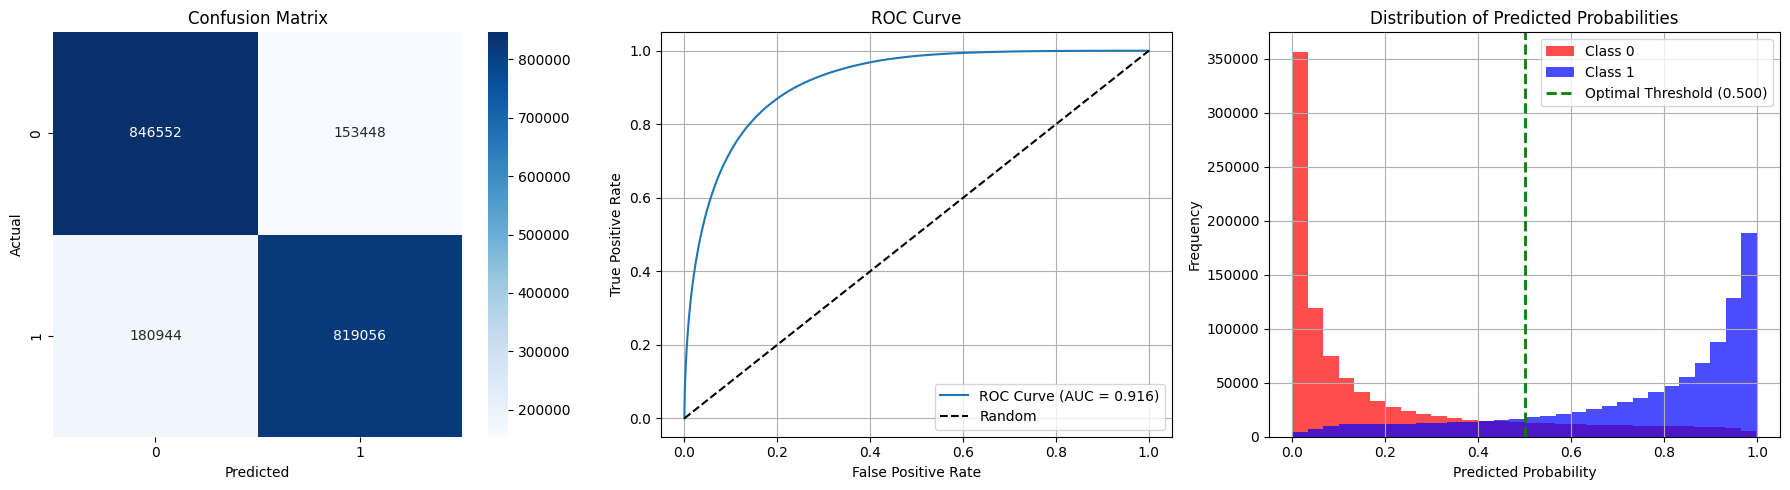

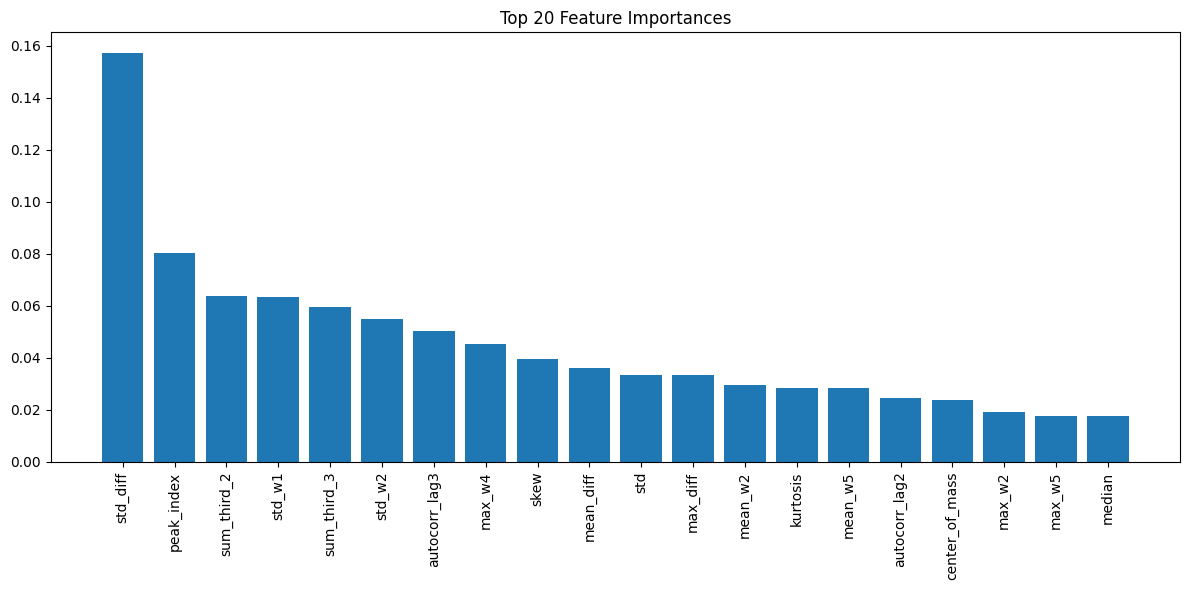

In [21]:
# Evaluate performance
results = classifier.evaluate()
    
classifier.plot_feature_importance(max_features=20)

In [22]:
classifier.save_model(model_output_path)

Successfully saved model at tabnet_compressed_with_features_041025_0700_delivery\models//tabnet_compressed_with_features_041025_0700_delivery_model.zip
Model saved at: tabnet_compressed_with_features_041025_0700_delivery\models//tabnet_compressed_with_features_041025_0700_delivery_model
Model and additional data saved at: tabnet_compressed_with_features_041025_0700_delivery\models//tabnet_compressed_with_features_041025_0700_delivery_model


In [23]:
classifier.load_model(model_output_path)

Additional data file not found, using defaults
Model loaded from: tabnet_compressed_with_features_041025_0700_delivery\models//tabnet_compressed_with_features_041025_0700_delivery_model
Optimal threshold: 0.500



=== THRESHOLD OPTIMIZATION RESULTS ===
Optimization metric: youden
Optimal threshold: 0.420
Metrics at optimal threshold:
  - Precision: 0.8213
  - Recall: 0.8574
  - F1-Score: 0.8390
  - Accuracy: 0.8354
  - Youden's J: 0.6708


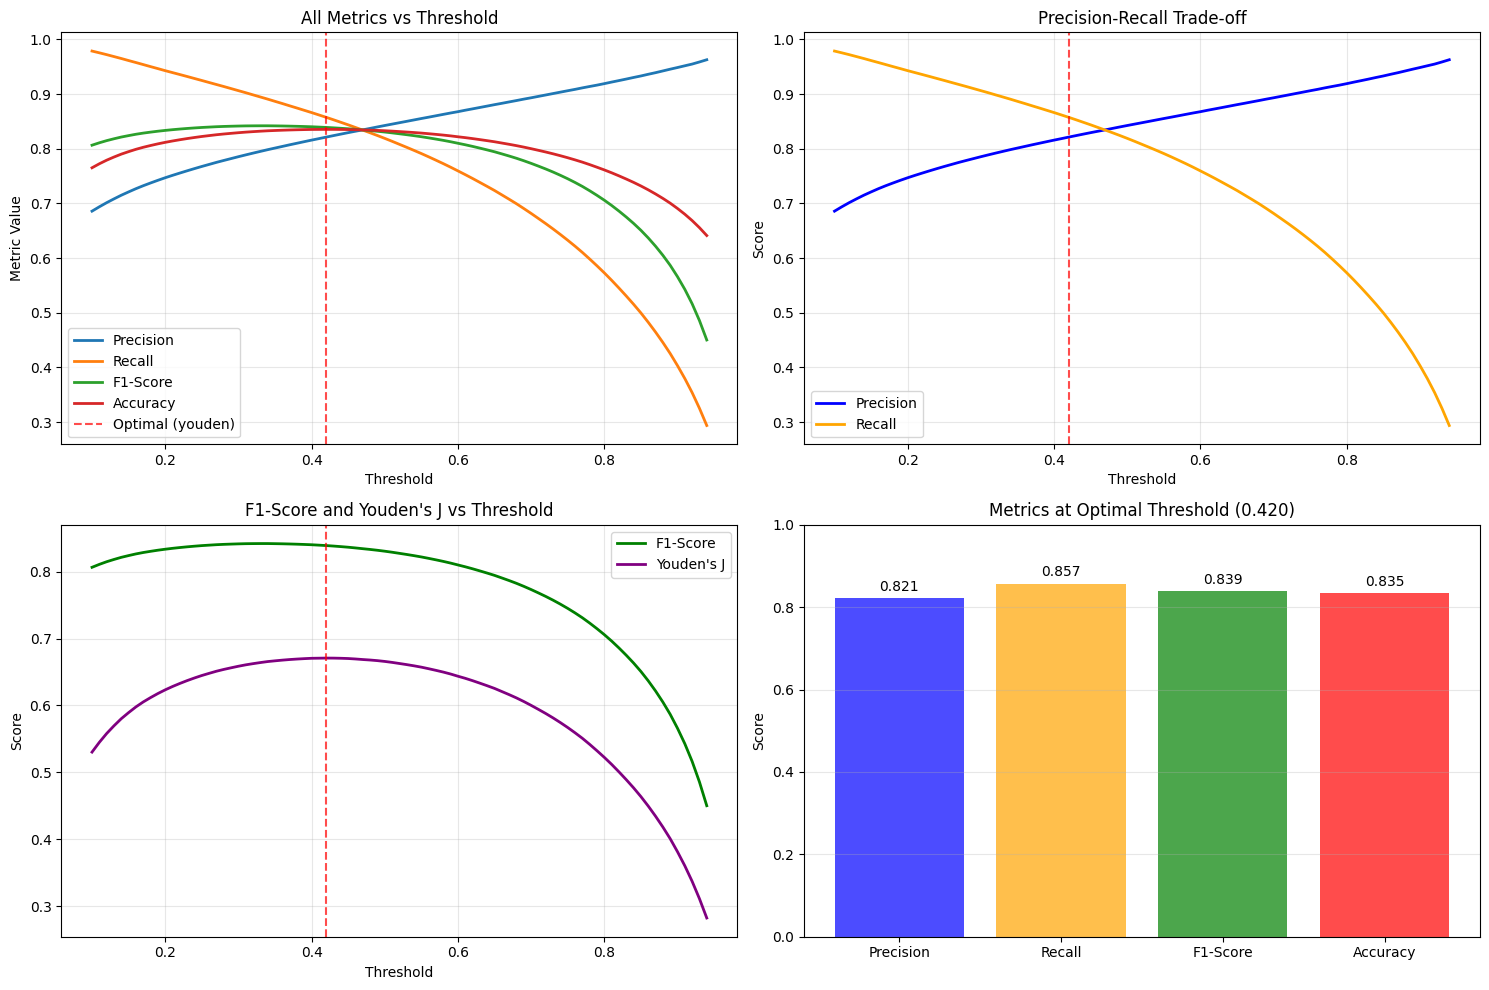


=== EVALUATION RESULTS ===
Threshold used: 0.420
Accuracy: 0.8352
Precision: 0.8210
Recall: 0.8572
F1-Score: 0.8387
AUC Score: 0.9159

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83   1000000
           1       0.82      0.86      0.84   1000000

    accuracy                           0.84   2000000
   macro avg       0.84      0.84      0.84   2000000
weighted avg       0.84      0.84      0.84   2000000



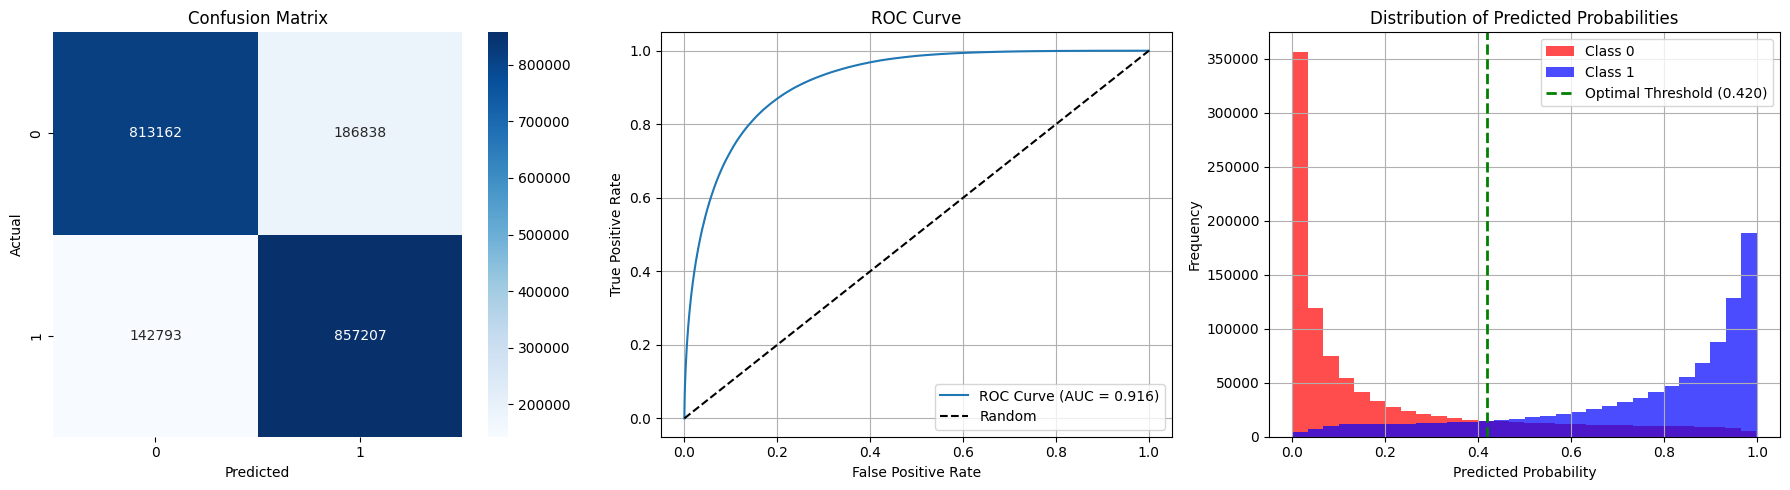

Successfully saved model at tabnet_compressed_with_features_041025_0700_delivery/tabnet_compressed_with_features_041025_0700_youden.zip.zip
Model saved at: tabnet_compressed_with_features_041025_0700_delivery/tabnet_compressed_with_features_041025_0700_youden.zip
Model and additional data saved at: tabnet_compressed_with_features_041025_0700_delivery/tabnet_compressed_with_features_041025_0700_youden.zip


In [24]:
# Ottimizza la soglia (puoi scegliere tra 'f1', 'precision', 'recall', 'accuracy', 'youden')
threshold_results = classifier.optimize_threshold(metric='youden', plot=True)

# Valuta con la soglia ottimizzata
results = classifier.evaluate(use_optimal_threshold=True, plot_results=True)

# Fai predizioni con la soglia ottimizzata
predictions = classifier.predict(use_optimal_threshold=True)

# Save model
model_path_youden = f'{OUTPUT_DIR}/{MODEL_KEYWORD}_{time_stamp}_youden.zip'
classifier.save_model(model_path_youden)


=== THRESHOLD OPTIMIZATION RESULTS ===
Optimization metric: youden
Optimal threshold: 0.420
Metrics at optimal threshold:
  - Precision: 0.8213
  - Recall: 0.8574
  - F1-Score: 0.8390
  - Accuracy: 0.8354
  - Youden's J: 0.6708


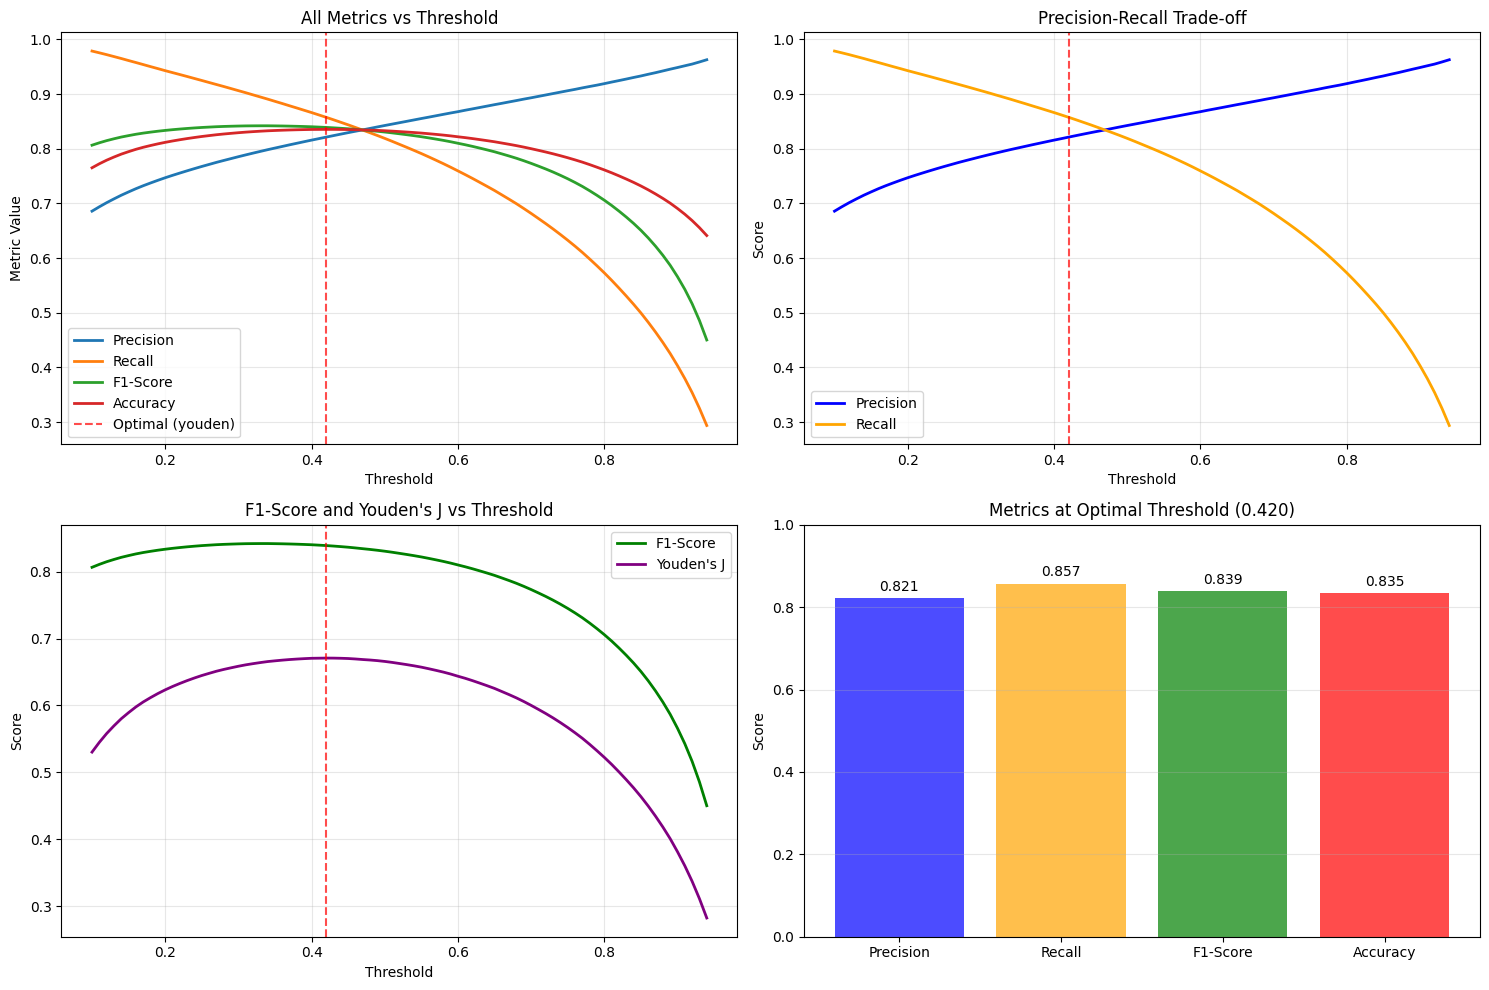


=== EVALUATION RESULTS ===
Threshold used: 0.420
Accuracy: 0.8352
Precision: 0.8210
Recall: 0.8572
F1-Score: 0.8387
AUC Score: 0.9159

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83   1000000
           1       0.82      0.86      0.84   1000000

    accuracy                           0.84   2000000
   macro avg       0.84      0.84      0.84   2000000
weighted avg       0.84      0.84      0.84   2000000



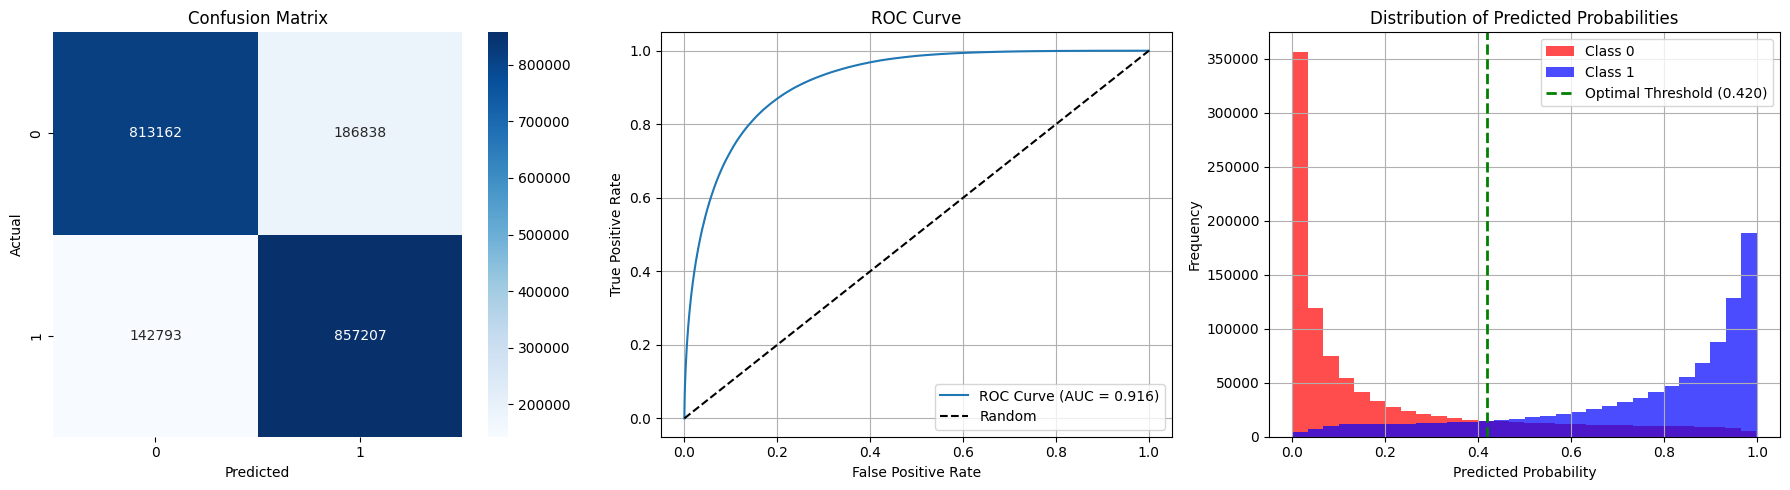

Successfully saved model at tabnet_compressed_with_features_041025_0700_delivery/tabnet_compressed_with_features_041025_0700_youden.zip.zip
Model saved at: tabnet_compressed_with_features_041025_0700_delivery/tabnet_compressed_with_features_041025_0700_youden.zip
Model and additional data saved at: tabnet_compressed_with_features_041025_0700_delivery/tabnet_compressed_with_features_041025_0700_youden.zip


In [25]:
# Ottimizza la soglia (puoi scegliere tra 'f1', 'precision', 'recall', 'accuracy', 'youden')
threshold_results = classifier.optimize_threshold(metric='youden', plot=True)

# Valuta con la soglia ottimizzata
results = classifier.evaluate(use_optimal_threshold=True, plot_results=True)

# Fai predizioni con la soglia ottimizzata
predictions = classifier.predict(use_optimal_threshold=True)

# Save model
model_path_youden = f'{OUTPUT_DIR}/{MODEL_KEYWORD}_{time_stamp}_youden.zip'
classifier.save_model(model_path_youden)

### Hypperparameters search with optuna



In [26]:
from sklearn.utils import resample

class TabNetBinaryClassifierOptuna:
    """
    Class for training a TabNet binary classifier with GPU support and Optuna hyperparameter optimization
    """
    
    def __init__(self,
                 X_original=None,
                 y_original=None,
                 scaler_path=None,
                 fraction_for_optimization=0.20,
                 features=None,
                 n_d=32,
                 n_a=32,
                 n_steps=5,
                 gamma=1.3,
                 n_independent=2,
                 n_shared=2,
                 lambda_sparse=1e-3,
                 optimizer_fn=torch.optim.Adam,
                 optimizer_params=dict(lr=1e-2),
                 mask_type='entmax',
                 scheduler_params=dict(step_size=50, gamma=0.9),
                 scheduler_fn=torch.optim.lr_scheduler.StepLR,
                 epsilon=1e-15,
                 device_name='auto'):
        """
        Initialize the TabNet classifier
        
        Parameters:
        -----------
        X_original : DataFrame or array
            Original features
        y_original : Series or array
            Original target
        scaler_path : str
            Path to saved scaler (optional)
        features : list
            List of feature names to scale
        n_d : int
            Dimension of learned representations
        n_a : int 
            Dimension of attention
        n_steps : int
            Number of steps in feature selection
        gamma : float
            Coefficient for aggregated attention
        lambda_sparse : float
            Regularization coefficient for sparsity
        device_name : str
            'auto', 'cuda', 'cpu' or specific device ('cuda:0')
        """
        
        # Device configuration
        self.device = self._setup_device(device_name)
        print(f"Device used: {self.device}")
        
        self.tabnet_params = {
            'n_d': n_d,
            'n_a': n_a, 
            'n_steps': n_steps,
            'gamma': gamma,
            'n_independent': n_independent,
            'n_shared': n_shared,
            'lambda_sparse': lambda_sparse,
            'optimizer_fn': optimizer_fn,
            'optimizer_params': optimizer_params,
            'mask_type': mask_type,
            'scheduler_params': scheduler_params,
            'scheduler_fn': scheduler_fn,
            'epsilon': epsilon,
            'device_name': self.device
        }
        
        self.model = None
        self.feature_names = None
        self.is_fitted = False
        self.best_params = None
        self.study = None
        self.X_original = X_original
        self.y_original = y_original
        self.scaler_path = scaler_path
        self.features = features
        self.fraction_for_optimization = fraction_for_optimization

    def _setup_device(self, device_name):
        """Configure the computing device (CPU/GPU)"""
        if device_name == 'auto':
            if torch.cuda.is_available():
                device = 'cuda'
                print(f"GPU available: {torch.cuda.get_device_name()}")
                print(f"GPU memory available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
            else:
                device = 'cpu'
                print("GPU not available, using CPU")
        else:
            device = device_name
            if device.startswith('cuda') and not torch.cuda.is_available():
                print("WARNING: GPU requested but not available, using CPU")
                device = 'cpu'
        
        return device
    
    def get_gpu_memory_info(self):
        """Returns GPU memory information"""
        if torch.cuda.is_available() and self.device.startswith('cuda'):
            device_idx = 0 if self.device == 'cuda' else int(self.device.split(':')[1])
            allocated = torch.cuda.memory_allocated(device_idx) / 1e9
            reserved = torch.cuda.memory_reserved(device_idx) / 1e9
            total = torch.cuda.get_device_properties(device_idx).total_memory / 1e9
            
            print("GPU Memory:")
            print(f"  - Allocated: {allocated:.2f} GB")
            print(f"  - Reserved: {reserved:.2f} GB") 
            print(f"  - Total: {total:.2f} GB")
            print(f"  - Free: {total - reserved:.2f} GB")
            
            return {
                'allocated': allocated,
                'reserved': reserved,
                'total': total,
                'free': total - reserved
            }
        else:
            print("GPU memory not available")
            return None
    
    def clear_gpu_memory(self):
        """Clear GPU memory"""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    def create_balanced_subset(self, X, y, subset_fraction=int, random_state=42):
        """
        Crea un subset bilanciato di X e y, di dimensione pari a subset_fraction dell'input.
        Restituisce X_subset_hyperparameters, y_subset_hyperparameters.
        """

        # Calcola la dimensione desiderata del subset
        n_samples = int(len(y) * subset_fraction)
        # Trova le classi e la dimensione minima per classe
        classes = np.unique(y)
        n_classes = len(classes)
        n_per_class = n_samples // n_classes

        # Prepara liste per i dati bilanciati
        X_list = []
        y_list = []

        for cls in classes:
            idx = np.where(y == cls)[0]
            # Se la classe ha meno elementi di n_per_class, fa upsample
            if len(idx) < n_per_class:
                idx_sampled = resample(idx, replace=True, n_samples=n_per_class, random_state=random_state)
            else:
                idx_sampled = resample(idx, replace=False, n_samples=n_per_class, random_state=random_state)
            X_list.append(X.iloc[idx_sampled] if hasattr(X, 'iloc') else X[idx_sampled])
            y_list.append(y.iloc[idx_sampled] if hasattr(y, 'iloc') else y[idx_sampled])

        # Concatena e mescola
        X_subset = pd.concat(X_list).reset_index(drop=True) if hasattr(X, 'iloc') else np.concatenate(X_list)
        y_subset = pd.concat(y_list).reset_index(drop=True) if hasattr(y, 'iloc') else np.concatenate(y_list)

        # Shuffle finale
        if hasattr(X_subset, 'sample'):
            shuffled = X_subset.sample(frac=1, random_state=random_state).index
            X_subset = X_subset.loc[shuffled].reset_index(drop=True)
            y_subset = y_subset.loc[shuffled].reset_index(drop=True)
        else:
            idx = np.arange(len(y_subset))
            np.random.seed(random_state)
            np.random.shuffle(idx)
            X_subset = X_subset[idx]
            y_subset = y_subset[idx]

        return X_subset, y_subset

    def split_train_val_test(self, X, y, train_size=0.64, val_size=0.16, test_size=0.20, random_state=42, stratify=True):
        """
        Split arrays or matrices into train, validation, and test subsets.

        Parameters:
        -----------
        X : np.ndarray or pd.DataFrame
            Features.
        y : np.ndarray or pd.Series
            Labels.
        train_size : float
            Proportion of the dataset to include in the train split.
        val_size : float
            Proportion of the dataset to include in the validation split.
        test_size : float
            Proportion of the dataset to include in the test split.
        random_state : int
            Random seed.
        stratify : bool
            Whether to stratify splits by y.

        Returns:
        --------
        X_train, X_val, X_test, y_train, y_val, y_test
        """
        assert abs(train_size + val_size + test_size - 1.0) < 1e-6, "Splits must sum to 1.0"

        stratify_y = y if stratify else None

        # First split: train+val vs test
        X_trainval, X_test, y_trainval, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=stratify_y
        )

        # Compute val proportion of trainval
        val_prop = val_size / (train_size + val_size)
        stratify_trainval = y_trainval if stratify else None

        # Second split: train vs val
        X_train, X_val, y_train, y_val = train_test_split(
            X_trainval, y_trainval, test_size=val_prop, random_state=random_state, stratify=stratify_trainval
        )

        return X_train, X_val, X_test, y_train, y_val, y_test

    def prepare_data(self, X=None, y=None, test_size=0.2, random_state=42):
        """Prepare data for training"""
        
        X = self.X_original if X is None else X
        y = self.y_original if y is None else y

        
        self.X_subset_hyperparameters, self.y_subset_hyperparameters = self.create_balanced_subset(X, y, subset_fraction=self.fraction_for_optimization if self.fraction_for_optimization is not None else 0.2, random_state=random_state)
        print(f"Subset shape: {self.X_subset_hyperparameters.shape}, {self.y_subset_hyperparameters.shape}")
        print(f"Class distribution in subset: {self.y_subset_hyperparameters.value_counts()}" if hasattr(self.y_subset_hyperparameters, 'value_counts') else np.bincount(self.y_subset_hyperparameters))
        
        # Save feature names
        if hasattr(X, 'columns'):
            self.feature_names = self.X_subset_hyperparameters.columns.tolist()

        # Convert to float32 to optimize GPU memory
        if isinstance(self.X_subset_hyperparameters, pd.DataFrame):
            self.X_subset_hyperparameters = self.X_subset_hyperparameters.astype(np.float32)

        self.X_train_hyperparameters, self.X_val_hyperparameters, self.X_test_hyperparameters, self.y_train_hyperparameters, self.y_val_hyperparameters, self.y_test_hyperparameters = self.split_train_val_test(
            self.X_subset_hyperparameters, self.y_subset_hyperparameters, train_size=0.64, val_size=0.16, test_size=0.20, random_state=42
        )
        self.X_train_finalize, self.X_val_finalize, self.X_test_finalize, self.y_train_finalize, self.y_val_finalize, self.y_test_finalize = self.split_train_val_test(
            self.X_original, self.y_original, train_size=0.64, val_size=0.16, test_size=0.20, random_state=42
        )

        # Reset indices
        if isinstance(self.X_train_hyperparameters, pd.DataFrame):
            self.X_train_hyperparameters = self.X_train_hyperparameters.reset_index(drop=True)
            self.X_val_hyperparameters = self.X_val_hyperparameters.reset_index(drop=True)
            self.X_test_hyperparameters = self.X_test_hyperparameters.reset_index(drop=True)
        if isinstance(self.y_train_hyperparameters, pd.Series):
            self.y_train_hyperparameters = self.y_train_hyperparameters.reset_index(drop=True)
            self.y_val_hyperparameters = self.y_val_hyperparameters.reset_index(drop=True)
            self.y_test_hyperparameters = self.y_test_hyperparameters.reset_index(drop=True)

        # Reset indices
        if isinstance(self.X_train_finalize, pd.DataFrame):
            self.X_train_finalize = self.X_train_finalize.reset_index(drop=True)
            self.X_val_finalize = self.X_val_finalize.reset_index(drop=True)
            self.X_test_finalize = self.X_test_finalize.reset_index(drop=True)
        if isinstance(self.y_train_finalize, pd.Series):
            self.y_train_finalize = self.y_train_finalize.reset_index(drop=True)
            self.y_val_finalize = self.y_val_finalize.reset_index(drop=True)
            self.y_test_finalize = self.y_test_finalize.reset_index(drop=True)

    

        # Apply scaler if provided
        if self.scaler_path is not None and self.features is not None:
            print(f"Loading scaler from: {self.scaler_path}")
            self.scaler = joblib.load(self.scaler_path)
            
            column_trans = ColumnTransformer(
                [('scaler', self.scaler, self.features)],
                remainder='passthrough',
                n_jobs=-1
            )
        else:
            self.scaler = StandardScaler()
            
            column_trans = ColumnTransformer(
                [('scaler', self.scaler, self.features)],
                remainder='passthrough',
                n_jobs=-1
            )
        self.scaler = column_trans.fit(self.X_train_hyperparameters[self.features], self.y_train_hyperparameters)

        self.scaler_path = f'{os.environ["MODELS_DIR"]}/{os.environ["ML_FLOW_EXPERIMENT_NAME"]}_optuna_scaler.joblib'
        print(f"Saving fitted scaler to: {Path(self.scaler_path)}")
        joblib.dump(self.scaler, self.scaler_path)

        self.X_train_finalize = column_trans.transform(self.X_train_finalize)
        self.X_val_finalize = column_trans.transform(self.X_val_finalize)
        self.X_test_finalize = column_trans.transform(self.X_test_finalize)

        self.X_train_hyperparameters = column_trans.fit_transform(self.X_train_hyperparameters, self.y_train_hyperparameters)
        self.X_val_hyperparameters = column_trans.transform(self.X_val_hyperparameters)
        self.X_test_hyperparameters = column_trans.transform(self.X_test_hyperparameters)


        self.X_train_hyperparameters = self.X_train_hyperparameters.astype(np.float32)
        self.X_val_hyperparameters = self.X_val_hyperparameters.astype(np.float32)
        self.X_test_hyperparameters = self.X_test_hyperparameters.astype(np.float32)
        self.X_train_hyperparameters = self.X_train_hyperparameters.values if hasattr(self.X_train_hyperparameters, 'values') else self.X_train_hyperparameters.reshape(-1, self.X_train_hyperparameters.shape[1])
        self.X_val_hyperparameters = self.X_val_hyperparameters.values if hasattr(self.X_val_hyperparameters, 'values') else self.X_val_hyperparameters.reshape(-1, self.X_val_hyperparameters.shape[1])
        self.X_test_hyperparameters = self.X_test_hyperparameters.values if hasattr(self.X_test_hyperparameters, 'values') else self.X_test_hyperparameters.reshape(-1, self.X_test_hyperparameters.shape[1])

        self.y_train_hyperparameters = self.y_train_hyperparameters.astype(np.int32)
        self.y_val_hyperparameters = self.y_val_hyperparameters.astype(np.int32)
        self.y_test_hyperparameters = self.y_test_hyperparameters.astype(np.int32)
        self.y_train_hyperparameters = self.y_train_hyperparameters.values if hasattr(self.y_train_hyperparameters, 'values') else self.y_train_hyperparameters.reshape(-1)
        self.y_val_hyperparameters = self.y_val_hyperparameters.values if hasattr(self.y_val_hyperparameters, 'values') else self.y_val_hyperparameters.reshape(-1)
        self.y_test_hyperparameters = self.y_test_hyperparameters.values if hasattr(self.y_test_hyperparameters, 'values') else self.y_test_hyperparameters.reshape(-1)

        self.X_train_finalize = self.X_train_finalize.astype(np.float32)
        self.X_val_finalize = self.X_val_finalize.astype(np.float32)
        self.X_test_finalize = self.X_test_finalize.astype(np.float32)
        self.X_train_finalize = self.X_train_finalize.values if hasattr(self.X_train_finalize, 'values') else self.X_train_finalize.reshape(-1, self.X_train_finalize.shape[1])
        self.X_val_finalize = self.X_val_finalize.values if hasattr(self.X_val_finalize, 'values') else self.X_val_finalize.reshape(-1, self.X_val_finalize.shape[1])
        self.X_test_finalize = self.X_test_finalize.values if hasattr(self.X_test_finalize, 'values') else self.X_test_finalize.reshape(-1, self.X_test_finalize.shape[1])

        self.y_train_finalize = self.y_train_finalize.astype(np.int32)
        self.y_val_finalize = self.y_val_finalize.astype(np.int32)
        self.y_test_finalize = self.y_test_finalize.astype(np.int32)
        self.y_train_finalize = self.y_train_finalize.values if hasattr(self.y_train_finalize, 'values') else self.y_train_finalize.reshape(-1)
        self.y_val_finalize = self.y_val_finalize.values if hasattr(self.y_val_finalize, 'values') else self.y_val_finalize.reshape(-1)
        self.y_test_finalize = self.y_test_finalize.values if hasattr(self.y_test_finalize, 'values') else self.y_test_finalize.reshape(-1)
        
        print("Data prepared:")
        print(f"  - Training set hyperparameters: {self.X_train_hyperparameters.shape}")
        print(f"  - Validation set hyperparameters: {self.X_val_hyperparameters.shape}")
        print(f"  - Test set hyperparameters: {self.X_test_hyperparameters.shape}")

        print("  - Training set finalization: ", self.X_train_finalize.shape)
        print("  - Validation set finalization: ", self.X_val_finalize.shape)
        print("  - Test set finalization: ", self.X_test_finalize.shape)

        return self.X_train_hyperparameters, self.X_val_hyperparameters, self.X_test_hyperparameters, self.y_train_hyperparameters, self.y_val_hyperparameters, self.y_test_hyperparameters

    def optimize_hyperparameters(self, 
                                n_trials=50,
                                study_name=None,
                                metric='auc',
                                direction='maximize',
                                pruning=True,
                                timeout=None,
                                max_epochs_optuna=50,
                                patience_optuna=10):
        """
        Optimize hyperparameters using Optuna with enhanced parameter ranges
        
        Parameters:
        -----------
        n_trials : int
            Number of optimization trials
        study_name : str
            Name for the study (optional)
        metric : str
            Metric to optimize ('auc' or 'accuracy')
        direction : str
            'maximize' or 'minimize'
        pruning : bool
            Whether to use pruning for early trial termination
        timeout : int
            Time limit in seconds (None for no limit)
        max_epochs_optuna : int
            Max epochs for each trial
        patience_optuna : int
            Patience for each trial
        """

        # Prepare data
        self.prepare_data()

        print("\n=== STARTING HYPERPARAMETER OPTIMIZATION ===")
        print(f"Trials: {n_trials}")
        print(f"Metric: {metric}")
        print(f"Direction: {direction}")
        print(f"Max epochs per trial: {max_epochs_optuna}")
        
        def objective(trial):
            """Objective function for Optuna optimization"""
            
            n_d = trial.suggest_categorical('n_d', [64, 128, 256])
            n_a = trial.suggest_categorical('n_a', [64, 128, 256])
            n_steps = trial.suggest_int('n_steps', 3, 7)
            gamma = trial.suggest_float('gamma', 1.0, 2.0, step=0.1)
            
            # Assicura n_shared >= n_independent
            n_independent = trial.suggest_int('n_independent', 1, 3)
            n_shared = trial.suggest_int('n_shared', n_independent, 6)

            # Regolarizzazione e ottimizzazione
            lambda_sparse = trial.suggest_float('lambda_sparse', 1e-6, 1e-3, log=True)
            momentum = trial.suggest_float('momentum', 0.02, 0.42, step=0.04)
            clip_value = trial.suggest_float('clip_value', 0.5, 2.0, step=0.5)
            
            # lr - Learning rate
            lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
            
            # Scheduler
            scheduler_type = trial.suggest_categorical('scheduler_type', 
                                                ['step', 'plateau', 'cosine'])
    
            if scheduler_type == 'step':
                scheduler_params = {
                    'step_size': trial.suggest_int('step_size', 10, 40, step=5),
                    'gamma': trial.suggest_float('scheduler_gamma', 0.75, 0.95, step=0.05)
                }
                scheduler_fn = torch.optim.lr_scheduler.StepLR
                # Remove step-specific params if present
                # Remove step-specific params if present
                try:
                    self.best_params.pop('factor', None)
                    self.best_params.pop('patience', None)
                    self.best_params.pop('min_lr', None)
                    self.best_params.pop('T_max', None)
                    self.best_params.pop('eta_min', None)
                except:
                    pass

            elif scheduler_type == 'plateau':
                scheduler_params = {
                    'mode': 'max',  # Importante: 'max' per AUC!
                    'factor': trial.suggest_float('scheduler_factor', 0.5, 0.8, step=0.1),
                    'patience': trial.suggest_int('scheduler_patience', 5, 15),
                    'min_lr': 1e-6
                }
                scheduler_fn = torch.optim.lr_scheduler.ReduceLROnPlateau
                try:
                    self.best_params.pop('step_size', None)
                    self.best_params.pop('scheduler_gamma', None)
                    self.best_params.pop('T_max', None)
                    self.best_params.pop('eta_min', None)
                except:
                    pass

            else:  # cosine
                scheduler_params = {
                    'T_max': trial.suggest_int('T_max', 30, 100, step=10)
                }
                scheduler_fn = torch.optim.lr_scheduler.CosineAnnealingLR
                try:
                    self.best_params.pop('step_size', None)
                    self.best_params.pop('scheduler_gamma', None)
                    self.best_params.pop('factor', None)
                    self.best_params.pop('patience', None)
                    self.best_params.pop('min_lr', None)
                except:
                    pass


            # Mask type
            mask_type = trial.suggest_categorical('mask_type', ['entmax', 'sparsemax'])
            
            # Batch sizes
            batch_size= trial.suggest_categorical('batch_size', [256, 512, 1024, 2048])
            
            virtual_batch_ratio = trial.suggest_categorical('virtual_batch_ratio', [0.25, 0.5, 1.0])
            virtual_batch_size = max(128, int(batch_size * virtual_batch_ratio))
            
            # Safety check
            if virtual_batch_size > batch_size:
                virtual_batch_size = batch_size
            
            # Costruisci parametri
            params = {
                'n_d': n_d,
                'n_a': n_a,
                'n_steps': n_steps,
                'gamma': gamma,
                'n_independent': n_independent,
                'n_shared': n_shared,
                'lambda_sparse': lambda_sparse,
                'momentum': momentum,
                'clip_value': clip_value,
                'optimizer_fn': torch.optim.AdamW,
                'optimizer_params': {'lr': lr},
                'mask_type': mask_type,
                'scheduler_params': scheduler_params,
                'scheduler_fn': scheduler_fn,
                'epsilon': 1e-15,
                'device_name': self.device,
                'verbose': 0,
            }
            
            # Create temporary model
            temp_model = TabNetClassifier(**params)
            
            try:
                # Clear GPU memory before each trial
                #if self.device.startswith('cuda'):
                #    self.clear_gpu_memory()
                
                # Train model
                temp_model.fit(
                    X_train=self.X_train_hyperparameters,
                    y_train=self.y_train_hyperparameters,
                    eval_set=[(self.X_val_hyperparameters, self.y_val_hyperparameters)],
                    eval_name=['val'],
                    eval_metric=['auc'],#['accuracy', 'auc'],
                    max_epochs=max_epochs_optuna,
                    patience=patience_optuna,
                    batch_size=batch_size,
                    virtual_batch_size=virtual_batch_size,
                    #num_workers=0,
                    drop_last=False
                )
                self
                
                # Make predictions on validation set
                y_pred_proba = temp_model.predict_proba(self.X_val_hyperparameters)
                y_pred = temp_model.predict(self.X_val_hyperparameters)

                # Calculate metrics
                if metric == 'auc':
                    score = roc_auc_score(self.y_val_hyperparameters, y_pred_proba[:, 1])
                elif metric == 'accuracy':
                    score = accuracy_score(self.y_val_hyperparameters, y_pred)
                else:
                    raise ValueError(f"Unsupported metric: {metric}")
                
                # Report intermediate values for pruning
                trial.report(score, step=max_epochs_optuna)
                
                # Handle pruning
                if trial.should_prune():
                    raise optuna.exceptions.TrialPruned()
                
                return score
                
            except Exception as e:
                print(f"Trial failed: {str(e)}")
                return 0.0 if direction == 'maximize' else float('inf')
            
            finally:
                # Clean up memory
                del temp_model
                #if self.device.startswith('cuda'):
                    #self.clear_gpu_memory()
        
        # Create study with MedianPruner
        sampler = TPESampler(seed=42,
                        n_startup_trials=10
                        )

        pruner = MedianPruner(
            n_startup_trials=5,
            n_warmup_steps=7,
            interval_steps=3,
            
        ) if pruning else None
        
        study_name = study_name or f"tabnet_optimization_{metric}"
        self.study = optuna.create_study(
            direction=direction,
            sampler=sampler,
            pruner=pruner,
            study_name=study_name
        )
        
        # Run optimization
        print("\nRunning optimization...")
        self.study.optimize(
            objective, 
            n_trials=n_trials,
            n_jobs=1,  # TabNet is not thread-safe
            timeout=timeout,
            show_progress_bar=True
        )
        
        # Store best parameters
        self.best_params = self.study.best_params.copy()
        
        # Print results
        print(f"\n{'='*60}")
        print("OPTIMIZATION COMPLETED")
        print(f"{'='*60}")
        print(f"Best {metric}: {self.study.best_value:.4f}")
        print("\nBest parameters:")
        for key, value in self.best_params.items():
            print(f"  {key}: {value}")
        
        print("\nOptimization statistics:")
        print(f"  - Total trials: {len(self.study.trials)}")
        print(f"  - Completed: {len([t for t in self.study.trials if t.state == optuna.trial.TrialState.COMPLETE])}")
        print(f"  - Pruned: {len([t for t in self.study.trials if t.state == optuna.trial.TrialState.PRUNED])}")
        print(f"  - Failed: {len([t for t in self.study.trials if t.state == optuna.trial.TrialState.FAIL])}")
        print(f"{'='*60}")
        
        return self.study
    
    def train_with_best_params(self, 
                              max_epochs=200, 
                              patience=20,
                              num_workers=0,
                              drop_last=False):

        """Train model with best parameters found by Optuna"""
        if self.best_params is None:
            raise ValueError("You must first run optimize_hyperparameters()")
        
        print("\n=== TRAINING WITH BEST PARAMETERS ===")
        
        # Extract training parameters
        self.best_params.pop("virtual_batch_ratio", None)
        batch_size = self.best_params['batch_size']
        virtual_batch_size = self.best_params['batch_size'] + 128
        lr = self.best_params.pop('lr', self.best_params['lr'])
        scheduler_type = self.best_params['scheduler_type']#.pop('scheduler_type', 'step')
        
        # Build scheduler params based on type
        if scheduler_type == 'step':
            step_size = self.best_params['step_size']#.pop('step_size', 50)
            scheduler_gamma = self.best_params['scheduler_gamma']#.pop('scheduler_gamma', 0.9)
            scheduler_params = {'step_size': step_size, 
            'gamma': scheduler_gamma}
            scheduler_fn = torch.optim.lr_scheduler.StepLR

            # Remove other schedulers params if present
            self.best_params.pop('scheduler_factor', None)
            self.best_params.pop('scheduler_patience', None)
            self.best_params.pop('T_max', None)
            self.best_params.pop('eta_min', None)
            self.best_params.pop('scheduler_type', None)

        elif scheduler_type =='plateau':
            scheduler_factor = self.best_params['scheduler_factor'].pop('scheduler_factor', 0.7)
            scheduler_patience = self.best_params['scheduler_patience']#.pop('scheduler_patience', 10)
            scheduler_params = {
                'mode': 'min',
                'factor': scheduler_factor,
                'patience': scheduler_patience,
                'min_lr': 1e-6
            }
            scheduler_fn = torch.optim.lr_scheduler.ReduceLROnPlateau
            # Remove other scheduler params if present
            self.best_params.pop('step_size', None)
            self.best_params.pop('scheduler_gamma', None)
            self.best_params.pop('T_max', None)
            self.best_params.pop('eta_min', None)
            self.best_params.pop('scheduler_type', None)

        else:
            scheduler_type== 'cosine'
            scheduler_tmax = self.best_params['T_max']
            scheduler_params = {
                'T_max' : scheduler_tmax
            }
            scheduler_fn = torch.optim.lr_scheduler.CosineAnnealingLR
            # Remove other scheduler params if present
            self.best_params.pop('step_size', None)
            self.best_params.pop('scheduler_gamma', None)
            self.best_params.pop('scheduler_factor', None)
            self.best_params.pop('scheduler_patience', None)
            self.best_params.pop('scheduler_type', None)
            self.best_params.pop('T_max', None)
            

        # Update tabnet_params with best parameters
        self.tabnet_params.update(self.best_params)
        self.tabnet_params.pop('batch_size', None)
        self.tabnet_params.pop('virtual_batch_size', None)
        self.tabnet_params['optimizer_fn'] = torch.optim.AdamW
        self.tabnet_params['optimizer_params'] = {'lr': lr}
        self.tabnet_params['scheduler_params'] = scheduler_params
        self.tabnet_params['scheduler_fn'] = scheduler_fn
        
        # Train with original method using best parameters
        print("Training with parameters:")
        for key, value in self.tabnet_params.items():
            print(f"  {key}: {value}")
        print('' + '='*60)
        print("and with data shapes:")
        print(f"  - Features: {self.X_original.shape}")
        print(f"  - Labels: {self.y_original.shape}")

        return self.train(
            self.X_train_finalize,
            self.y_train_finalize,
            self.X_val_finalize,
            self.y_val_finalize,
            self.X_test_finalize,
            self.y_test_finalize,
            max_epochs=max_epochs,
            patience=patience,
            batch_size=batch_size,
            virtual_batch_size=virtual_batch_size,
            num_workers=num_workers,
            drop_last=drop_last
        )
    
    def train(self, 
              X_train=None, 
              y_train=None,
              X_val=None,
              y_val=None,
              X_test=None,
              y_test=None,
              max_epochs=200, 
              patience=20, 
              batch_size=1024,
              virtual_batch_size=128,
              num_workers=0,
              drop_last=False):

        """Train the TabNet model"""
        
        # Prepare data if not already done
        if not hasattr(self, 'X_train_hyperparameters'):
            self.prepare_data()
        
        # Adapt batch_size for GPU
        if self.device.startswith('cuda'):
            gpu_memory = self.get_gpu_memory_info()
            if gpu_memory and gpu_memory['free'] < 2.0:
                suggested_batch_size = min(batch_size, 512)
                print(f"Limited GPU memory, reducing batch_size to {suggested_batch_size}")
                batch_size = suggested_batch_size
        
        print("Training configuration:")
        print(f"  - Device: {self.device}")
        print(f"  - Batch size: {batch_size}")
        print(f"  - Virtual batch size: {virtual_batch_size}")
        print(f"  - Max epochs: {max_epochs}")
        print(f"  - Patience: {patience}")
        
        # Initialize model
        self.model = TabNetClassifier(**self.tabnet_params )
        
        # Clear GPU memory before training
        if self.device.startswith('cuda'):
            self.clear_gpu_memory()
            print("\nGPU memory before training:")
            self.get_gpu_memory_info()
        
        print("\nStarting TabNet training...") 
        
        try:
            self.model.fit(
                X_train=X_train,
                y_train=y_train,
                eval_set=[(X_val, y_val)],
                eval_name=['val'],
                eval_metric=['accuracy', 'auc'],
                
                max_epochs=max_epochs,
                patience=patience,
                batch_size=batch_size,
                virtual_batch_size=virtual_batch_size,
                num_workers=num_workers,
                drop_last=drop_last
            )
            
            self.is_fitted = True
            print("Training completed!")
            
            # Check memory after training
            if self.device.startswith('cuda'):
                print("\nGPU memory after training:")
                self.get_gpu_memory_info()
                
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print("\nERROR: Insufficient GPU memory!")
                self.clear_gpu_memory()
            raise e
        
        return self.model
    
    def predict(self, X=None):
        """Make predictions"""
        if not self.is_fitted:
            raise ValueError("Model has not been trained yet!")
        
        if X is None:
            X = self.X_test
            
        # Convert to float32
        if isinstance(X, pd.DataFrame):
            X = X.values.astype(np.float32)
        elif not isinstance(X, np.ndarray):
            X = np.array(X, dtype=np.float32)
        else:
            X = X.astype(np.float32)
            
        predictions = self.model.predict(X)
        return predictions
    
    def predict_proba(self, X=None):
        """Return prediction probabilities"""
        if not self.is_fitted:
            raise ValueError("Model has not been trained yet!")
        
        if X is None:
            X = self.X_test
            
        # Convert to float32
        if isinstance(X, pd.DataFrame):
            X = X.values.astype(np.float32)
        elif not isinstance(X, np.ndarray):
            X = np.array(X, dtype=np.float32)
        else:
            X = X.astype(np.float32)
            
        probabilities = self.model.predict_proba(X)
        return probabilities
    
    def evaluate(self, X=None, y=None, plot_results=True):
        """Evaluate model performance"""
        if not self.is_fitted:
            raise ValueError("Model has not been trained yet!")
        
        if X is None:
            X = self.X_test_finalize
            y = self.y_test_finalize
        
        # Predictions
        y_pred = self.predict(X)
        y_pred_proba = self.predict_proba(X)
        
        # Metrics
        accuracy = accuracy_score(y, y_pred)
        auc_score = roc_auc_score(y, y_pred_proba[:, 1])

        print("\n=== EVALUATION RESULTS ===")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"AUC Score: {auc_score:.4f}")
        print("\nClassification Report:")
        print(classification_report(y, y_pred))
        
        if plot_results:
            self.plot_results(y, y_pred, y_pred_proba[:, 1])
        
        return {
            'accuracy': accuracy,
            'auc_score': auc_score,
            'predictions': y_pred,
            'probabilities': y_pred_proba
        }
    
    def plot_results(self, y_true, y_pred, y_pred_proba):
        """Visualize results"""
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
        axes[0].set_title('Confusion Matrix')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Actual')
        
        # ROC Curve
        fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
        auc = roc_auc_score(y_true, y_pred_proba)
        
        axes[1].plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})')
        axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title('ROC Curve')
        axes[1].legend()
        axes[1].grid(True)
        
        # Distribution of Probabilities
        axes[2].hist(y_pred_proba[y_true == 0], bins=30, alpha=0.7, label='Class 0', color='red')
        axes[2].hist(y_pred_proba[y_true == 1], bins=30, alpha=0.7, label='Class 1', color='blue')
        axes[2].set_xlabel('Predicted Probability')
        axes[2].set_ylabel('Frequency')
        axes[2].set_title('Distribution of Predicted Probabilities')
        axes[2].legend()
        axes[2].grid(True)
        
        plt.tight_layout()
        plt.show()
    
    def plot_optimization_history(self):
        """Plot optimization history"""
        if self.study is None:
            raise ValueError("No optimization study found. Run optimize_hyperparameters() first.")
        
        try:
            fig, axes = plt.subplots(2, 2, figsize=(15, 10))
            
            # Optimization history
            trials = self.study.trials
            values = [t.value for t in trials if t.value is not None]
            
            axes[0, 0].plot(values)
            axes[0, 0].set_title('Optimization History')
            axes[0, 0].set_xlabel('Trial')
            axes[0, 0].set_ylabel('Objective Value')
            axes[0, 0].grid(True)
            
            # Parameter importance
            try:
                importance = optuna.importance.get_param_importances(self.study)
                params = list(importance.keys())[:10]
                importances = [importance[p] for p in params]
                
                axes[0, 1].barh(params, importances)
                axes[0, 1].set_title('Parameter Importance (Top 10)')
                axes[0, 1].set_xlabel('Importance')
            except:
                axes[0, 1].text(0.5, 0.5, 'Parameter importance\nnot available', 
                               ha='center', va='center', transform=axes[0, 1].transAxes)
            
            # Correlation heatmap
            if len(trials) > 1:
                param_names = ['n_d', 'n_a', 'n_steps', 'lr', 'batch_size']
                trial_data = []
                for trial in trials:
                    if trial.value is not None:
                        row = [trial.value]
                        for param in param_names:
                            if param in trial.params:
                                row.append(trial.params[param])
                            else:
                                row.append(None)
                        trial_data.append(row)
                
                if trial_data:
                    df = pd.DataFrame(trial_data, columns=['objective'] + param_names)
                    df = df.dropna()
                    
                    if len(df) > 0:
                        corr = df.corr()
                        sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=axes[1, 0])
                        axes[1, 0].set_title('Parameter Correlation')
            
            # Best trial info
            best_trial = self.study.best_trial
            axes[1, 1].text(0.1, 0.9, f'Best Trial: #{best_trial.number}', 
                           fontsize=12, fontweight='bold', transform=axes[1, 1].transAxes)
            axes[1, 1].text(0.1, 0.8, f'Best Value: {best_trial.value:.4f}', 
                           fontsize=11, transform=axes[1, 1].transAxes)
            
            y_pos = 0.7
            axes[1, 1].text(0.1, y_pos, 'Best Parameters:', 
                           fontsize=11, fontweight='bold', transform=axes[1, 1].transAxes)
            y_pos -= 0.08
            
            for key, value in list(best_trial.params.items())[:8]:
                axes[1, 1].text(0.1, y_pos, f'{key}: {value}', fontsize=9,
                               transform=axes[1, 1].transAxes)
                y_pos -= 0.06
            
            axes[1, 1].set_xlim(0, 1)
            axes[1, 1].set_ylim(0, 1)
            axes[1, 1].axis('off')
            
            plt.tight_layout()
            plt.show()
            
        except ImportError:
            print("Matplotlib/Seaborn not available for plotting")
    
    def get_optimization_summary(self):
        """Get summary of optimization results"""
        if self.study is None:
            raise ValueError("No optimization study found. Run optimize_hyperparameters() first.")
        
        summary = {
            'best_value': self.study.best_value,
            'best_params': self.study.best_params,
            'n_trials': len(self.study.trials),
            'completed_trials': len([t for t in self.study.trials if t.state == optuna.trial.TrialState.COMPLETE]),
            'pruned_trials': len([t for t in self.study.trials if t.state == optuna.trial.TrialState.PRUNED]),
            'failed_trials': len([t for t in self.study.trials if t.state == optuna.trial.TrialState.FAIL]),
            'study_name': self.study.study_name
        }
        
        return summary

    def return_scaler(self):
        """Return the fitted scaler"""
        if self.scaler is None:
            raise ValueError("Scaler not found. Ensure data preparation has been done.")
        return self.scaler, self.scaler_path    
    
    def save_model(self, filepath):
        """Save the model"""
        self.model_path = filepath 
        self.model.save_model(self.model_path)

        print(f"Model saved at: {self.model_path}")
        print(f"Scaler saved at: {self.scaler_path}")

    def load_model(self, filepath):
        """Load a saved model"""
        self.model = TabNetClassifier(device_name=self.device)
        self.model.load_model(filepath+'.zip')
        self.is_fitted = True
        print(f"Model loaded from: {filepath}.zip")

    
    def get_model_summary(self):
        """Return model and hardware summary"""
        if not self.is_fitted:
            print("Model not yet trained")
            return
        
        print("\n=== MODEL SUMMARY ===")
        print(f"Device: {self.device}")
        print("\nTabNet Parameters:")
        for key, value in self.tabnet_params.items():
            if key != 'device_name':
                print(f"  - {key}: {value}")
        
        if self.best_params:
            print("\nOptimized Parameters:")
            for key, value in self.best_params.items():
                print(f"  - {key}: {value}")
        
        if hasattr(self.model, 'network'):
            total_params = sum(p.numel() for p in self.model.network.parameters())
            trainable_params = sum(p.numel() for p in self.model.network.parameters() if p.requires_grad)
            print("\nModel Parameters:")
            print(f"  - Total: {total_params:,}")
            print(f"  - Trainable: {trainable_params:,}")
        
        if self.device.startswith('cuda'):
            print()
            self.get_gpu_memory_info()

In [27]:
"""{'n_d': 128, 
'n_a': 128, 
'n_steps': 7,
'gamma': 1.7928028379047916,
'n_independent': 3, 
'n_shared': 2,
'lambda_sparse': 0.006173448324113825,
'lr': 0.003775157784702449,
'step_size': 48,
'scheduler_gamma': 0.9035812858076991,
'batch_size': 256,
'virtual_batch_size': 128}"""

"{'n_d': 128, \n'n_a': 128, \n'n_steps': 7,\n'gamma': 1.7928028379047916,\n'n_independent': 3, \n'n_shared': 2,\n'lambda_sparse': 0.006173448324113825,\n'lr': 0.003775157784702449,\n'step_size': 48,\n'scheduler_gamma': 0.9035812858076991,\n'batch_size': 256,\n'virtual_batch_size': 128}"

In [28]:
"""=== OPTIMIZATION COMPLETED ===
Best auc: 0.9657
Best parameters:
  - n_d: 77
  - n_a: 110
  - n_steps: 8
  - gamma: 1.9067107319494947
  - n_independent: 1
  - n_shared: 5
  - lambda_sparse: 0.0005807365274596347
  - lr: 0.003944458659837453
  - step_size: 31
  - scheduler_gamma: 0.953213126517786
  - batch_size: 512
  - virtual_batch_size: 128
  """

'=== OPTIMIZATION COMPLETED ===\nBest auc: 0.9657\nBest parameters:\n  - n_d: 77\n  - n_a: 110\n  - n_steps: 8\n  - gamma: 1.9067107319494947\n  - n_independent: 1\n  - n_shared: 5\n  - lambda_sparse: 0.0005807365274596347\n  - lr: 0.003944458659837453\n  - step_size: 31\n  - scheduler_gamma: 0.953213126517786\n  - batch_size: 512\n  - virtual_batch_size: 128\n  '

In [29]:
# Calculate the optimal fraction for hyperparameter optimization (max 600k samples)
max_optuna_samples = 10000 if TEST_PIPELINE else 500000
n_total = len(features_df_hyperparameters)
optimal_fraction_for_optimization = max(0.0001, max_optuna_samples / n_total)
print(f"Fraction for optimization: {optimal_fraction_for_optimization:.4f} ({int(optimal_fraction_for_optimization * n_total)} samples)")

Fraction for optimization: 0.5000 (500000 samples)


In [30]:
from collections import Counter
Counter(pd.DataFrame(labels_df_hyperparameters)['label'])

Counter({0: 500000, 1: 500000})

In [31]:
# Initialize the classifier
optuna_clf = TabNetBinaryClassifierOptuna(
    X_original=features_df_hyperparameters,
    y_original=pd.DataFrame(labels_df_hyperparameters)['label'],
    fraction_for_optimization=optimal_fraction_for_optimization,  # Use  fracion of data for hyperparameter optimization
    scaler_path=None,  # Optional
    features=FEATURES,   # Features to scale
    device_name='auto'
)

# Run hyperparameter optimization
study = optuna_clf.optimize_hyperparameters(
    n_trials=5 if TEST_PIPELINE else 100,
    metric='auc',
    direction='maximize',
    max_epochs_optuna=15 if TEST_PIPELINE else 15,
    #patience_optuna=5,
    #timeout=3600  # 1 hour
)

GPU available: NVIDIA GeForce RTX 5090
GPU memory available: 34.2 GB
Device used: cuda
Subset shape: (500000, 52), (500000,)
Class distribution in subset: label
0    250000
1    250000
Name: count, dtype: int64
Saving fitted scaler to: tabnet_compressed_with_features_041025_0700_delivery\models\tabnet_compressed_with_features_041025_0700_delivery_optuna_scaler.joblib


[I 2025-10-05 02:49:37,216] A new study created in memory with name: tabnet_optimization_auc


Data prepared:
  - Training set hyperparameters: (320000, 52)
  - Validation set hyperparameters: (80000, 52)
  - Test set hyperparameters: (100000, 52)
  - Training set finalization:  (640000, 52)
  - Validation set finalization:  (160000, 52)
  - Test set finalization:  (200000, 52)

=== STARTING HYPERPARAMETER OPTIMIZATION ===
Trials: 100
Metric: auc
Direction: maximize
Max epochs per trial: 15

Running optimization...


  0%|          | 0/100 [00:00<?, ?it/s]

Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.7617


Best trial: 0. Best value: 0.761697:   1%|          | 1/100 [15:25<25:26:40, 925.26s/it]

[I 2025-10-05 03:05:02,476] Trial 0 finished with value: 0.7616970334375 and parameters: {'n_d': 128, 'n_a': 64, 'n_steps': 3, 'gamma': 1.9, 'n_independent': 2, 'n_shared': 5, 'lambda_sparse': 1.1527987128232402e-06, 'momentum': 0.42, 'clip_value': 2.0, 'lr': 4.335281794951564e-05, 'scheduler_type': 'cosine', 'T_max': 70, 'mask_type': 'entmax', 'batch_size': 256, 'virtual_batch_ratio': 0.5}. Best is trial 0 with value: 0.7616970334375.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.57562


Best trial: 0. Best value: 0.761697:   2%|▏         | 2/100 [19:38<14:25:25, 529.85s/it]

[I 2025-10-05 03:09:15,542] Trial 1 finished with value: 0.5756164384375 and parameters: {'n_d': 128, 'n_a': 64, 'n_steps': 7, 'gamma': 2.0, 'n_independent': 3, 'n_shared': 4, 'lambda_sparse': 1.9634341572933354e-06, 'momentum': 0.30000000000000004, 'clip_value': 1.0, 'lr': 2.32335035153901e-05, 'scheduler_type': 'cosine', 'T_max': 50, 'mask_type': 'entmax', 'batch_size': 2048, 'virtual_batch_ratio': 0.5}. Best is trial 0 with value: 0.7616970334375.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90204


Best trial: 2. Best value: 0.902035:   3%|▎         | 3/100 [29:26<14:59:19, 556.29s/it]

[I 2025-10-05 03:19:03,285] Trial 2 finished with value: 0.9020350318749999 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 4, 'gamma': 1.2, 'n_independent': 3, 'n_shared': 4, 'lambda_sparse': 6.963114377829292e-06, 'momentum': 0.22, 'clip_value': 0.5, 'lr': 0.002550298070162891, 'scheduler_type': 'plateau', 'scheduler_factor': 0.5, 'scheduler_patience': 5, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 2 with value: 0.9020350318749999.
Stop training because you reached max_epochs = 15 with best_epoch = 12 and best_val_auc = 0.72043


Best trial: 2. Best value: 0.902035:   4%|▍         | 4/100 [47:18<20:15:47, 759.86s/it]

[I 2025-10-05 03:36:55,236] Trial 3 finished with value: 0.7204325140625 and parameters: {'n_d': 64, 'n_a': 128, 'n_steps': 7, 'gamma': 1.5, 'n_independent': 1, 'n_shared': 5, 'lambda_sparse': 0.00019158219548093185, 'momentum': 0.26, 'clip_value': 2.0, 'lr': 0.00030296104428212476, 'scheduler_type': 'step', 'step_size': 10, 'scheduler_gamma': 0.75, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.25}. Best is trial 2 with value: 0.9020350318749999.
Stop training because you reached max_epochs = 15 with best_epoch = 13 and best_val_auc = 0.63753


Best trial: 2. Best value: 0.902035:   5%|▌         | 5/100 [1:19:56<31:27:33, 1192.14s/it]

[I 2025-10-05 04:09:33,840] Trial 4 finished with value: 0.6375271153125 and parameters: {'n_d': 256, 'n_a': 256, 'n_steps': 7, 'gamma': 1.2, 'n_independent': 3, 'n_shared': 5, 'lambda_sparse': 0.00026443593078398644, 'momentum': 0.38, 'clip_value': 1.0, 'lr': 2.1387290754148914e-05, 'scheduler_type': 'cosine', 'T_max': 90, 'mask_type': 'sparsemax', 'batch_size': 256, 'virtual_batch_ratio': 0.25}. Best is trial 2 with value: 0.9020350318749999.
Stop training because you reached max_epochs = 15 with best_epoch = 10 and best_val_auc = 0.87655


Best trial: 2. Best value: 0.902035:   6%|▌         | 6/100 [1:35:03<28:35:49, 1095.20s/it]

[I 2025-10-05 04:24:40,875] Trial 5 finished with value: 0.8765534778124999 and parameters: {'n_d': 256, 'n_a': 64, 'n_steps': 4, 'gamma': 1.3, 'n_independent': 1, 'n_shared': 4, 'lambda_sparse': 3.2213437409123405e-05, 'momentum': 0.02, 'clip_value': 1.0, 'lr': 0.0053063715752208465, 'scheduler_type': 'cosine', 'T_max': 100, 'mask_type': 'sparsemax', 'batch_size': 256, 'virtual_batch_ratio': 0.5}. Best is trial 2 with value: 0.9020350318749999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.84218


Best trial: 2. Best value: 0.902035:   7%|▋         | 7/100 [1:43:48<23:28:37, 908.79s/it] 

[I 2025-10-05 04:33:25,888] Trial 6 finished with value: 0.842184474375 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 6, 'gamma': 1.0, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 8.62022042601805e-05, 'momentum': 0.06, 'clip_value': 1.5, 'lr': 0.0001446125682015214, 'scheduler_type': 'step', 'step_size': 10, 'scheduler_gamma': 0.95, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 1.0}. Best is trial 2 with value: 0.9020350318749999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.61928


Best trial: 2. Best value: 0.902035:   8%|▊         | 8/100 [1:53:41<20:39:01, 808.06s/it]

Trial failed: 
[I 2025-10-05 04:43:18,246] Trial 7 finished with value: 0.0 and parameters: {'n_d': 64, 'n_a': 256, 'n_steps': 7, 'gamma': 1.8, 'n_independent': 2, 'n_shared': 2, 'lambda_sparse': 3.054120318443385e-06, 'momentum': 0.38, 'clip_value': 1.5, 'lr': 1.0655924993232572e-05, 'scheduler_type': 'plateau', 'scheduler_factor': 0.5, 'scheduler_patience': 11, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 1.0}. Best is trial 2 with value: 0.9020350318749999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.71326


Best trial: 2. Best value: 0.902035:   9%|▉         | 9/100 [2:21:56<27:26:26, 1085.57s/it]

Trial failed: 
[I 2025-10-05 05:11:34,015] Trial 8 finished with value: 0.0 and parameters: {'n_d': 64, 'n_a': 64, 'n_steps': 7, 'gamma': 1.4, 'n_independent': 3, 'n_shared': 5, 'lambda_sparse': 0.00024234491447023182, 'momentum': 0.22, 'clip_value': 1.5, 'lr': 0.0003002984436915126, 'scheduler_type': 'plateau', 'scheduler_factor': 0.5, 'scheduler_patience': 12, 'mask_type': 'sparsemax', 'batch_size': 256, 'virtual_batch_ratio': 1.0}. Best is trial 2 with value: 0.9020350318749999.
Stop training because you reached max_epochs = 15 with best_epoch = 11 and best_val_auc = 0.87603


Best trial: 2. Best value: 0.902035:  10%|█         | 10/100 [2:24:20<19:52:24, 794.94s/it]

[I 2025-10-05 05:13:58,193] Trial 9 finished with value: 0.8760269034375 and parameters: {'n_d': 64, 'n_a': 128, 'n_steps': 3, 'gamma': 1.6, 'n_independent': 3, 'n_shared': 5, 'lambda_sparse': 5.130781383387442e-05, 'momentum': 0.06, 'clip_value': 1.5, 'lr': 0.009336015204266919, 'scheduler_type': 'cosine', 'T_max': 80, 'mask_type': 'sparsemax', 'batch_size': 2048, 'virtual_batch_ratio': 0.5}. Best is trial 2 with value: 0.9020350318749999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.8842


Best trial: 2. Best value: 0.902035:  11%|█         | 11/100 [2:31:13<16:45:39, 677.97s/it]

[I 2025-10-05 05:20:50,946] Trial 10 finished with value: 0.884196998125 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 5, 'gamma': 1.0, 'n_independent': 3, 'n_shared': 6, 'lambda_sparse': 5.9399235826896134e-06, 'momentum': 0.18, 'clip_value': 0.5, 'lr': 0.0016543113981116824, 'scheduler_type': 'plateau', 'scheduler_factor': 0.8, 'scheduler_patience': 5, 'mask_type': 'entmax', 'batch_size': 1024, 'virtual_batch_ratio': 0.5}. Best is trial 2 with value: 0.9020350318749999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.88534


Best trial: 2. Best value: 0.902035:  12%|█▏        | 12/100 [2:38:06<14:36:02, 597.30s/it]

[I 2025-10-05 05:27:43,725] Trial 11 finished with value: 0.8853401490624999 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 5, 'gamma': 1.0, 'n_independent': 3, 'n_shared': 6, 'lambda_sparse': 9.664532549494564e-06, 'momentum': 0.18, 'clip_value': 0.5, 'lr': 0.0018183320013855035, 'scheduler_type': 'plateau', 'scheduler_factor': 0.8, 'scheduler_patience': 5, 'mask_type': 'entmax', 'batch_size': 1024, 'virtual_batch_ratio': 0.5}. Best is trial 2 with value: 0.9020350318749999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.87301


Best trial: 2. Best value: 0.902035:  13%|█▎        | 13/100 [2:44:58<13:04:45, 541.21s/it]

[I 2025-10-05 05:34:35,878] Trial 12 finished with value: 0.8730100271875001 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 5, 'gamma': 1.2, 'n_independent': 3, 'n_shared': 6, 'lambda_sparse': 1.094688040881037e-05, 'momentum': 0.13999999999999999, 'clip_value': 0.5, 'lr': 0.0015279689981126084, 'scheduler_type': 'plateau', 'scheduler_factor': 0.8, 'scheduler_patience': 5, 'mask_type': 'entmax', 'batch_size': 1024, 'virtual_batch_ratio': 0.5}. Best is trial 2 with value: 0.9020350318749999.
Stop training because you reached max_epochs = 15 with best_epoch = 13 and best_val_auc = 0.89081


Best trial: 2. Best value: 0.902035:  14%|█▍        | 14/100 [2:49:02<10:47:01, 451.41s/it]

[I 2025-10-05 05:38:39,797] Trial 13 finished with value: 0.8908125853125 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 4, 'gamma': 1.1, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 1.5570569876773007e-05, 'momentum': 0.13999999999999999, 'clip_value': 0.5, 'lr': 0.00177122591220489, 'scheduler_type': 'plateau', 'scheduler_factor': 0.7, 'scheduler_patience': 7, 'mask_type': 'entmax', 'batch_size': 1024, 'virtual_batch_ratio': 0.5}. Best is trial 2 with value: 0.9020350318749999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90023


Best trial: 2. Best value: 0.902035:  15%|█▌        | 15/100 [2:56:59<10:50:32, 459.21s/it]

[I 2025-10-05 05:46:37,067] Trial 14 finished with value: 0.9002251421874999 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 4, 'gamma': 1.2, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 0.0008051752724279907, 'momentum': 0.13999999999999999, 'clip_value': 0.5, 'lr': 0.000883306426396953, 'scheduler_type': 'plateau', 'scheduler_factor': 0.6, 'scheduler_patience': 8, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 2 with value: 0.9020350318749999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.88438


Best trial: 2. Best value: 0.902035:  16%|█▌        | 16/100 [3:06:11<11:21:40, 486.91s/it]

[I 2025-10-05 05:55:48,308] Trial 15 finished with value: 0.8843805825 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 4, 'gamma': 1.6, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 0.0009491176579320423, 'momentum': 0.30000000000000004, 'clip_value': 0.5, 'lr': 0.0005724448788489113, 'scheduler_type': 'plateau', 'scheduler_factor': 0.6, 'scheduler_patience': 8, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.25}. Best is trial 2 with value: 0.9020350318749999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.87448


Best trial: 2. Best value: 0.902035:  17%|█▋        | 17/100 [3:11:24<10:01:25, 434.77s/it]

Trial failed: 
[I 2025-10-05 06:01:01,808] Trial 16 finished with value: 0.0 and parameters: {'n_d': 256, 'n_a': 128, 'n_steps': 4, 'gamma': 1.3, 'n_independent': 1, 'n_shared': 1, 'lambda_sparse': 0.0007512767904770191, 'momentum': 0.1, 'clip_value': 1.0, 'lr': 0.0007068525719719201, 'scheduler_type': 'plateau', 'scheduler_factor': 0.6, 'scheduler_patience': 15, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 2 with value: 0.9020350318749999.
Stop training because you reached max_epochs = 15 with best_epoch = 13 and best_val_auc = 0.90512


Best trial: 17. Best value: 0.905119:  18%|█▊        | 18/100 [3:17:57<9:36:52, 422.10s/it] 

[I 2025-10-05 06:07:34,426] Trial 17 finished with value: 0.9051192590624999 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.2, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 4.475558532950642e-06, 'momentum': 0.22, 'clip_value': 0.5, 'lr': 0.003978817535319807, 'scheduler_type': 'step', 'step_size': 40, 'scheduler_gamma': 0.85, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 17 with value: 0.9051192590624999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.89469


Best trial: 17. Best value: 0.905119:  19%|█▉        | 19/100 [3:23:47<9:00:52, 400.65s/it]

[I 2025-10-05 06:13:25,105] Trial 18 finished with value: 0.89468953375 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.4, 'n_independent': 1, 'n_shared': 2, 'lambda_sparse': 3.978056445025377e-06, 'momentum': 0.26, 'clip_value': 1.0, 'lr': 0.0036685349118454444, 'scheduler_type': 'step', 'step_size': 40, 'scheduler_gamma': 0.85, 'mask_type': 'sparsemax', 'batch_size': 512, 'virtual_batch_ratio': 0.25}. Best is trial 17 with value: 0.9051192590624999.
Stop training because you reached max_epochs = 15 with best_epoch = 13 and best_val_auc = 0.89876


Best trial: 17. Best value: 0.905119:  20%|██        | 20/100 [3:29:17<8:25:40, 379.25s/it]

[I 2025-10-05 06:18:54,491] Trial 19 finished with value: 0.8987597615624999 and parameters: {'n_d': 256, 'n_a': 128, 'n_steps': 3, 'gamma': 1.7000000000000002, 'n_independent': 2, 'n_shared': 4, 'lambda_sparse': 1.815043652657951e-05, 'momentum': 0.30000000000000004, 'clip_value': 0.5, 'lr': 0.009405692072459015, 'scheduler_type': 'step', 'step_size': 40, 'scheduler_gamma': 0.85, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 1.0}. Best is trial 17 with value: 0.9051192590624999.
Stop training because you reached max_epochs = 15 with best_epoch = 13 and best_val_auc = 0.87952


Best trial: 17. Best value: 0.905119:  21%|██        | 21/100 [3:32:37<7:08:40, 325.58s/it]

[I 2025-10-05 06:22:14,932] Trial 20 finished with value: 0.8795244809375 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 6, 'gamma': 1.1, 'n_independent': 2, 'n_shared': 4, 'lambda_sparse': 1.3434934091716451e-06, 'momentum': 0.22, 'clip_value': 1.0, 'lr': 0.003956939938071477, 'scheduler_type': 'step', 'step_size': 25, 'scheduler_gamma': 0.95, 'mask_type': 'entmax', 'batch_size': 2048, 'virtual_batch_ratio': 0.5}. Best is trial 17 with value: 0.9051192590624999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.89413


Best trial: 17. Best value: 0.905119:  22%|██▏       | 22/100 [3:40:37<8:03:21, 371.81s/it]

[I 2025-10-05 06:30:14,558] Trial 21 finished with value: 0.8941271628125 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 4, 'gamma': 1.2, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 6.2127507847725925e-06, 'momentum': 0.18, 'clip_value': 0.5, 'lr': 0.0007233843118005666, 'scheduler_type': 'step', 'step_size': 30, 'scheduler_gamma': 0.75, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 17 with value: 0.9051192590624999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.91043


Best trial: 22. Best value: 0.910428:  23%|██▎       | 23/100 [3:47:04<8:03:07, 376.46s/it]

[I 2025-10-05 06:36:41,853] Trial 22 finished with value: 0.9104283106250001 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.3, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 2.8777557536766486e-06, 'momentum': 0.13999999999999999, 'clip_value': 0.5, 'lr': 0.002948673849863888, 'scheduler_type': 'plateau', 'scheduler_factor': 0.5, 'scheduler_patience': 8, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90968


Best trial: 22. Best value: 0.910428:  24%|██▍       | 24/100 [3:52:48<7:44:20, 366.58s/it]

[I 2025-10-05 06:42:25,391] Trial 23 finished with value: 0.9096836371874999 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.4, 'n_independent': 2, 'n_shared': 2, 'lambda_sparse': 2.744122316009925e-06, 'momentum': 0.26, 'clip_value': 0.5, 'lr': 0.003603805143081553, 'scheduler_type': 'plateau', 'scheduler_factor': 0.5, 'scheduler_patience': 9, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90595


Best trial: 22. Best value: 0.910428:  25%|██▌       | 25/100 [3:58:30<7:29:10, 359.33s/it]

[I 2025-10-05 06:48:07,825] Trial 24 finished with value: 0.90594736 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.4, 'n_independent': 2, 'n_shared': 2, 'lambda_sparse': 2.601309249667389e-06, 'momentum': 0.26, 'clip_value': 0.5, 'lr': 0.0060048865674306355, 'scheduler_type': 'step', 'step_size': 30, 'scheduler_gamma': 0.8, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.9036


Best trial: 22. Best value: 0.910428:  26%|██▌       | 26/100 [4:04:14<7:17:25, 354.66s/it]

[I 2025-10-05 06:53:51,586] Trial 25 finished with value: 0.9035972181249999 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.4, 'n_independent': 2, 'n_shared': 2, 'lambda_sparse': 2.3349747394007512e-06, 'momentum': 0.26, 'clip_value': 1.0, 'lr': 0.0066862458907182365, 'scheduler_type': 'plateau', 'scheduler_factor': 0.5, 'scheduler_patience': 10, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.83239


Best trial: 22. Best value: 0.910428:  27%|██▋       | 27/100 [4:08:17<6:30:57, 321.33s/it]

Trial failed: 
[I 2025-10-05 06:57:55,151] Trial 26 finished with value: 0.0 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.5, 'n_independent': 1, 'n_shared': 1, 'lambda_sparse': 1.8126296905786054e-06, 'momentum': 0.34, 'clip_value': 0.5, 'lr': 0.000134953286210594, 'scheduler_type': 'step', 'step_size': 20, 'scheduler_gamma': 0.8, 'mask_type': 'sparsemax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.89845


Best trial: 22. Best value: 0.910428:  28%|██▊       | 28/100 [4:14:01<6:33:40, 328.07s/it]

[I 2025-10-05 07:03:38,932] Trial 27 finished with value: 0.898454661875 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.6, 'n_independent': 2, 'n_shared': 2, 'lambda_sparse': 1.0618659565534462e-06, 'momentum': 0.34, 'clip_value': 1.0, 'lr': 0.0011701748129773022, 'scheduler_type': 'plateau', 'scheduler_factor': 0.7, 'scheduler_patience': 9, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 13 and best_val_auc = 0.8734


Best trial: 22. Best value: 0.910428:  29%|██▉       | 29/100 [4:15:17<4:58:46, 252.48s/it]

Trial failed: 
[I 2025-10-05 07:04:55,056] Trial 28 finished with value: 0.0 and parameters: {'n_d': 64, 'n_a': 64, 'n_steps': 3, 'gamma': 1.3, 'n_independent': 1, 'n_shared': 1, 'lambda_sparse': 3.1364351476516244e-06, 'momentum': 0.26, 'clip_value': 0.5, 'lr': 0.002782042047777627, 'scheduler_type': 'plateau', 'scheduler_factor': 0.6, 'scheduler_patience': 13, 'mask_type': 'entmax', 'batch_size': 2048, 'virtual_batch_ratio': 1.0}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.89828


Best trial: 22. Best value: 0.910428:  30%|███       | 30/100 [4:26:19<7:17:41, 375.16s/it]

[I 2025-10-05 07:15:56,454] Trial 29 finished with value: 0.8982775000000001 and parameters: {'n_d': 256, 'n_a': 128, 'n_steps': 3, 'gamma': 1.5, 'n_independent': 2, 'n_shared': 2, 'lambda_sparse': 1.116497189223722e-06, 'momentum': 0.42, 'clip_value': 2.0, 'lr': 0.005997643833955062, 'scheduler_type': 'step', 'step_size': 30, 'scheduler_gamma': 0.8, 'mask_type': 'entmax', 'batch_size': 256, 'virtual_batch_ratio': 0.25}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.85401


Best trial: 22. Best value: 0.910428:  31%|███       | 31/100 [4:35:38<8:14:57, 430.40s/it]

Trial failed: 
[I 2025-10-05 07:25:15,752] Trial 30 finished with value: 0.0 and parameters: {'n_d': 128, 'n_a': 64, 'n_steps': 5, 'gamma': 1.4, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 2.1215824244169268e-05, 'momentum': 0.1, 'clip_value': 0.5, 'lr': 0.00044216087355372874, 'scheduler_type': 'cosine', 'T_max': 30, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90818


Best trial: 22. Best value: 0.910428:  32%|███▏      | 32/100 [4:42:00<7:51:15, 415.81s/it]

[I 2025-10-05 07:31:37,520] Trial 31 finished with value: 0.9081828731249999 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.3, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 4.3762164887392465e-06, 'momentum': 0.18, 'clip_value': 0.5, 'lr': 0.0032525735270229937, 'scheduler_type': 'step', 'step_size': 35, 'scheduler_gamma': 0.9, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90745


Best trial: 22. Best value: 0.910428:  33%|███▎      | 33/100 [4:47:40<7:18:56, 393.08s/it]

[I 2025-10-05 07:37:17,564] Trial 32 finished with value: 0.9074501028124999 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.3, 'n_independent': 2, 'n_shared': 2, 'lambda_sparse': 1.949939488988177e-06, 'momentum': 0.18, 'clip_value': 0.5, 'lr': 0.002732771180342357, 'scheduler_type': 'step', 'step_size': 30, 'scheduler_gamma': 0.9, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90965


Best trial: 22. Best value: 0.910428:  34%|███▍      | 34/100 [4:54:02<7:08:47, 389.81s/it]

[I 2025-10-05 07:43:39,730] Trial 33 finished with value: 0.9096525921875 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.3, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 1.790500871224546e-06, 'momentum': 0.18, 'clip_value': 0.5, 'lr': 0.0026407103452045127, 'scheduler_type': 'step', 'step_size': 35, 'scheduler_gamma': 0.9, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90252


Best trial: 22. Best value: 0.910428:  35%|███▌      | 35/100 [5:01:55<7:29:17, 414.73s/it]

[I 2025-10-05 07:51:32,622] Trial 34 finished with value: 0.9025157371875001 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 4, 'gamma': 1.1, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 4.590994064510127e-06, 'momentum': 0.1, 'clip_value': 0.5, 'lr': 0.001063238542707756, 'scheduler_type': 'step', 'step_size': 35, 'scheduler_gamma': 0.9, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 11 and best_val_auc = 0.90325


Best trial: 22. Best value: 0.910428:  36%|███▌      | 36/100 [5:08:58<7:25:01, 417.21s/it]

[I 2025-10-05 07:58:35,626] Trial 35 finished with value: 0.9032503165625001 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.3, 'n_independent': 2, 'n_shared': 4, 'lambda_sparse': 1.5369847582174414e-06, 'momentum': 0.13999999999999999, 'clip_value': 1.0, 'lr': 0.0025962763947894748, 'scheduler_type': 'step', 'step_size': 20, 'scheduler_gamma': 0.9, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.71794


Best trial: 22. Best value: 0.910428:  37%|███▋      | 37/100 [5:11:15<5:49:58, 333.31s/it]

Trial failed: 
[I 2025-10-05 08:00:53,167] Trial 36 finished with value: 0.0 and parameters: {'n_d': 128, 'n_a': 64, 'n_steps': 4, 'gamma': 1.5, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 9.788748785902894e-06, 'momentum': 0.18, 'clip_value': 0.5, 'lr': 6.144202586686476e-05, 'scheduler_type': 'cosine', 'T_max': 50, 'mask_type': 'entmax', 'batch_size': 2048, 'virtual_batch_ratio': 0.5}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.87079


Best trial: 22. Best value: 0.910428:  38%|███▊      | 38/100 [5:25:13<8:20:52, 484.71s/it]

Trial failed: 
[I 2025-10-05 08:14:51,146] Trial 37 finished with value: 0.0 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 6, 'gamma': 2.0, 'n_independent': 2, 'n_shared': 4, 'lambda_sparse': 3.6591487523479316e-06, 'momentum': 0.22, 'clip_value': 1.0, 'lr': 0.0040349547927934675, 'scheduler_type': 'plateau', 'scheduler_factor': 0.5, 'scheduler_patience': 7, 'mask_type': 'sparsemax', 'batch_size': 512, 'virtual_batch_ratio': 0.25}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 13 and best_val_auc = 0.90047


Best trial: 22. Best value: 0.910428:  39%|███▉      | 39/100 [5:37:04<9:21:38, 552.43s/it]

[I 2025-10-05 08:26:41,598] Trial 38 finished with value: 0.9004718515625001 and parameters: {'n_d': 256, 'n_a': 256, 'n_steps': 4, 'gamma': 1.3, 'n_independent': 1, 'n_shared': 2, 'lambda_sparse': 6.904740578671427e-06, 'momentum': 0.30000000000000004, 'clip_value': 2.0, 'lr': 0.0022078940218828976, 'scheduler_type': 'step', 'step_size': 35, 'scheduler_gamma': 0.9, 'mask_type': 'entmax', 'batch_size': 256, 'virtual_batch_ratio': 0.5}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.86482


Best trial: 22. Best value: 0.910428:  40%|████      | 40/100 [5:43:19<8:19:21, 499.36s/it]

Trial failed: 
[I 2025-10-05 08:32:57,105] Trial 39 finished with value: 0.0 and parameters: {'n_d': 64, 'n_a': 128, 'n_steps': 3, 'gamma': 1.9, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 2.127178540264308e-06, 'momentum': 0.02, 'clip_value': 0.5, 'lr': 0.0002344512706220529, 'scheduler_type': 'cosine', 'T_max': 30, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90282


Best trial: 22. Best value: 0.910428:  41%|████      | 41/100 [5:49:13<7:27:57, 455.55s/it]

[I 2025-10-05 08:38:50,444] Trial 40 finished with value: 0.9028223871875 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.4, 'n_independent': 3, 'n_shared': 4, 'lambda_sparse': 0.00010754679551840402, 'momentum': 0.06, 'clip_value': 0.5, 'lr': 0.0011806238479298739, 'scheduler_type': 'plateau', 'scheduler_factor': 0.5, 'scheduler_patience': 10, 'mask_type': 'sparsemax', 'batch_size': 512, 'virtual_batch_ratio': 1.0}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90778


Best trial: 22. Best value: 0.910428:  42%|████▏     | 42/100 [5:54:54<6:47:10, 421.21s/it]

[I 2025-10-05 08:44:31,520] Trial 41 finished with value: 0.9077782187500001 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.3, 'n_independent': 2, 'n_shared': 2, 'lambda_sparse': 1.7718499383413018e-06, 'momentum': 0.18, 'clip_value': 0.5, 'lr': 0.003026687849936011, 'scheduler_type': 'step', 'step_size': 35, 'scheduler_gamma': 0.9, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 12 and best_val_auc = 0.90458


Best trial: 22. Best value: 0.910428:  43%|████▎     | 43/100 [6:01:17<6:29:26, 409.95s/it]

[I 2025-10-05 08:50:55,190] Trial 42 finished with value: 0.9045822240624999 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.5, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 1.5655702723302556e-06, 'momentum': 0.13999999999999999, 'clip_value': 0.5, 'lr': 0.003385550919408997, 'scheduler_type': 'step', 'step_size': 35, 'scheduler_gamma': 0.95, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90087


Best trial: 22. Best value: 0.910428:  44%|████▍     | 44/100 [6:06:59<6:03:27, 389.41s/it]

[I 2025-10-05 08:56:36,687] Trial 43 finished with value: 0.9008745525 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.2, 'n_independent': 2, 'n_shared': 2, 'lambda_sparse': 2.716862729731487e-06, 'momentum': 0.18, 'clip_value': 0.5, 'lr': 0.005306968029095799, 'scheduler_type': 'step', 'step_size': 35, 'scheduler_gamma': 0.9, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 13 and best_val_auc = 0.89515


Best trial: 22. Best value: 0.910428:  45%|████▌     | 45/100 [6:22:25<8:24:36, 550.48s/it]

[I 2025-10-05 09:12:02,976] Trial 44 finished with value: 0.8951519865625 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 4, 'gamma': 1.3, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 5.218448431055716e-06, 'momentum': 0.22, 'clip_value': 0.5, 'lr': 0.007012355636926474, 'scheduler_type': 'step', 'step_size': 25, 'scheduler_gamma': 0.9, 'mask_type': 'entmax', 'batch_size': 256, 'virtual_batch_ratio': 0.5}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.88401


Best trial: 22. Best value: 0.910428:  46%|████▌     | 46/100 [6:25:45<6:40:46, 445.31s/it]

Trial failed: 
[I 2025-10-05 09:15:22,903] Trial 45 finished with value: 0.0 and parameters: {'n_d': 64, 'n_a': 64, 'n_steps': 3, 'gamma': 1.1, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 3.1915463464805244e-06, 'momentum': 0.22, 'clip_value': 1.5, 'lr': 0.00204263802563027, 'scheduler_type': 'step', 'step_size': 35, 'scheduler_gamma': 0.95, 'mask_type': 'entmax', 'batch_size': 1024, 'virtual_batch_ratio': 0.5}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90535


Best trial: 22. Best value: 0.910428:  47%|████▋     | 47/100 [6:31:27<6:05:55, 414.26s/it]

[I 2025-10-05 09:21:04,715] Trial 46 finished with value: 0.9053477828125001 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.4, 'n_independent': 2, 'n_shared': 2, 'lambda_sparse': 1.3584070982557352e-06, 'momentum': 0.13999999999999999, 'clip_value': 0.5, 'lr': 0.001351400162253639, 'scheduler_type': 'plateau', 'scheduler_factor': 0.7, 'scheduler_patience': 7, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90939


Best trial: 22. Best value: 0.910428:  48%|████▊     | 48/100 [6:37:51<5:51:07, 405.14s/it]

[I 2025-10-05 09:27:28,560] Trial 47 finished with value: 0.9093851128125 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.3, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 8.16602113556933e-06, 'momentum': 0.18, 'clip_value': 1.0, 'lr': 0.0029953336028472606, 'scheduler_type': 'cosine', 'T_max': 50, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 12 and best_val_auc = 0.87706


Best trial: 22. Best value: 0.910428:  49%|████▉     | 49/100 [6:40:19<4:38:50, 328.05s/it]

Trial failed: 
[I 2025-10-05 09:29:56,738] Trial 48 finished with value: 0.0 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 4, 'gamma': 1.2, 'n_independent': 3, 'n_shared': 5, 'lambda_sparse': 3.087466369838258e-05, 'momentum': 0.1, 'clip_value': 1.0, 'lr': 0.004372089329675137, 'scheduler_type': 'cosine', 'T_max': 50, 'mask_type': 'sparsemax', 'batch_size': 2048, 'virtual_batch_ratio': 1.0}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 13 and best_val_auc = 0.90158


Best trial: 22. Best value: 0.910428:  50%|█████     | 50/100 [6:44:12<4:09:37, 299.55s/it]

[I 2025-10-05 09:33:49,798] Trial 49 finished with value: 0.9015787290624999 and parameters: {'n_d': 256, 'n_a': 256, 'n_steps': 3, 'gamma': 1.5, 'n_independent': 1, 'n_shared': 4, 'lambda_sparse': 1.3950615955683846e-05, 'momentum': 0.13999999999999999, 'clip_value': 1.5, 'lr': 0.007858597466680108, 'scheduler_type': 'cosine', 'T_max': 60, 'mask_type': 'entmax', 'batch_size': 1024, 'virtual_batch_ratio': 0.25}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.89722


Best trial: 22. Best value: 0.910428:  51%|█████     | 51/100 [6:52:13<4:49:10, 354.08s/it]

[I 2025-10-05 09:41:51,121] Trial 50 finished with value: 0.8972237840625 and parameters: {'n_d': 128, 'n_a': 128, 'n_steps': 4, 'gamma': 1.4, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 8.391023319817748e-06, 'momentum': 0.18, 'clip_value': 1.0, 'lr': 0.0021158248878611298, 'scheduler_type': 'cosine', 'T_max': 40, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90833


Best trial: 22. Best value: 0.910428:  52%|█████▏    | 52/100 [6:58:37<4:50:19, 362.90s/it]

[I 2025-10-05 09:48:14,582] Trial 51 finished with value: 0.90833149375 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.3, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 2.2792608445657373e-06, 'momentum': 0.18, 'clip_value': 0.5, 'lr': 0.0033316976715629743, 'scheduler_type': 'cosine', 'T_max': 80, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90428


Best trial: 22. Best value: 0.910428:  53%|█████▎    | 53/100 [7:04:59<4:48:43, 368.59s/it]

[I 2025-10-05 09:54:36,449] Trial 52 finished with value: 0.9042822737500001 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.3, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 3.654042346987893e-06, 'momentum': 0.18, 'clip_value': 0.5, 'lr': 0.004796136241989441, 'scheduler_type': 'cosine', 'T_max': 70, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.9103


Best trial: 22. Best value: 0.910428:  54%|█████▍    | 54/100 [7:11:23<4:46:15, 373.38s/it]

[I 2025-10-05 10:01:01,007] Trial 53 finished with value: 0.9102969750000001 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.2, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 4.980283962942175e-06, 'momentum': 0.26, 'clip_value': 0.5, 'lr': 0.0016043665912228984, 'scheduler_type': 'cosine', 'T_max': 80, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 22 with value: 0.9104283106250001.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.91048


Best trial: 54. Best value: 0.910483:  55%|█████▌    | 55/100 [7:17:51<4:43:08, 377.53s/it]

[I 2025-10-05 10:07:28,233] Trial 54 finished with value: 0.9104827674999999 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.1, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 8.28616797601048e-06, 'momentum': 0.26, 'clip_value': 0.5, 'lr': 0.0015643969320048789, 'scheduler_type': 'cosine', 'T_max': 80, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 13 and best_val_auc = 0.89756


Best trial: 54. Best value: 0.910483:  56%|█████▌    | 56/100 [7:24:57<4:47:39, 392.27s/it]

[I 2025-10-05 10:14:34,876] Trial 55 finished with value: 0.8975632687499999 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.0, 'n_independent': 2, 'n_shared': 4, 'lambda_sparse': 8.022870073821083e-06, 'momentum': 0.26, 'clip_value': 1.5, 'lr': 0.0008730126601129808, 'scheduler_type': 'cosine', 'T_max': 80, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 13 and best_val_auc = 0.9041


Best trial: 54. Best value: 0.910483:  57%|█████▋    | 57/100 [7:32:54<4:59:21, 417.71s/it]

[I 2025-10-05 10:22:31,956] Trial 56 finished with value: 0.9041010371875 and parameters: {'n_d': 64, 'n_a': 256, 'n_steps': 4, 'gamma': 1.1, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 1.197202117776121e-05, 'momentum': 0.22, 'clip_value': 0.5, 'lr': 0.0015302094496544415, 'scheduler_type': 'cosine', 'T_max': 90, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.89151


Best trial: 54. Best value: 0.910483:  58%|█████▊    | 58/100 [7:40:02<4:54:24, 420.58s/it]

Trial failed: 
[I 2025-10-05 10:29:39,218] Trial 57 finished with value: 0.0 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.2, 'n_independent': 2, 'n_shared': 4, 'lambda_sparse': 5.680176787962008e-06, 'momentum': 0.34, 'clip_value': 1.0, 'lr': 0.0005135998418409436, 'scheduler_type': 'cosine', 'T_max': 60, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.89466


Best trial: 54. Best value: 0.910483:  59%|█████▉    | 59/100 [8:01:46<7:48:30, 685.61s/it]

Trial failed: 
[I 2025-10-05 10:51:23,239] Trial 58 finished with value: 0.0 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 6, 'gamma': 1.1, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 2.401164207085401e-05, 'momentum': 0.30000000000000004, 'clip_value': 0.5, 'lr': 0.0016827871599516095, 'scheduler_type': 'cosine', 'T_max': 90, 'mask_type': 'entmax', 'batch_size': 256, 'virtual_batch_ratio': 0.5}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 13 and best_val_auc = 0.89143


Best trial: 54. Best value: 0.910483:  60%|██████    | 60/100 [8:04:41<5:54:58, 532.47s/it]

Trial failed: 
[I 2025-10-05 10:54:18,389] Trial 59 finished with value: 0.0 and parameters: {'n_d': 128, 'n_a': 64, 'n_steps': 3, 'gamma': 1.0, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 5.883301931542301e-05, 'momentum': 0.26, 'clip_value': 0.5, 'lr': 0.0023052589358151425, 'scheduler_type': 'cosine', 'T_max': 70, 'mask_type': 'sparsemax', 'batch_size': 1024, 'virtual_batch_ratio': 1.0}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.88708


Best trial: 54. Best value: 0.910483:  61%|██████    | 61/100 [8:18:49<6:47:39, 627.16s/it]

Trial failed: 
[I 2025-10-05 11:08:26,492] Trial 60 finished with value: 0.0 and parameters: {'n_d': 256, 'n_a': 256, 'n_steps': 5, 'gamma': 1.2, 'n_independent': 3, 'n_shared': 4, 'lambda_sparse': 7.4396107654543e-06, 'momentum': 0.22, 'clip_value': 1.0, 'lr': 0.0009311799690836427, 'scheduler_type': 'plateau', 'scheduler_factor': 0.6, 'scheduler_patience': 9, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.25}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90991


Best trial: 54. Best value: 0.910483:  62%|██████▏   | 62/100 [8:25:13<5:50:58, 554.17s/it]

[I 2025-10-05 11:14:50,347] Trial 61 finished with value: 0.9099099525000001 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.2, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 2.696049172114967e-06, 'momentum': 0.26, 'clip_value': 0.5, 'lr': 0.001572461058322559, 'scheduler_type': 'cosine', 'T_max': 80, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.75583


Best trial: 54. Best value: 0.910483:  63%|██████▎   | 63/100 [8:31:35<5:09:51, 502.48s/it]

Trial failed: 
[I 2025-10-05 11:21:12,233] Trial 62 finished with value: 0.0 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.2, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 3.2346418201699817e-06, 'momentum': 0.26, 'clip_value': 0.5, 'lr': 1.1891685681719532e-05, 'scheduler_type': 'cosine', 'T_max': 80, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90682


Best trial: 54. Best value: 0.910483:  64%|██████▍   | 64/100 [8:37:58<4:39:59, 466.66s/it]

[I 2025-10-05 11:27:35,306] Trial 63 finished with value: 0.9068248624999999 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.1, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 4.926145939342292e-06, 'momentum': 0.30000000000000004, 'clip_value': 0.5, 'lr': 0.0014509410589591194, 'scheduler_type': 'cosine', 'T_max': 100, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90886


Best trial: 54. Best value: 0.910483:  65%|██████▌   | 65/100 [8:44:21<4:17:38, 441.68s/it]

[I 2025-10-05 11:33:58,684] Trial 64 finished with value: 0.9088624574999999 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.2, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 2.5813977875054467e-06, 'momentum': 0.26, 'clip_value': 0.5, 'lr': 0.0018690085177945188, 'scheduler_type': 'cosine', 'T_max': 70, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90181


Best trial: 54. Best value: 0.910483:  66%|██████▌   | 66/100 [8:50:44<4:00:13, 423.94s/it]

[I 2025-10-05 11:40:21,240] Trial 65 finished with value: 0.9018096659374999 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.4, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 1.305329470730909e-05, 'momentum': 0.22, 'clip_value': 0.5, 'lr': 0.004991090801968847, 'scheduler_type': 'plateau', 'scheduler_factor': 0.5, 'scheduler_patience': 13, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 13 and best_val_auc = 0.89984


Best trial: 54. Best value: 0.910483:  67%|██████▋   | 67/100 [8:58:40<4:01:47, 439.63s/it]

[I 2025-10-05 11:48:17,488] Trial 66 finished with value: 0.89984113875 and parameters: {'n_d': 128, 'n_a': 128, 'n_steps': 3, 'gamma': 1.2, 'n_independent': 2, 'n_shared': 5, 'lambda_sparse': 1.0222943158951471e-06, 'momentum': 0.26, 'clip_value': 0.5, 'lr': 0.000784922076900771, 'scheduler_type': 'cosine', 'T_max': 90, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.89367


Best trial: 54. Best value: 0.910483:  68%|██████▊   | 68/100 [9:00:31<3:01:52, 341.02s/it]

Trial failed: 
[I 2025-10-05 11:50:08,402] Trial 67 finished with value: 0.0 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.1, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 6.23434620746736e-06, 'momentum': 0.34, 'clip_value': 0.5, 'lr': 0.002400714194856573, 'scheduler_type': 'plateau', 'scheduler_factor': 0.6, 'scheduler_patience': 11, 'mask_type': 'entmax', 'batch_size': 2048, 'virtual_batch_ratio': 0.5}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.89697


Best trial: 54. Best value: 0.910483:  69%|██████▉   | 69/100 [9:09:22<3:25:39, 398.05s/it]

Trial failed: 
[I 2025-10-05 11:58:59,527] Trial 68 finished with value: 0.0 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 4, 'gamma': 1.4, 'n_independent': 2, 'n_shared': 4, 'lambda_sparse': 3.989416930303119e-06, 'momentum': 0.30000000000000004, 'clip_value': 1.0, 'lr': 0.001216891646854542, 'scheduler_type': 'cosine', 'T_max': 60, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.84502


Best trial: 54. Best value: 0.910483:  70%|███████   | 70/100 [9:20:38<4:00:44, 481.47s/it]

Trial failed: 
[I 2025-10-05 12:10:15,642] Trial 69 finished with value: 0.0 and parameters: {'n_d': 64, 'n_a': 256, 'n_steps': 7, 'gamma': 1.3, 'n_independent': 2, 'n_shared': 2, 'lambda_sparse': 0.000363980133113456, 'momentum': 0.38, 'clip_value': 0.5, 'lr': 0.000387727128318998, 'scheduler_type': 'cosine', 'T_max': 80, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.89733


Best trial: 54. Best value: 0.910483:  71%|███████   | 71/100 [9:27:01<3:38:26, 451.95s/it]

[I 2025-10-05 12:16:38,707] Trial 70 finished with value: 0.8973262696875 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.2, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 1.2696112272166088e-06, 'momentum': 0.22, 'clip_value': 0.5, 'lr': 0.0005860973794395063, 'scheduler_type': 'plateau', 'scheduler_factor': 0.5, 'scheduler_patience': 8, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 12 and best_val_auc = 0.90652


Best trial: 54. Best value: 0.910483:  72%|███████▏  | 72/100 [9:33:23<3:21:08, 431.02s/it]

[I 2025-10-05 12:23:00,906] Trial 71 finished with value: 0.9065206953125001 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.2, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 2.4756671008924584e-06, 'momentum': 0.26, 'clip_value': 0.5, 'lr': 0.0018873451133851402, 'scheduler_type': 'cosine', 'T_max': 70, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90917


Best trial: 54. Best value: 0.910483:  73%|███████▎  | 73/100 [9:39:45<3:07:17, 416.22s/it]

[I 2025-10-05 12:29:22,590] Trial 72 finished with value: 0.909167153125 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.3, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 2.6610445401215698e-06, 'momentum': 0.26, 'clip_value': 0.5, 'lr': 0.0018062649935698706, 'scheduler_type': 'cosine', 'T_max': 70, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90838


Best trial: 54. Best value: 0.910483:  74%|███████▍  | 74/100 [9:46:07<2:55:56, 406.03s/it]

[I 2025-10-05 12:35:44,853] Trial 73 finished with value: 0.9083767256249999 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.3, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 1.852934376383242e-06, 'momentum': 0.26, 'clip_value': 0.5, 'lr': 0.0029280824603679554, 'scheduler_type': 'cosine', 'T_max': 80, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90537


Best trial: 54. Best value: 0.910483:  75%|███████▌  | 75/100 [9:52:30<2:46:18, 399.13s/it]

[I 2025-10-05 12:42:07,875] Trial 74 finished with value: 0.9053728746874999 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.4, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 3.0211297079143357e-06, 'momentum': 0.30000000000000004, 'clip_value': 0.5, 'lr': 0.0010600227276705298, 'scheduler_type': 'cosine', 'T_max': 70, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.9064


Best trial: 54. Best value: 0.910483:  76%|███████▌  | 76/100 [9:58:12<2:32:43, 381.81s/it]

[I 2025-10-05 12:47:49,280] Trial 75 finished with value: 0.9063964303125 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.3, 'n_independent': 2, 'n_shared': 2, 'lambda_sparse': 9.077690712793606e-06, 'momentum': 0.26, 'clip_value': 0.5, 'lr': 0.004002278012133559, 'scheduler_type': 'cosine', 'T_max': 60, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 13 and best_val_auc = 0.89568


Best trial: 54. Best value: 0.910483:  77%|███████▋  | 77/100 [10:05:57<2:35:56, 406.81s/it]

Trial failed: 
[I 2025-10-05 12:55:34,425] Trial 76 finished with value: 0.0 and parameters: {'n_d': 128, 'n_a': 64, 'n_steps': 3, 'gamma': 1.4, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 1.5541320358126588e-06, 'momentum': 0.22, 'clip_value': 0.5, 'lr': 0.00264005851225452, 'scheduler_type': 'plateau', 'scheduler_factor': 0.7, 'scheduler_patience': 9, 'mask_type': 'sparsemax', 'batch_size': 512, 'virtual_batch_ratio': 0.25}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90578


Best trial: 54. Best value: 0.910483:  78%|███████▊  | 78/100 [10:12:20<2:26:36, 399.85s/it]

[I 2025-10-05 13:01:58,017] Trial 77 finished with value: 0.905776089375 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.3, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 3.6089736742015003e-06, 'momentum': 0.26, 'clip_value': 0.5, 'lr': 0.0014851963498532731, 'scheduler_type': 'cosine', 'T_max': 80, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.85401


Best trial: 54. Best value: 0.910483:  79%|███████▉  | 79/100 [10:24:18<2:53:19, 495.22s/it]

Trial failed: 
[I 2025-10-05 13:13:55,781] Trial 78 finished with value: 0.0 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 4, 'gamma': 1.2, 'n_independent': 2, 'n_shared': 2, 'lambda_sparse': 2.1232082658805937e-06, 'momentum': 0.30000000000000004, 'clip_value': 0.5, 'lr': 6.335387589832463e-05, 'scheduler_type': 'plateau', 'scheduler_factor': 0.6, 'scheduler_patience': 6, 'mask_type': 'entmax', 'batch_size': 256, 'virtual_batch_ratio': 1.0}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 9 and best_val_auc = 0.88564


Best trial: 54. Best value: 0.910483:  80%|████████  | 80/100 [10:26:21<2:07:52, 383.63s/it]

Trial failed: 
[I 2025-10-05 13:15:59,033] Trial 79 finished with value: 0.0 and parameters: {'n_d': 256, 'n_a': 256, 'n_steps': 3, 'gamma': 1.0, 'n_independent': 2, 'n_shared': 4, 'lambda_sparse': 4.425063022265396e-06, 'momentum': 0.1, 'clip_value': 2.0, 'lr': 0.0078995816489372, 'scheduler_type': 'cosine', 'T_max': 40, 'mask_type': 'entmax', 'batch_size': 2048, 'virtual_batch_ratio': 0.5}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 13 and best_val_auc = 0.88094


Best trial: 54. Best value: 0.910483:  81%|████████  | 81/100 [10:34:22<2:10:44, 412.86s/it]

Trial failed: 
[I 2025-10-05 13:24:00,086] Trial 80 finished with value: 0.0 and parameters: {'n_d': 128, 'n_a': 128, 'n_steps': 4, 'gamma': 1.6, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 1.045632639891622e-05, 'momentum': 0.13999999999999999, 'clip_value': 0.5, 'lr': 0.000641993991878846, 'scheduler_type': 'cosine', 'T_max': 90, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.91022


Best trial: 54. Best value: 0.910483:  82%|████████▏ | 82/100 [10:40:46<2:01:15, 404.18s/it]

[I 2025-10-05 13:30:24,027] Trial 81 finished with value: 0.9102206484375 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.2, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 2.7643726209475833e-06, 'momentum': 0.26, 'clip_value': 0.5, 'lr': 0.0018543220844977324, 'scheduler_type': 'cosine', 'T_max': 70, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90952


Best trial: 54. Best value: 0.910483:  83%|████████▎ | 83/100 [10:47:09<1:52:40, 397.68s/it]

[I 2025-10-05 13:36:46,544] Trial 82 finished with value: 0.9095188293750001 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.1, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 5.762944916504551e-06, 'momentum': 0.30000000000000004, 'clip_value': 0.5, 'lr': 0.0017942090900021773, 'scheduler_type': 'cosine', 'T_max': 70, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 54 with value: 0.9104827674999999.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.9128


Best trial: 83. Best value: 0.912799:  84%|████████▍ | 84/100 [10:53:30<1:44:45, 392.82s/it]

[I 2025-10-05 13:43:08,003] Trial 83 finished with value: 0.912798658125 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.1, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 6.699740685591014e-06, 'momentum': 0.30000000000000004, 'clip_value': 0.5, 'lr': 0.003349597334155287, 'scheduler_type': 'cosine', 'T_max': 80, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 83 with value: 0.912798658125.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.91224


Best trial: 83. Best value: 0.912799:  85%|████████▌ | 85/100 [10:59:53<1:37:26, 389.77s/it]

[I 2025-10-05 13:49:30,680] Trial 84 finished with value: 0.9122441665625 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.1, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 6.260944519897895e-06, 'momentum': 0.30000000000000004, 'clip_value': 0.5, 'lr': 0.002257686895129127, 'scheduler_type': 'cosine', 'T_max': 80, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 83 with value: 0.912798658125.
Stop training because you reached max_epochs = 15 with best_epoch = 12 and best_val_auc = 0.90224


Best trial: 83. Best value: 0.912799:  86%|████████▌ | 86/100 [11:03:10<1:17:28, 332.05s/it]

[I 2025-10-05 13:52:48,035] Trial 85 finished with value: 0.9022440125 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.1, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 5.0969370752893975e-06, 'momentum': 0.34, 'clip_value': 0.5, 'lr': 0.002282414972850906, 'scheduler_type': 'plateau', 'scheduler_factor': 0.5, 'scheduler_patience': 15, 'mask_type': 'entmax', 'batch_size': 1024, 'virtual_batch_ratio': 0.5}. Best is trial 83 with value: 0.912798658125.
Stop training because you reached max_epochs = 15 with best_epoch = 11 and best_val_auc = 0.90205


Best trial: 83. Best value: 0.912799:  87%|████████▋ | 87/100 [11:09:32<1:15:10, 346.97s/it]

[I 2025-10-05 13:59:09,816] Trial 86 finished with value: 0.902046235625 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.0, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 6.7004375427992834e-06, 'momentum': 0.30000000000000004, 'clip_value': 0.5, 'lr': 0.005402057872027238, 'scheduler_type': 'cosine', 'T_max': 90, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 83 with value: 0.912798658125.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90767


Best trial: 83. Best value: 0.912799:  88%|████████▊ | 88/100 [11:15:15<1:09:07, 345.62s/it]

[I 2025-10-05 14:04:52,304] Trial 87 finished with value: 0.9076650984374999 and parameters: {'n_d': 64, 'n_a': 256, 'n_steps': 3, 'gamma': 1.1, 'n_independent': 2, 'n_shared': 2, 'lambda_sparse': 4.06320763543256e-06, 'momentum': 0.30000000000000004, 'clip_value': 0.5, 'lr': 0.0035212641549610645, 'scheduler_type': 'cosine', 'T_max': 80, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 83 with value: 0.912798658125.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90362


Best trial: 83. Best value: 0.912799:  89%|████████▉ | 89/100 [11:23:38<1:12:02, 392.97s/it]

[I 2025-10-05 14:13:15,732] Trial 88 finished with value: 0.9036186309375001 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.2, 'n_independent': 2, 'n_shared': 6, 'lambda_sparse': 1.839593116723685e-06, 'momentum': 0.26, 'clip_value': 0.5, 'lr': 0.0013404746950166566, 'scheduler_type': 'plateau', 'scheduler_factor': 0.6, 'scheduler_patience': 11, 'mask_type': 'sparsemax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 83 with value: 0.912798658125.
Stop training because you reached max_epochs = 15 with best_epoch = 13 and best_val_auc = 0.90624


Best trial: 83. Best value: 0.912799:  90%|█████████ | 90/100 [11:30:00<1:04:56, 389.65s/it]

[I 2025-10-05 14:19:37,654] Trial 89 finished with value: 0.9062439474999999 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.1, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 1.6825746867309682e-05, 'momentum': 0.34, 'clip_value': 0.5, 'lr': 0.004343064698439933, 'scheduler_type': 'cosine', 'T_max': 80, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 83 with value: 0.912798658125.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.89713


Best trial: 83. Best value: 0.912799:  91%|█████████ | 91/100 [11:38:47<1:04:38, 430.91s/it]

Trial failed: 
[I 2025-10-05 14:28:24,828] Trial 90 finished with value: 0.0 and parameters: {'n_d': 128, 'n_a': 64, 'n_steps': 3, 'gamma': 1.0, 'n_independent': 2, 'n_shared': 4, 'lambda_sparse': 3.1838948275909216e-06, 'momentum': 0.30000000000000004, 'clip_value': 0.5, 'lr': 0.0010402287093934084, 'scheduler_type': 'cosine', 'T_max': 100, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.25}. Best is trial 83 with value: 0.912798658125.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.91199


Best trial: 83. Best value: 0.912799:  92%|█████████▏| 92/100 [11:45:12<55:37, 417.21s/it]  

[I 2025-10-05 14:34:50,077] Trial 91 finished with value: 0.9119919403125001 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.1, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 5.280974753267956e-06, 'momentum': 0.30000000000000004, 'clip_value': 0.5, 'lr': 0.002579615035182177, 'scheduler_type': 'cosine', 'T_max': 70, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 83 with value: 0.912798658125.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.91156


Best trial: 83. Best value: 0.912799:  93%|█████████▎| 93/100 [11:51:38<47:34, 407.85s/it]

[I 2025-10-05 14:41:16,076] Trial 92 finished with value: 0.9115576315625 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.1, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 2.9299328535265925e-06, 'momentum': 0.30000000000000004, 'clip_value': 0.5, 'lr': 0.0025222229145889464, 'scheduler_type': 'cosine', 'T_max': 80, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 83 with value: 0.912798658125.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90974


Best trial: 83. Best value: 0.912799:  94%|█████████▍| 94/100 [11:58:04<40:07, 401.28s/it]

[I 2025-10-05 14:47:42,018] Trial 93 finished with value: 0.9097357987500001 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.1, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 4.840912384985807e-06, 'momentum': 0.30000000000000004, 'clip_value': 0.5, 'lr': 0.0036639971718027587, 'scheduler_type': 'cosine', 'T_max': 80, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 83 with value: 0.912798658125.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.91006


Best trial: 83. Best value: 0.912799:  95%|█████████▌| 95/100 [12:04:29<33:01, 396.32s/it]

[I 2025-10-05 14:54:06,785] Trial 94 finished with value: 0.9100583143750001 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.1, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 5.200164790669387e-06, 'momentum': 0.34, 'clip_value': 0.5, 'lr': 0.0024491813493093427, 'scheduler_type': 'cosine', 'T_max': 80, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 83 with value: 0.912798658125.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.9119


Best trial: 83. Best value: 0.912799:  96%|█████████▌| 96/100 [12:10:53<26:10, 392.73s/it]

[I 2025-10-05 15:00:31,135] Trial 95 finished with value: 0.9118988915624999 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.1, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 7.023151313559684e-06, 'momentum': 0.38, 'clip_value': 0.5, 'lr': 0.0020881906780895855, 'scheduler_type': 'cosine', 'T_max': 80, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 83 with value: 0.912798658125.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.91091


Best trial: 83. Best value: 0.912799:  97%|█████████▋| 97/100 [12:17:18<19:30, 390.20s/it]

[I 2025-10-05 15:06:55,429] Trial 96 finished with value: 0.9109110062500001 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.0, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 7.337904808548851e-06, 'momentum': 0.38, 'clip_value': 0.5, 'lr': 0.0020924112089270226, 'scheduler_type': 'cosine', 'T_max': 80, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 83 with value: 0.912798658125.
Stop training because you reached max_epochs = 15 with best_epoch = 11 and best_val_auc = 0.90927


Best trial: 83. Best value: 0.912799:  98%|█████████▊| 98/100 [12:27:59<15:31, 465.60s/it]

[I 2025-10-05 15:17:36,962] Trial 97 finished with value: 0.9092720506249999 and parameters: {'n_d': 256, 'n_a': 256, 'n_steps': 3, 'gamma': 1.0, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 6.887420172399409e-06, 'momentum': 0.42, 'clip_value': 0.5, 'lr': 0.0019569669241202136, 'scheduler_type': 'cosine', 'T_max': 80, 'mask_type': 'entmax', 'batch_size': 256, 'virtual_batch_ratio': 1.0}. Best is trial 83 with value: 0.912798658125.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90978


Best trial: 83. Best value: 0.912799:  99%|█████████▉| 99/100 [12:34:26<07:22, 442.05s/it]

[I 2025-10-05 15:24:04,042] Trial 98 finished with value: 0.909780035625 and parameters: {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.0, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 1.1664095394332738e-05, 'momentum': 0.38, 'clip_value': 0.5, 'lr': 0.003052165452534431, 'scheduler_type': 'cosine', 'T_max': 90, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 83 with value: 0.912798658125.
Stop training because you reached max_epochs = 15 with best_epoch = 14 and best_val_auc = 0.90321


Best trial: 83. Best value: 0.912799: 100%|██████████| 100/100 [12:40:48<00:00, 456.48s/it]

[I 2025-10-05 15:30:25,208] Trial 99 finished with value: 0.9032104921875002 and parameters: {'n_d': 128, 'n_a': 128, 'n_steps': 3, 'gamma': 1.1, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 9.371583748618995e-06, 'momentum': 0.42, 'clip_value': 0.5, 'lr': 0.00122840768655618, 'scheduler_type': 'cosine', 'T_max': 70, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}. Best is trial 83 with value: 0.912798658125.

OPTIMIZATION COMPLETED
Best auc: 0.9128

Best parameters:
  n_d: 128
  n_a: 256
  n_steps: 3
  gamma: 1.1
  n_independent: 2
  n_shared: 3
  lambda_sparse: 6.699740685591014e-06
  momentum: 0.30000000000000004
  clip_value: 0.5
  lr: 0.003349597334155287
  scheduler_type: cosine
  T_max: 80
  mask_type: entmax
  batch_size: 512
  virtual_batch_ratio: 0.5

Optimization statistics:
  - Total trials: 100
  - Completed: 100
  - Pruned: 0
  - Failed: 0


In [32]:
optuna_model_output_path = f"{os.environ['MODELS_DIR']}\{os.environ['ML_FLOW_EXPERIMENT_NAME']}_model_optuna"

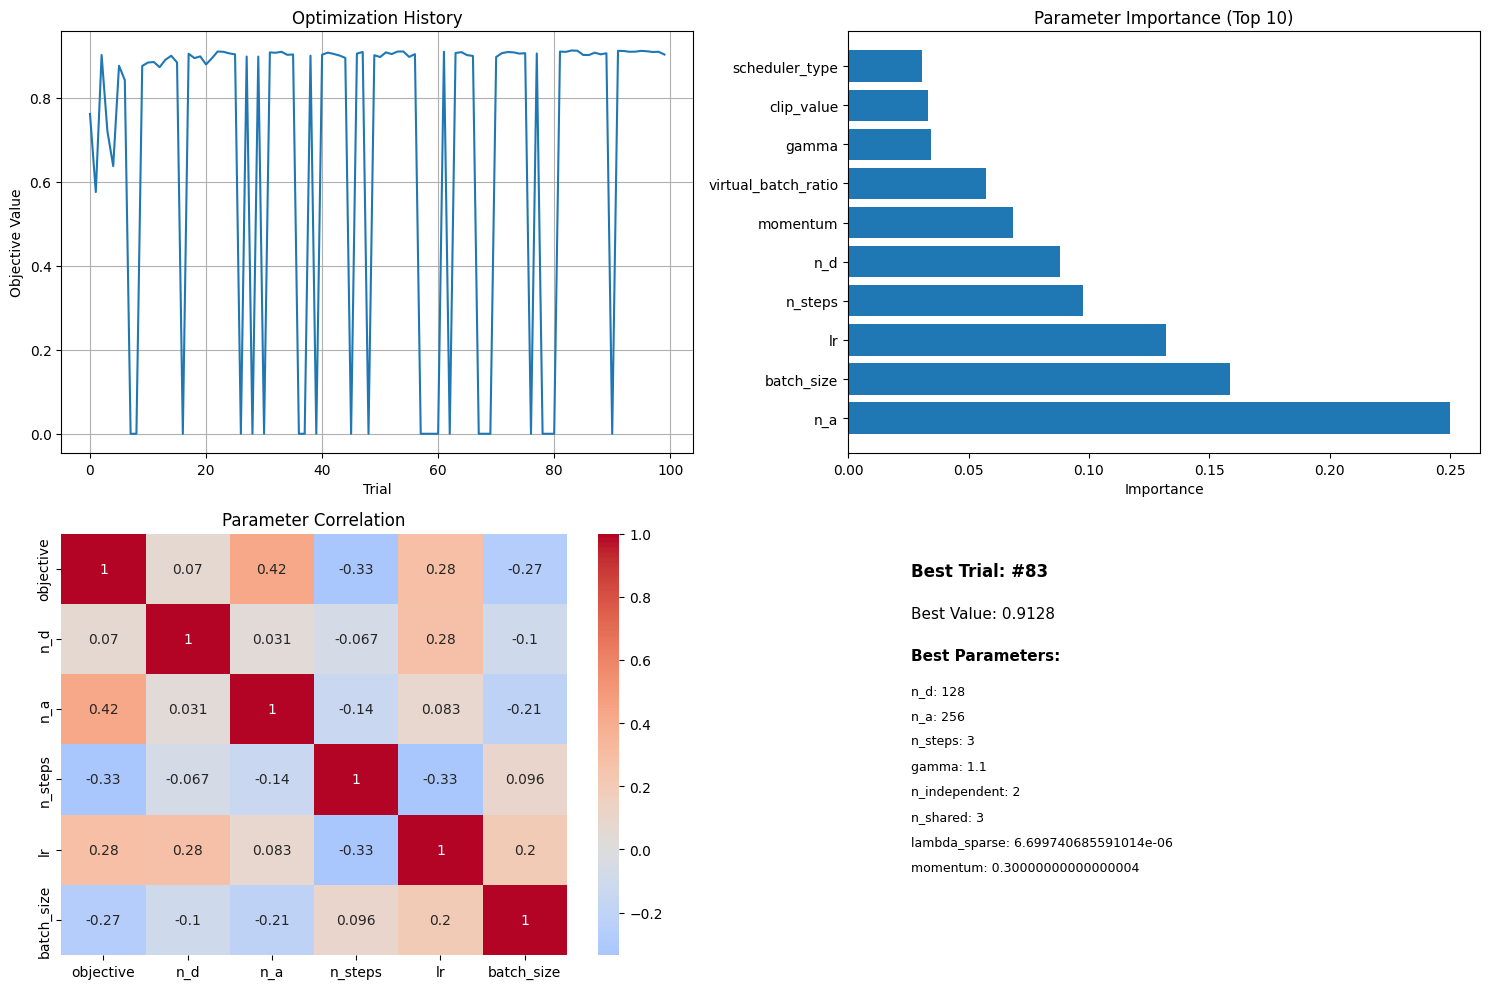

{'best_value': 0.912798658125, 'best_params': {'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.1, 'n_independent': 2, 'n_shared': 3, 'lambda_sparse': 6.699740685591014e-06, 'momentum': 0.30000000000000004, 'clip_value': 0.5, 'lr': 0.003349597334155287, 'scheduler_type': 'cosine', 'T_max': 80, 'mask_type': 'entmax', 'batch_size': 512, 'virtual_batch_ratio': 0.5}, 'n_trials': 100, 'completed_trials': 100, 'pruned_trials': 0, 'failed_trials': 0, 'study_name': 'tabnet_optimization_auc'}


In [33]:
# Visualize optimization results
optuna_clf.plot_optimization_history()

# Get optimization summary
summary = optuna_clf.get_optimization_summary()
print(summary)

In [34]:
# Train final model with best parameters
optuna_clf.train_with_best_params(
    max_epochs=200,
    patience=20
)



=== TRAINING WITH BEST PARAMETERS ===
Training with parameters:
  n_d: 128
  n_a: 256
  n_steps: 3
  gamma: 1.1
  n_independent: 2
  n_shared: 3
  lambda_sparse: 6.699740685591014e-06
  optimizer_fn: <class 'torch.optim.adamw.AdamW'>
  optimizer_params: {'lr': 0.003349597334155287}
  mask_type: entmax
  scheduler_params: {'T_max': 80}
  scheduler_fn: <class 'torch.optim.lr_scheduler.CosineAnnealingLR'>
  epsilon: 1e-15
  device_name: cuda
  momentum: 0.30000000000000004
  clip_value: 0.5
and with data shapes:
  - Features: (1000000, 52)
  - Labels: (1000000,)
GPU Memory:
  - Allocated: 0.04 GB
  - Reserved: 2.38 GB
  - Total: 34.19 GB
  - Free: 31.81 GB
Training configuration:
  - Device: cuda
  - Batch size: 512
  - Virtual batch size: 640
  - Max epochs: 200
  - Patience: 20

GPU memory before training:
GPU Memory:
  - Allocated: 0.04 GB
  - Reserved: 0.08 GB
  - Total: 34.19 GB
  - Free: 34.11 GB

Starting TabNet training...
epoch 0  | loss: 0.51729 | val_accuracy: 0.77585 | val_au

,n_d,128
,n_a,256
,n_steps,3
,gamma,1.1
,cat_idxs,[]
,cat_dims,[]
,cat_emb_dim,[]
,n_independent,2
,n_shared,3
,epsilon,1e-15
,momentum,0.30000000000000004


In [35]:
# Save model
optuna_clf.save_model(filepath=optuna_model_output_path )

Successfully saved model at tabnet_compressed_with_features_041025_0700_delivery\models\tabnet_compressed_with_features_041025_0700_delivery_model_optuna.zip
Model saved at: tabnet_compressed_with_features_041025_0700_delivery\models\tabnet_compressed_with_features_041025_0700_delivery_model_optuna
Scaler saved at: tabnet_compressed_with_features_041025_0700_delivery\models/tabnet_compressed_with_features_041025_0700_delivery_optuna_scaler.joblib


In [36]:
optuna_clf.load_model(filepath=optuna_model_output_path )

Model loaded from: tabnet_compressed_with_features_041025_0700_delivery\models\tabnet_compressed_with_features_041025_0700_delivery_model_optuna.zip



=== EVALUATION RESULTS ===
Accuracy: 0.8526
AUC Score: 0.9273

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85    100000
           1       0.85      0.86      0.85    100000

    accuracy                           0.85    200000
   macro avg       0.85      0.85      0.85    200000
weighted avg       0.85      0.85      0.85    200000



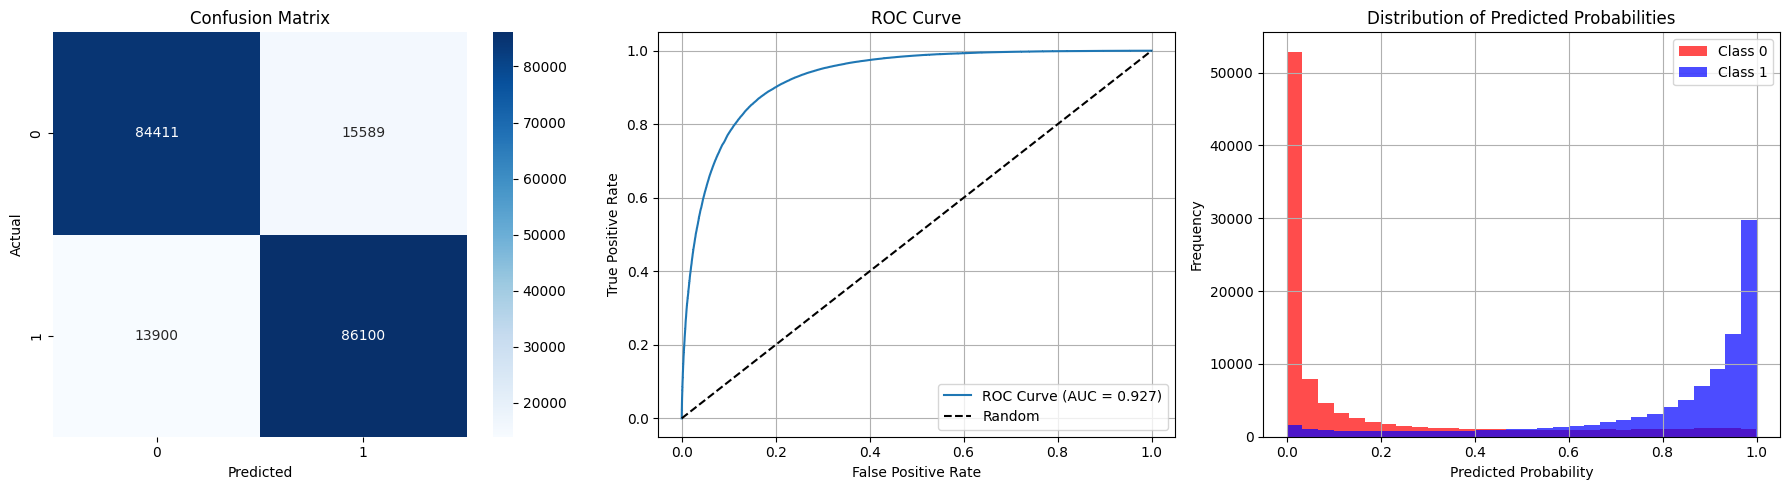


=== MODEL SUMMARY ===
Device: cuda

TabNet Parameters:
  - n_d: 128
  - n_a: 256
  - n_steps: 3
  - gamma: 1.1
  - n_independent: 2
  - n_shared: 3
  - lambda_sparse: 6.699740685591014e-06
  - optimizer_fn: <class 'torch.optim.adamw.AdamW'>
  - optimizer_params: {'lr': 0.003349597334155287}
  - mask_type: entmax
  - scheduler_params: {'T_max': 80}
  - scheduler_fn: <class 'torch.optim.lr_scheduler.CosineAnnealingLR'>
  - epsilon: 1e-15
  - momentum: 0.30000000000000004
  - clip_value: 0.5

Optimized Parameters:
  - n_d: 128
  - n_a: 256
  - n_steps: 3
  - gamma: 1.1
  - n_independent: 2
  - n_shared: 3
  - lambda_sparse: 6.699740685591014e-06
  - momentum: 0.30000000000000004
  - clip_value: 0.5
  - mask_type: entmax
  - batch_size: 512

Model Parameters:
  - Total: 3,060,488
  - Trainable: 3,060,488

GPU Memory:
  - Allocated: 0.12 GB
  - Reserved: 0.62 GB
  - Total: 34.19 GB
  - Free: 33.57 GB


In [37]:

# Evaluate on test set
results = optuna_clf.evaluate(plot_results=True)

# Get model summary
optuna_clf.get_model_summary()


# Optional: Save study results
study.trials_dataframe().to_csv(f'{os.environ["OUTPUT_DIR"]}/optimization_results.csv', index=False)


## Deep test

In [38]:
from sklearn.metrics import (
    matthews_corrcoef,
    log_loss, brier_score_loss
)
import warnings
class ModelTester:
    """
    Testing framework for TabNet models with comprehensive metrics 
    and visualization capabilities.
    """
    
    def __init__(self, model_path, test_data, test_labels):
        """
        Initialize the model tester.
        
        Parameters:
        -----------
        model_path : str
            Path to the saved TabNet model (.zip)
        test_data : pd.DataFrame
            Test dataset features
        test_labels : np.array
            Test dataset labels
        """
        self.model_path = model_path
        self.test_data = test_data
        self.test_labels = test_labels
        self.model = None
        self.results = {}
        
        # Professional color scheme
        self.colors = {
            'primary': '#2E86AB',
            'secondary': '#A23B72', 
            'accent': '#F18F01',
            'success': '#C73E1D',
            'neutral': '#6C757D',
            'light': '#F8F9FA'
        }
        
        self._setup_plotting_style()
        self._log_initialization()
    
    def _setup_plotting_style(self):
        """Configure professional plotting style."""
        plt.style.use('default')
        sns.set_palette([
            self.colors['primary'], 
            self.colors['secondary'], 
            self.colors['accent'], 
            self.colors['success']
        ])
    
    def _log_initialization(self):
        """Log initialization details."""
        print("ModelTester initialized")
        print(f"Test data shape: {self.test_data.shape}")
        print(f"Test labels: {len(self.test_labels)} samples")

    def load_model(self, tabnet_classifier_class):
        """
        Load the TabNet model from disk.
        
        Parameters:
        -----------
        tabnet_classifier_class : class
            TabNet classifier class for instantiation
        """
        try:
            # Create dummy instance for loading
            self.model = tabnet_classifier_class(
                 X_original=self.test_data.iloc[:10],
                 y_original =self.test_labels[:10],
                 scaler_path =None,
                 n_d =20, 
                 n_a =20, 
                 n_steps =5, 
                 gamma=1.5,
                 n_independent=2,
                 n_shared=2,
                 lambda_sparse=1e-3,
                 optimizer_fn=torch.optim.AdamW,
                 optimizer_params=dict(lr=1e-2),
                 mask_type='entmax',
                 momentum=0.02,
                 clip_value=1,
                 scheduler_params=dict(step_size=50, gamma=0.9),
                 scheduler_fn=torch.optim.lr_scheduler.StepLR,
                 epsilon=1e-15,
                 device_name='auto',
                 track_experiment=False, 
                 experiment_name=None)

            self.model.load_model(self.model_path)
            self.model.is_fitted = True
            print(f"Model loaded successfully from: {self.model_path}")
            
        except Exception as e:
            print(f"Error loading model: {e}")
            raise
    
    def create_stratified_splits(self, n_splits=10, random_state=42):
        """
        Create stratified test splits.
        
        Parameters:
        -----------
        n_splits : int
            Number of splits to create
        random_state : int
            Random seed for reproducibility
            
        Returns:
        --------
        list
            List of (X_split, y_split) tuples
        """
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, 
                             random_state=random_state)
        splits = []
        
        for _, test_idx in skf.split(self.test_data, self.test_labels):
            X_split = self.test_data.iloc[test_idx].copy()
            y_split = self.test_labels[test_idx].copy()
            splits.append((X_split, y_split))
        
        print(f"Created {n_splits} stratified splits")
        return splits
    
    def calculate_comprehensive_metrics(self, y_true, y_pred, y_pred_proba):
        """
        Calculate comprehensive classification metrics.
        
        Parameters:
        -----------
        y_true : array-like
            True labels
        y_pred : array-like
            Predicted labels
        y_pred_proba : array-like
            Predicted probabilities
            
        Returns:
        --------
        dict
            Dictionary containing all calculated metrics
        """
        metrics = {}
        
        # Basic metrics
        metrics['accuracy'] = accuracy_score(y_true, y_pred)
        metrics['precision'] = precision_score(y_true, y_pred, zero_division=0)
        metrics['recall'] = recall_score(y_true, y_pred, zero_division=0)
        metrics['f1'] = f1_score(y_true, y_pred, zero_division=0)
        
        # Advanced metrics with error handling
        try:
            metrics['auc_roc'] = roc_auc_score(y_true, y_pred_proba)
            metrics['auc_pr'] = average_precision_score(y_true, y_pred_proba)
            metrics['log_loss'] = log_loss(y_true, y_pred_proba)
            metrics['brier_score'] = brier_score_loss(y_true, y_pred_proba)
        except ValueError:
            metrics.update({
                'auc_roc': 0.5,
                'auc_pr': np.mean(y_true),
                'log_loss': np.inf,
                'brier_score': np.inf
            })
        
        # Matthews correlation coefficient
        metrics['mcc'] = matthews_corrcoef(y_true, y_pred)
        
        # Confusion matrix components
        cm = confusion_matrix(y_true, y_pred)
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            metrics.update({
                'true_positives': tp,
                'true_negatives': tn,
                'false_positives': fp,
                'false_negatives': fn,
                'sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0,
                'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0
            })
        else:
            metrics.update({
                'true_positives': 0,
                'true_negatives': 0,
                'false_positives': 0,
                'false_negatives': 0,
                'sensitivity': 0,
                'specificity': 0
            })
        
        return metrics
    
    def run_comprehensive_evaluation(self, n_splits=10, verbose=True):
        """
        Execute comprehensive model evaluation across multiple splits.
        
        Parameters:
        -----------
        n_splits : int
            Number of test splits
        verbose : bool
            Whether to show progress information
            
        Returns:
        --------
        dict
            Comprehensive evaluation results
        """
        if self.model is None:
            raise ValueError("Model must be loaded first using load_model()")
        
        print(f"\nStarting comprehensive evaluation with {n_splits} splits...")
        
        splits = self.create_stratified_splits(n_splits)
        
        all_metrics = []
        all_predictions = []
        all_probabilities = []
        all_true_labels = []
        
        for i, (X_split, y_split) in enumerate(splits):
            if verbose:
                print(f"Split {i+1}/{n_splits}: {X_split.shape[0]} samples", 
                      end=" -> ")
            
            try:
                y_pred = self.model.predict(X_split)
                y_pred_proba = self.model.predict_proba(X_split)[:, 1]
                
                metrics = self.calculate_comprehensive_metrics(
                    y_split, y_pred, y_pred_proba
                )
                metrics.update({
                    'split_id': i,
                    'n_samples': len(y_split)
                })
                
                all_metrics.append(metrics)
                all_predictions.extend(y_pred)
                all_probabilities.extend(y_pred_proba)
                all_true_labels.extend(y_split)
                
                if verbose:
                    print(f"Acc: {metrics['accuracy']:.3f}, "
                          f"AUC: {metrics['auc_roc']:.3f}")
                
            except Exception as e:
                print(f"Error in split {i+1}: {e}")
                continue
        
        # Aggregate results
        metrics_df = pd.DataFrame(all_metrics)
        aggregate_stats = self._calculate_aggregate_statistics(metrics_df)
        
        self.results = {
            'individual_results': metrics_df,
            'aggregate_stats': aggregate_stats,
            'all_predictions': np.array(all_predictions),
            'all_probabilities': np.array(all_probabilities),
            'all_true_labels': np.array(all_true_labels),
            'n_splits': n_splits
        }
        
        self._print_evaluation_summary()
        return self.results
    
    def _calculate_aggregate_statistics(self, metrics_df):
        """Calculate aggregate statistics from individual results."""
        aggregate_stats = {}
        metric_names = [col for col in metrics_df.columns 
                       if col not in ['split_id', 'n_samples']]
        
        for metric in metric_names:
            stats_prefix = f'{metric}_'
            aggregate_stats.update({
                f'{stats_prefix}mean': metrics_df[metric].mean(),
                f'{stats_prefix}std': metrics_df[metric].std(),
                f'{stats_prefix}min': metrics_df[metric].min(),
                f'{stats_prefix}max': metrics_df[metric].max()
            })
        
        return aggregate_stats
    
    def _print_evaluation_summary(self):
        """Print evaluation summary."""
        stats = self.results['aggregate_stats']
        print("\nEvaluation completed successfully!")
        print(f"Mean Accuracy: {stats['accuracy_mean']:.4f} "
              f"± {stats['accuracy_std']:.4f}")
        print(f"Mean AUC-ROC: {stats['auc_roc_mean']:.4f} "
              f"± {stats['auc_roc_std']:.4f}")
    
    def generate_detailed_report(self):
        """Generate and print detailed performance report."""
        if not self.results:
            print("Run comprehensive evaluation first")
            return
        
        stats = self.results['aggregate_stats']
        
        print("\n" + "="*60)
        print("COMPREHENSIVE MODEL EVALUATION REPORT")
        print("="*60)
        
        # Main metrics
        main_metrics = [
            ('Accuracy', 'accuracy'),
            ('Precision', 'precision'),
            ('Recall', 'recall'),
            ('F1-Score', 'f1'),
            ('AUC-ROC', 'auc_roc'),
            ('AUC-PR', 'auc_pr'),
            ('MCC', 'mcc')
        ]
        
        print("\nKEY PERFORMANCE METRICS:")
        for name, key in main_metrics:
            mean_val = stats[f'{key}_mean']
            std_val = stats[f'{key}_std']
            print(f"{name:<12}: {mean_val:.4f} ± {std_val:.4f}")
        
        # Confusion matrix statistics
        print(f"\nCONFUSION MATRIX STATISTICS (Mean across {self.results['n_splits']} splits):")
        confusion_metrics = [
            ('True Positives', 'true_positives'),
            ('True Negatives', 'true_negatives'),
            ('False Positives', 'false_positives'),
            ('False Negatives', 'false_negatives')
        ]
        
        for name, key in confusion_metrics:
            mean_val = stats[f'{key}_mean']
            std_val = stats[f'{key}_std']
            print(f"{name:<16}: {mean_val:.1f} ± {std_val:.1f}")
        
        # Loss metrics
        print("\nLOSS METRICS:")
        print(f"Log Loss      : {stats['log_loss_mean']:.4f} "
              f"± {stats['log_loss_std']:.4f}")
        print(f"Brier Score   : {stats['brier_score_mean']:.4f} "
              f"± {stats['brier_score_std']:.4f}")
    
    def create_comprehensive_visualizations(self, figsize=(20, 15), save_path=None):
        """
        Create comprehensive professional visualizations.
        
        Parameters:
        -----------
        figsize : tuple
            Figure size
        save_path : str, optional
            Path to save the visualization
        """
        if not self.results:
            print("Run comprehensive evaluation first")
            return
        
        fig = plt.figure(figsize=figsize)
        fig.suptitle('TabNet Model - Comprehensive Performance Analysis', 
                     fontsize=20, fontweight='bold', y=0.98)
        
        gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3, 
                             left=0.06, right=0.94, top=0.92, bottom=0.06)
        
        # Create all visualization components
        self._plot_metrics_distribution(fig.add_subplot(gs[0, :2]))
        self._plot_confusion_matrix(fig.add_subplot(gs[0, 2]))
        self._plot_roc_curve(fig.add_subplot(gs[1, 0]))
        self._plot_precision_recall_curve(fig.add_subplot(gs[1, 1]))
        self._plot_probability_distributions(fig.add_subplot(gs[1, 2]))
        self._plot_metrics_stability(fig.add_subplot(gs[2, 0]))
        self._plot_performance_correlation(fig.add_subplot(gs[2, 1]))
        self._plot_summary_table(fig.add_subplot(gs[2, 2]))
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight', 
                       facecolor='white', edgecolor='none')
            print(f"Visualizations saved to: {save_path}")
        
        plt.tight_layout()
        plt.show()
    
    def _plot_metrics_distribution(self, ax):
        """Plot distribution of key metrics across splits."""
        df = self.results['individual_results']
        metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc_roc']
        labels = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
        
        data = [df[metric].values for metric in metrics]
        bp = ax.boxplot(data, labels=labels, patch_artist=True)
        
        colors = [self.colors['primary'], self.colors['secondary'], 
                 self.colors['accent'], self.colors['success'], self.colors['neutral']]
        
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        ax.set_title('Metric Distribution Across Test Splits', 
                    fontsize=14, fontweight='bold')
        ax.set_ylabel('Score')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1.05)
    
    def _plot_confusion_matrix(self, ax):
        """Plot average confusion matrix."""
        stats = self.results['aggregate_stats']
        
        cm_data = np.array([
            [stats['true_negatives_mean'], stats['false_positives_mean']],
            [stats['false_negatives_mean'], stats['true_positives_mean']]
        ])
        
        sns.heatmap(cm_data, annot=True, fmt='.1f', cmap='Blues',
                   xticklabels=['Pred Neg', 'Pred Pos'],
                   yticklabels=['True Neg', 'True Pos'], ax=ax)
        ax.set_title('Average Confusion Matrix', fontsize=14, fontweight='bold')
    
    def _plot_roc_curve(self, ax):
        """Plot ROC curve."""
        y_true = self.results['all_true_labels']
        y_scores = self.results['all_probabilities']
        
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        auc_score = roc_auc_score(y_true, y_scores)
        
        ax.plot(fpr, tpr, color=self.colors['primary'], linewidth=3,
               label=f'ROC Curve (AUC = {auc_score:.3f})')
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
        
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title('ROC Curve', fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    def _plot_precision_recall_curve(self, ax):
        """Plot precision-recall curve."""
        y_true = self.results['all_true_labels']
        y_scores = self.results['all_probabilities']
        
        precision, recall, _ = precision_recall_curve(y_true, y_scores)
        ap_score = average_precision_score(y_true, y_scores)
        
        ax.plot(recall, precision, color=self.colors['secondary'], linewidth=3,
               label=f'PR Curve (AP = {ap_score:.3f})')
        
        baseline = np.sum(y_true) / len(y_true)
        ax.axhline(y=baseline, color='k', linestyle='--', alpha=0.5,
                  label=f'Baseline = {baseline:.3f}')
        
        ax.set_xlabel('Recall')
        ax.set_ylabel('Precision')
        ax.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    def _plot_probability_distributions(self, ax):
        """Plot predicted probability distributions by class."""
        y_true = self.results['all_true_labels']
        y_scores = self.results['all_probabilities']
        
        ax.hist(y_scores[y_true == 0], bins=30, alpha=0.7, 
               color=self.colors['accent'], label='Negative Class', density=True)
        ax.hist(y_scores[y_true == 1], bins=30, alpha=0.7,
               color=self.colors['primary'], label='Positive Class', density=True)
        
        ax.set_xlabel('Predicted Probability')
        ax.set_ylabel('Density')
        ax.set_title('Probability Distribution by True Class', 
                    fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    def _plot_metrics_stability(self, ax):
        """Plot metrics stability across splits."""
        df = self.results['individual_results']
        
        metrics = ['accuracy', 'auc_roc', 'f1']
        colors = [self.colors['primary'], self.colors['secondary'], self.colors['accent']]
        
        for metric, color in zip(metrics, colors):
            ax.plot(df['split_id'], df[metric], 'o-', color=color, 
                   label=metric.upper(), linewidth=2, markersize=6)
        
        ax.set_xlabel('Test Split')
        ax.set_ylabel('Score')
        ax.set_title('Metrics Stability Across Splits', 
                    fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1.05)
    
    def _plot_performance_correlation(self, ax):
        """Plot correlation between different performance metrics."""
        df = self.results['individual_results']
        
        scatter = ax.scatter(df['accuracy'], df['auc_roc'], 
                            c=df['f1'], cmap='viridis', 
                            s=100, alpha=0.7, edgecolors='black')
        
        ax.set_xlabel('Accuracy')
        ax.set_ylabel('AUC-ROC')
        ax.set_title('Performance Metrics Correlation\n(colored by F1-score)', 
                    fontsize=14, fontweight='bold')
        
        # Add trend line
        z = np.polyfit(df['accuracy'], df['auc_roc'], 1)
        p = np.poly1d(z)
        ax.plot(df['accuracy'], p(df['accuracy']), "r--", alpha=0.8)
        
        plt.colorbar(scatter, ax=ax, label='F1-Score')
        ax.grid(True, alpha=0.3)
    
    def _plot_summary_table(self, ax):
        """Plot summary statistics table."""
        stats = self.results['aggregate_stats']
        
        table_data = [
            ['Accuracy', f"{stats['accuracy_mean']:.3f} ± {stats['accuracy_std']:.3f}"],
            ['Precision', f"{stats['precision_mean']:.3f} ± {stats['precision_std']:.3f}"],
            ['Recall', f"{stats['recall_mean']:.3f} ± {stats['recall_std']:.3f}"],
            ['F1-Score', f"{stats['f1_mean']:.3f} ± {stats['f1_std']:.3f}"],
            ['AUC-ROC', f"{stats['auc_roc_mean']:.3f} ± {stats['auc_roc_std']:.3f}"],
            ['AUC-PR', f"{stats['auc_pr_mean']:.3f} ± {stats['auc_pr_std']:.3f}"],
            ['MCC', f"{stats['mcc_mean']:.3f} ± {stats['mcc_std']:.3f}"]
        ]
        
        table = ax.table(cellText=table_data,
                        colLabels=['Metric', 'Mean ± Std'],
                        cellLoc='center',
                        loc='center',
                        colWidths=[0.4, 0.6])
        
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 2)
        
        # Style the table
        for i in range(len(table_data) + 1):
            for j in range(2):
                if i == 0:  # Header
                    table[(i, j)].set_facecolor(self.colors['primary'])
                    table[(i, j)].set_text_props(weight='bold', color='white')
                else:
                    if i % 2 == 0:
                        table[(i, j)].set_facecolor(self.colors['light'])
        
        ax.set_title('Performance Summary', fontsize=14, fontweight='bold')
        ax.axis('off')



In [39]:
scaler_path = str(Path(optuna_clf.scaler_path))
scaler = joblib.load(scaler_path)
test_data = pd.DataFrame(test_data_with_features_df, columns=FEATURES)

test_data_scaled = scaler.transform(test_data)
if TEST_PIPELINE:
    test_data_scaled  = test_data_scaled[:1000]
    test_labels_clean_df = test_labels_clean_df[:1000]

In [40]:
MODEL_PATH = optuna_clf.model_path

tester = ModelTester(model_path=MODEL_PATH,
                        test_data=pd.DataFrame(test_data_scaled, columns=FEATURES), 
                        test_labels=test_labels_clean_df['label'])


ModelTester initialized
Test data shape: (2000000, 52)
Test labels: 2000000 samples


In [41]:
tester.load_model(TabNetBinaryClassifier)

GPU available: NVIDIA GeForce RTX 5090
GPU memory available: 34.2 GB
Device used: cuda
Additional data file not found, using defaults
Model loaded from: tabnet_compressed_with_features_041025_0700_delivery\models\tabnet_compressed_with_features_041025_0700_delivery_model_optuna
Optimal threshold: 0.500
Model loaded successfully from: tabnet_compressed_with_features_041025_0700_delivery\models\tabnet_compressed_with_features_041025_0700_delivery_model_optuna


In [42]:
results = tester.run_comprehensive_evaluation(n_splits=10 if not TEST_PIPELINE else 2, verbose=True)


Starting comprehensive evaluation with 10 splits...
Created 10 stratified splits
Split 1/10: 200000 samples -> Acc: 0.852, AUC: 0.927
Split 2/10: 200000 samples -> Acc: 0.854, AUC: 0.927
Split 3/10: 200000 samples -> Acc: 0.854, AUC: 0.928
Split 4/10: 200000 samples -> Acc: 0.854, AUC: 0.928
Split 5/10: 200000 samples -> Acc: 0.854, AUC: 0.927
Split 6/10: 200000 samples -> Acc: 0.852, AUC: 0.927
Split 7/10: 200000 samples -> Acc: 0.853, AUC: 0.927
Split 8/10: 200000 samples -> Acc: 0.853, AUC: 0.928
Split 9/10: 200000 samples -> Acc: 0.853, AUC: 0.927
Split 10/10: 200000 samples -> Acc: 0.854, AUC: 0.928

Evaluation completed successfully!
Mean Accuracy: 0.8533 ± 0.0008
Mean AUC-ROC: 0.9273 ± 0.0005


In [43]:
tester.generate_detailed_report()


COMPREHENSIVE MODEL EVALUATION REPORT

KEY PERFORMANCE METRICS:
Accuracy    : 0.8533 ± 0.0008
Precision   : 0.8467 ± 0.0010
Recall      : 0.8629 ± 0.0008
F1-Score    : 0.8547 ± 0.0007
AUC-ROC     : 0.9273 ± 0.0005
AUC-PR      : 0.9183 ± 0.0008
MCC         : 0.7068 ± 0.0015

CONFUSION MATRIX STATISTICS (Mean across 10 splits):
True Positives  : 86289.2 ± 76.4
True Negatives  : 84377.0 ± 113.7
False Positives : 15623.0 ± 113.7
False Negatives : 13710.8 ± 76.4

LOSS METRICS:
Log Loss      : 0.3567 ± 0.0013
Brier Score   : 0.1076 ± 0.0005


Visualizations saved to: tabnet_compressed_with_features_041025_0700_delivery/overall_model_performance.png


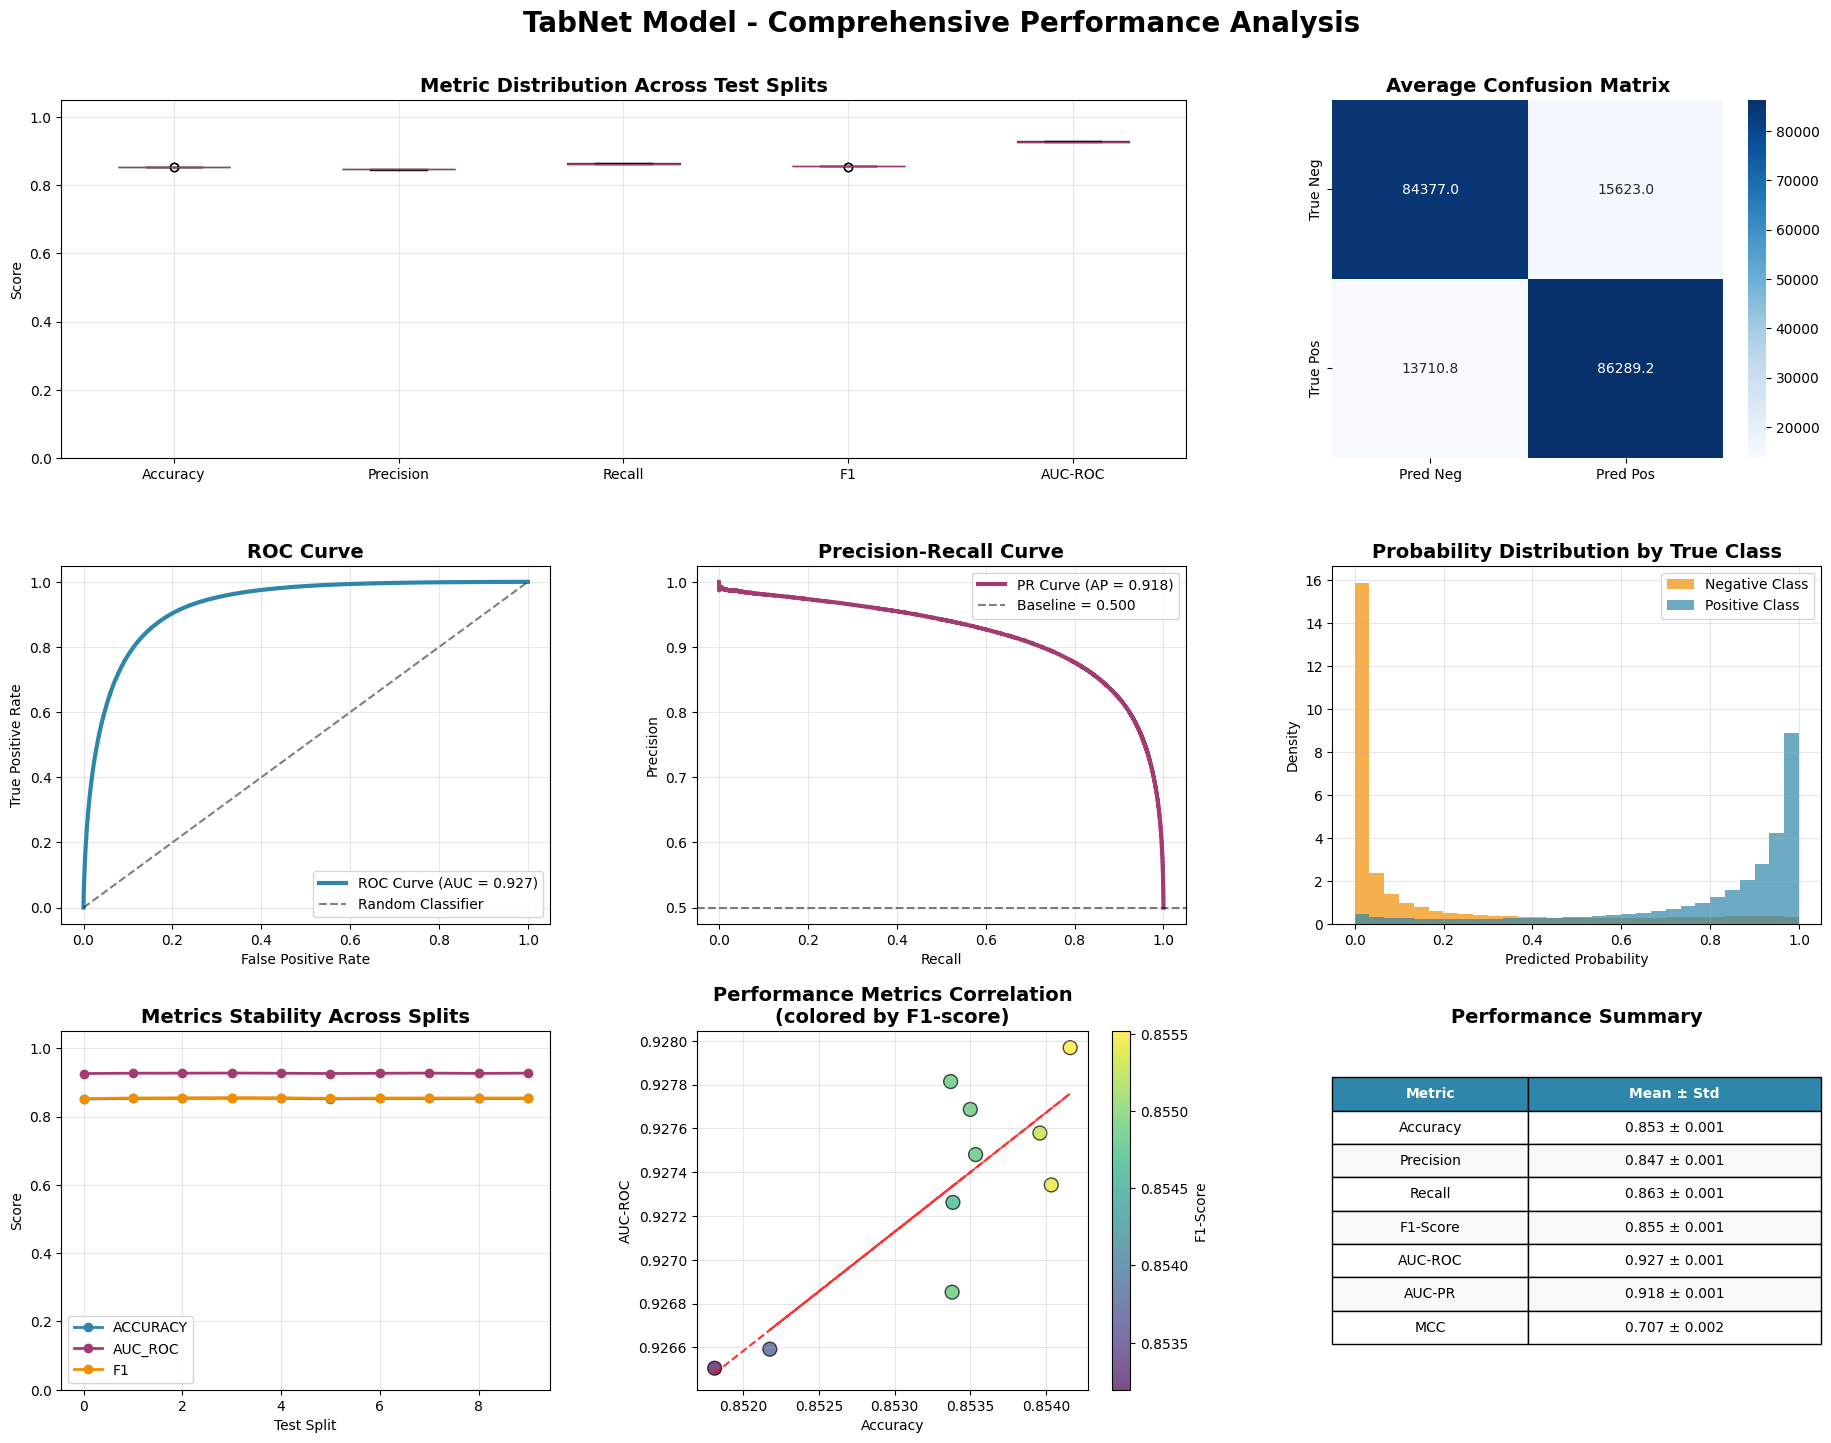

In [44]:
tester.create_comprehensive_visualizations(save_path=f'{os.environ["OUTPUT_DIR"]}/overall_model_performance.png')

In [ ]:
for name in dir():
    if not name.startswith('_'):
        del globals()[name]